# Análisis Electoral – Chile 2025 · Primera Vuelta Presidencial

La primera vuelta presidencial de 2025 tuvo lugar en uno de los contextos políticos más complejos de la historia reciente de Chile. Desde el estallido social de octubre de 2019 y la pandemia de COVID-19, el país atravesó un proceso constituyente fracasado en 2022 y un segundo intento rechazado en 2023, mientras la inflación acumulada, la crisis migratoria y un deterioro sostenido en la percepción de seguridad pública erosionaban la confianza ciudadana en las instituciones. Con el retorno del voto obligatorio —en vigor desde las elecciones municipales de 2024—, el electorado acudió a las urnas en noviembre de 2025 con una participación inédita desde la transición democrática.

La elección de 2025 no puede entenderse sin la trayectoria del gobierno de Gabriel Boric. Tras ganar la segunda vuelta de 2021 con el 55,87% de los votos —la mayor votación presidencial en voto voluntario—, su administración acumuló un desgaste acelerado: la aprobación presidencial cayó a cifras históricamente bajas, el proceso constituyente del que fue emblema terminó en un rechazo aplastante, y las demandas ciudadanas más urgentes —seguridad, inflación, migración, crecimiento económico— no encontraron respuesta efectiva. Ese desgaste se trasladó directamente a la primera vuelta: el bloque oficialista, con Jeannette Jara como candidata, obtuvo el 26,75%, la peor votación de la izquierda en primera vuelta desde el retorno a la democracia en competencia abierta.

En ese contexto, se consolidaron tres dinámicas que definen el mapa electoral 2025:

- **El auge de la derecha conservadora.** José Antonio Kast, ya consolidado como referente del Partido Republicano tras su fuerte primera vuelta de 2021, logró una base territorial extensa —169 comunas— y concitó el respaldo del Chile rural, semi-rural y periférico que percibe el centralismo santiaguino como una amenaza a su modo de vida y sus demandas de orden y seguridad.

- **El colapso de la derecha tradicional.** Evelyn Matthei, representante de Chile Vamos y del piñerismo histórico, obtuvo apenas el 12,44% —la peor performance de esa coalición en décadas—, atrapada entre el Partido Republicano y el rechazo asociado a la gestión del Estallido Social de 2019.

- **La consolidación del antisistema como tercera fuerza.** Franco Parisi, con el 19,80%, triplicó en votos absolutos su resultado de 2021. El Partido de la Gente capitalizó el descontento de comunas nortinas afectadas por la crisis migratoria, la delincuencia organizada y el abandono estatal, construyendo un monopolio territorial en cuatro regiones del Norte Grande. Junto a él, Johannes Kaiser, con el 13,94%, inauguró en Chile un nicho libertario que hasta entonces carecía de expresión electoral propia.

El presente análisis, construido íntegramente sobre datos oficiales de SERVEL y complementado con comparaciones históricas respecto a la primera vuelta de 2021, busca desagregar los resultados nacionales para entender qué fuerzas mueven el voto chileno: quién vota dónde, por qué razones estructurales, qué territorios cambiaron de color y qué dinámicas de transferencia definen la carrera hacia la segunda vuelta. El resultado es un diagnóstico territorial, demográfico y político del Chile electoral en un momento de alto realineamiento.

## 1. Setup

### 1.1. Dependencies

In [54]:
!pip install pandas numpy matplotlib geopandas

### 1.2. Imports

In [2]:
import os
import re
from pathlib import Path
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import matplotlib.patheffects as pe

## 2. Data Loading

### 2.1. Electoral and Demographic Data

In [3]:
# Remote source URLs – GitHub raw files
url_votes = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2025_first_round.csv"
url_votes_2021 = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2021_first_round.csv"
url_pop   = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/communes_population_2024.csv"
url_dim   = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/region_dimension.csv"


print("URLs configured")

URLs configured


### 2.2. Load Data

#### 2.2.1. Electoral Data (2025)

In [4]:
df_votes = pd.read_csv(url_votes, encoding='utf-8-sig')

print(f"Electoral data loaded: {len(df_votes):,} communes, {df_votes.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_votes.head(3)

Electoral data loaded: 346 communes, 24 columns

First 3 rows:


,commune,region,artes_votes,artes_pct,enriquez_ominami_votes,enriquez_ominami_pct,jara_votes,jara_pct,kaiser_votes,kaiser_pct,...,mayne_nicholls_votes,mayne_nicholls_pct,parisi_votes,parisi_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Antofagasta,Antofagasta,1375,0.56,2738,1.12,60507,24.71,31798,12.99,...,4065,1.66,79669,32.54,3014,1.18,255984,100.0,8137,3.18
1,Calama,Antofagasta,488,0.47,1201,1.15,19496,18.69,14990,14.37,...,1005,0.96,40651,38.98,963,0.89,108350,100.0,3096,2.86
2,Maria Elena,Antofagasta,14,0.45,40,1.28,694,22.27,288,9.24,...,33,1.06,1429,45.86,41,1.26,3261,100.0,104,3.19


#### 2.2.2. Electoral Data (2021)

In [5]:
df_2021 = pd.read_csv(url_votes_2021, encoding='utf-8-sig')

print(f"2021 electoral data loaded: {len(df_2021):,} communes, {df_2021.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_2021.head(3)

2021 electoral data loaded: 346 communes, 22 columns

First 3 rows:


,commune,region,artes_votes,artes_pct,boric_votes,boric_pct,enriquez_ominami_votes,enriquez_ominami_pct,kast_votes,kast_pct,...,provoste_votes,provoste_pct,sichel_votes,sichel_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Alhue,Metropolitana de Santiago,31,1.25,636,25.68,151,6.10,467,18.85,...,520,20.99,320,12.92,16,0.65,2512,41.06,19,0.77
1,Buin,Metropolitana de Santiago,513,1.30,10500,26.59,3189,8.08,11635,29.46,...,3809,9.64,4609,11.67,132,0.33,39906,51.15,282,0.71
2,Calera de Tango,Metropolitana de Santiago,115,1.09,2586,24.62,693,6.60,3596,34.23,...,1067,10.16,1693,16.12,40,0.38,10603,47.07,59,0.56


#### 2.2.2. Population Data

In [6]:
df_pop = pd.read_csv(url_pop, encoding='utf-8-sig')

# Cast population columns to nullable integer to remove trailing .0
for col in ['population', 'male_population', 'female_population']:
    if col in df_pop.columns:
        df_pop[col] = df_pop[col].astype('Int64')

print(f"Population data loaded: {len(df_pop):,} communes, {df_pop.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_pop.head(3)

Population data loaded: 345 communes, 6 columns

First 3 rows:


,commune,region,population,male_population,female_population,sex_ratio
0,camarones,Arica y Parinacota,861,430,431,99.8
1,putre,Arica y Parinacota,1547,846,701,120.7
2,general lagos,Arica y Parinacota,508,261,247,105.7


#### 2.2.3. Region Dimension Table

In [7]:
df_region_dim = pd.read_csv(url_dim, encoding='utf-8-sig')

print(f"Region dimension table loaded: {len(df_region_dim)} rows, {df_region_dim.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_region_dim.head(3)

Region dimension table loaded: 16 rows, 5 columns

First 3 rows:


,region_code,region,macrozone,macrozone_order,region_order
0,15,Arica y Parinacota,Norte Grande,1,1
1,1,Tarapacá,Norte Grande,1,2
2,2,Antofagasta,Norte Grande,1,3


### 2.3. Geographic Data (Commune GeoJSON)

In [8]:
# ============================================================================
# GEOGRAPHIC DATA LOADER
# ============================================================================

def load_geographic_data() -> gpd.GeoDataFrame:
    """
    Loads Chilean commune geometries from multiple sources in priority order:
    1. Local files (GeoJSON or SHP).
    2. Per-region download from the public caracena/chile-geojson repository.

    Raises RuntimeError if no source is reachable.

    Returns
    -------
    gpd.GeoDataFrame
        CRS EPSG:4326, with at least columns NOM_COM, COD_COM, REGION_NUM.
    """
    print("Loading geographic data...")

    # Local file search order
    local_files = [
        'comunas_chile.geojson', 'comunas.geojson',
        'chile_comunas.geojson', 'chile.geojson',
        'comunas_chile.shp', 'comunas.json',
    ]
    for path in local_files:
        if os.path.exists(path):
            try:
                gdf = gpd.read_file(path)
                if len(gdf) > 0:
                    print(f"Local file loaded: {path} ({len(gdf)} communes)")
                    return gdf
            except Exception as exc:
                print(f"Could not read {path}: {exc}")

    # Fallback: download per region from GitHub
    print("No local files found. Downloading from caracena/chile-geojson...")
    gdfs = []
    for i in range(1, 17):
        url = f"https://raw.githubusercontent.com/caracena/chile-geojson/master/{i}.geojson"
        try:
            gdf_region = gpd.read_file(url)
            # Normalise column names to internal schema
            if 'Comuna' in gdf_region.columns:
                gdf_region['NOM_COM'] = gdf_region['Comuna']
            if 'cod_comuna' in gdf_region.columns:
                gdf_region['COD_COM'] = gdf_region['cod_comuna']
            gdf_region['REGION_NUM'] = (
                gdf_region['codregion'] if 'codregion' in gdf_region.columns else i
            )
            gdfs.append(gdf_region)
            print(f"Region {i}: {len(gdf_region)} communes downloaded")
        except Exception as exc:
            print(f"Error downloading region {i}: {exc}")

    if gdfs:
        gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs='EPSG:4326')
        gdf.to_file('comunas_chile.geojson', driver='GeoJSON')
        print(f"Total downloaded: {len(gdf)} communes. Saved as 'comunas_chile.geojson'.")
        return gdf

    raise RuntimeError("Could not load geographic data from any source.")


communes = load_geographic_data()

# Derive REGION_NUM from COD_COM when absent in the GeoDataFrame
if 'REGION_NUM' not in communes.columns:
    if 'COD_COM' in communes.columns:
        communes['REGION_NUM'] = communes['COD_COM'].astype(str).str[:2].astype(int)
    else:
        raise ValueError("Neither 'REGION_NUM' nor 'COD_COM' found in GeoDataFrame.")

print(f"GeoDataFrame ready: {len(communes)} records")
print(f"Columns: {list(communes.columns)}")

Loading geographic data...
Local file loaded: comunas_chile.geojson (345 communes)
GeoDataFrame ready: 345 records
Columns: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'NOM_COM', 'COD_COM', 'REGION_NUM', 'geometry']


### 2.4. Commune normalizer

In [9]:
import unicodedata

def normalize_commune_name(name: str) -> str:
    """
    Canonicalizes a commune name for cross-dataset matching.

    Processing pipeline:
    1. Lowercase and strip surrounding whitespace.
    2. Decompose Unicode characters via NFD and strip all combining marks,
       removing diacritics and diaereses regardless of source encoding.
    3. Remove every non-alphanumeric character except spaces (hyphens,
       parentheses, punctuation).
    4. Collapse internal whitespace runs to a single space.
    5. Apply a curated correction table for residual spelling mismatches
       (legacy transliterations, known editorial inconsistencies).

    Diacritics are stripped before the correction lookup so every key in
    the table uses the plain ASCII form; no accented variants are needed.

    Parameters
    ----------
    name : str
        Raw commune name from any source dataset.

    Returns
    -------
    str
        Normalized canonical form ready for equality comparison.
    """
    if pd.isna(name):
        return ''

    name = str(name).strip().lower()

    # Strip diacritics and diaereses (NFD decompose → drop combining marks)
    name = unicodedata.normalize('NFD', name)
    name = ''.join(c for c in name if unicodedata.category(c) != 'Mn')

    # Remove everything except alphanumerics and spaces
    name = re.sub(r'[^a-z0-9\s]', '', name)

    # Collapse whitespace
    name = ' '.join(name.split())

    # Curated corrections: keys use the already-stripped ASCII form
    CORRECTIONS = {
        'llayllay':                 'llaillay',    # Llay-Llay → Llaillay
        'trehuaco':                 'treguaco',    # legacy spelling
        'marchigue':               'marchihue',   # Marchigüe → Marchihue (official)
        'cabo de hornosexnavarino': 'cabo de hornos',  # parenthetical suffix
    }
    return CORRECTIONS.get(name, name)


## 3. Estadísticas Generales de Participación

La primera vuelta presidencial de 2025 se celebró bajo el régimen de voto obligatorio, reinstaurado mediante reforma legal promulgada en 2022 y en vigor desde las elecciones municipales de octubre de 2024. El efecto sobre la participación fue inmediato y masivo: de poco más de 7 millones de sufragios emitidos en 2021, se pasó a **13,39 millones en 2025**, un incremento del 89,1% que no tiene precedente en la historia reciente del país.

Esta sección analiza los indicadores clave de participación, la calidad del voto emitido y las expresiones de descontento a través del voto blanco y nulo, ofreciendo el contexto necesario para interpretar los resultados de los candidatos con rigor comparativo.

In [10]:
# ============================================================================
# PARTICIPATION ANALYSIS
# ============================================================================

def analyze_participation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates aggregate electoral participation indicators at national level.

    Returns a DataFrame with 'indicator' and 'value' columns including
    absolute totals and percentages of casted, blank, null and valid votes.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns 'casted_votes', 'blank_votes' and 'null_votes'.

    Returns
    -------
    pd.DataFrame
    """
    total_cast  = df['casted_votes'].sum()
    total_blank = df['blank_votes'].sum()
    total_null  = df['null_votes'].sum()
    total_valid = total_cast - (total_blank + total_null)

    pct_blank = (total_blank / total_cast) * 100
    pct_null  = (total_null  / total_cast) * 100
    pct_valid = (total_valid / total_cast) * 100

    return pd.DataFrame({
        'indicator': [
            'Total communes',
            'Total casted votes',
            'Total blank votes',
            'Blank votes (%)',
            'Total null votes',
            'Null votes (%)',
            'Total valid votes',
            'Valid votes (%)',
        ],
        'value': [
            len(df),
            total_cast,
            total_blank,
            round(pct_blank, 2),
            total_null,
            round(pct_null,  2),
            total_valid,
            round(pct_valid, 2),
        ],
    })


participation_summary = analyze_participation(df_votes)
participation_summary

,indicator,value
0,Total communes,346.00
1,Total casted votes,13388455.00
2,Total blank votes,141956.00
3,Blank votes (%),1.06
4,Total null votes,360571.00
5,Null votes (%),2.69
6,Total valid votes,12885928.00
7,Valid votes (%),96.25


#### Hallazgos principales

- **Eficiencia técnica robusta:** El 96,25% de los votos emitidos fueron válidos, porcentaje superior al 94,5% registrado en 2021, lo que refleja madurez en el sistema electoral y un electorado mayoritariamente capaz de expresar su preferencia con claridad, incluso bajo obligatoriedad.
- **Participación histórica:** Con una estimación de participación en torno al 85,4% del padrón habilitado, 2025 marca la tasa de concurrencia más alta desde la elección presidencial de 1993, cuando el voto también era obligatorio.
- **Base electoral ampliada:** Los más de 12,8 millones de votos válidos otorgan al proceso una legitimidad robusta, independientemente de la fragmentación del resultado.

**Lectura estratégica:** La alta tasa de votos válidos refuerza la legitimidad del proceso, pero los 502 mil votos inválidos —equivalentes a la población combinada de regiones como Aysén o Los Ríos— representan un segmento ciudadano no menor que se negó a pronunciarse por ningún candidato.

#### Voto de Protesta: Análisis Diferenciado

El cambio más relevante respecto a 2021 no es el nivel absoluto de votos inválidos, sino su composición y la ratio entre sus tipos.

**Voto en blanco (1,06%)**
Representa una **protesta pasiva o de principios**: el ciudadano cumple con la obligación legal pero declara que ninguna de las opciones le representa. Con una presencia de 1 de cada 94 votantes, su nivel es moderado y coherente con la alta fragmentación de la oferta (ocho candidaturas competitivas).

**Voto nulo (2,69%)**
Equivale a una **protesta activa y deliberada**: el ciudadano anula su voto como acto político explícito de rechazo al sistema. Es 2,53 veces más frecuente que el voto blanco —la proporción nulo:blanco pasó de 1,8:1 en 2021 a 2,5:1 en 2025—, lo que indica que el descontento ciudadano es **más confrontacional y menos abstencionista** que hace cuatro años.

Esta evolución es consistente con el clima político del período: ciudadanos que en 2021 simplemente no votaban, en 2025 se ven obligados a participar y un subconjunto de ellos elige el rechazo explícito antes que la indiferencia.

#### Comparación Histórica

| Elección                | % Válidos  | % Nulos   | % Blancos | Participación estimada |
| ----------------------- | ---------- | --------- | --------- | ---------------------- |
| Presidencial 2025 (1ªV) | **96,25%** | **2,69%** | 1,06%     | ~85,4%                 |
| Presidencial 2021 (1ªV) | 94,5%      | ~4,0%     | ~1,5%     | 47,3%                  |
| Plebiscito 2022         | –          | ~5,5%     | ~6,2%     | 85,9%                  |

*Nota: Los datos del Plebiscito 2022 muestran una dinámica distinta, puesto que las opciones "Apruebo" y "Rechazo" tenían una carga política directa; la alta tasa de voto en blanco y nulo refleja en parte el fenómeno del voto de rechazo por procedimiento.*

#### Conclusión

El sistema electoral chileno demostró en noviembre de 2025 una **alta eficiencia técnica y legitimidad democrática**, con más del 96% de sufragios válidos. Sin embargo, el peso del voto de protesta —especialmente el voto nulo, que prácticamente duplica el nivel de 2021 en términos relativos— es una señal que trasciende lo técnico: una fracción del electorado incorporado por la obligatoriedad expresa su desafección de forma activa. Ese segmento, en elecciones de segunda vuelta o en comicios futuros con alta competitividad, puede tener un impacto no trivial sobre los márgenes finales.

## 4. Resultados Nacionales por Candidato

La primera vuelta presidencial de 2025 configuró un mapa de **fragmentación avanzada y liderazgos relativamente débiles**: ningún candidato alcanzó el 27% de los votos válidos. Este resultado no es solo consecuencia de la multiplicación de candidaturas, sino del realineamiento profundo que experimenta el electorado chileno desde 2019. La elección reveló que ningún bloque político posee hoy una mayoría consolidada capaz de ganar en primera vuelta, y que el centro político —históricamente articulador de consensos— ha perdido gravitación estructural.

Esta sección analiza los resultados por candidato, los organiza por grupos de competitividad y realiza un balance estratégico por bloques ideológicos, identificando las dinámicas de transferencia de votos que definen el camino hacia la segunda vuelta.

In [11]:
# ============================================================================
# CANDIDATE METADATA AND COLOR PALETTE
# ============================================================================

# Display name → column key and political affiliation
CANDIDATES_META = {
    'Jeannette Jara':         {'col': 'jara_votes',             'party': 'Left-wing officialist (Boric - Unidad por Chile)'},
    'José Antonio Kast':      {'col': 'kast_votes',             'party': 'Conservative right (Partido Republicano)'},
    'Franco Parisi':          {'col': 'parisi_votes',           'party': 'Third way (Partido de la Gente)'},
    'Johannes Kaiser':        {'col': 'kaiser_votes',           'party': 'Libertarian right (Partido Nacional Libertario)'},
    'Evelyn Matthei':         {'col': 'matthei_votes',          'party': 'Historical right - Piñerismo (Chile Vamos)'},
    'Harold Mayne-Nicholls':  {'col': 'mayne_nicholls_votes',   'party': 'Independent'},
    'Marco Enriquez-Ominami': {'col': 'enriquez_ominami_votes', 'party': 'Independent left'},
    'Eduardo Artes':          {'col': 'artes_votes',            'party': 'Far left'},
}

# Campaign corporate color palette by candidate
CANDIDATE_COLORS = {
    'Jeannette Jara':         '#E54944',
    'José Antonio Kast':      '#35466D',
    'Franco Parisi':          '#4B70B5',
    'Johannes Kaiser':        '#F3832C',
    'Evelyn Matthei':         '#226FD4',
    'Harold Mayne-Nicholls':  '#BED8DF',
    'Marco Enriquez-Ominami': '#DD2883',
    'Eduardo Artes':          '#CA1C1F',
    'No data':                '#D3D3D3',
}

In [12]:
# ============================================================================
# NATIONAL CANDIDATE AGGREGATION
# ============================================================================

def analyze_candidates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates votes at national level by candidate and calculates percentage
    over valid votes. Determines runoff eligibility per Article 26 of the
    Political Constitution (absolute majority required in first round).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with candidate vote columns, casted_votes, null_votes
        and blank_votes.

    Returns
    -------
    pd.DataFrame
        Columns: candidate, party, votes, vote_percentage,
        goes_to_runoff, competitiveness_context.
    """
    total_valid = (
        df['casted_votes'].sum()
        - df['null_votes'].sum()
        - df['blank_votes'].sum()
    )

    rows = []
    for name, meta in CANDIDATES_META.items():
        votes = df[meta['col']].sum()
        rows.append({
            'candidate':       name,
            'party':           meta['party'],
            'votes':           votes,
            'vote_percentage': round((votes / total_valid) * 100, 2),
        })

    result = (
        pd.DataFrame(rows)
        .sort_values('vote_percentage', ascending=False)
        .reset_index(drop=True)
    )

    # Competitiveness classification by percentage threshold
    def _context(pct: float) -> str:
        if pct > 20:  return 'High support'
        if pct >= 10: return 'Competitive threshold'
        return 'Minimum threshold'

    result['competitiveness_context'] = result['vote_percentage'].apply(_context)

    # Runoff applies when no candidate exceeds 50% of valid votes
    first_pct = result.loc[0, 'vote_percentage']
    result['goes_to_runoff'] = False if first_pct > 50 else result.index < 2

    return result[['candidate', 'party', 'votes', 'vote_percentage',
                   'goes_to_runoff', 'competitiveness_context']]


candidate_results = analyze_candidates(df_votes)
candidate_results

,candidate,party,votes,vote_percentage,goes_to_runoff,competitiveness_context
0,Jeannette Jara,Left-wing officialist (Boric - Unidad por Chile),3446854,26.75,True,High support
1,José Antonio Kast,Conservative right (Partido Republicano),3086963,23.96,True,High support
2,Franco Parisi,Third way (Partido de la Gente),2550770,19.80,False,Competitive threshold
3,Johannes Kaiser,Libertarian right (Partido Nacional Libertario),1796034,13.94,False,Competitive threshold
4,Evelyn Matthei,Historical right - Piñerismo (Chile Vamos),1603104,12.44,False,Competitive threshold
5,Harold Mayne-Nicholls,Independent,162366,1.26,False,Minimum threshold
6,Marco Enriquez-Ominami,Independent left,154321,1.20,False,Minimum threshold
7,Eduardo Artes,Far left,85516,0.66,False,Minimum threshold


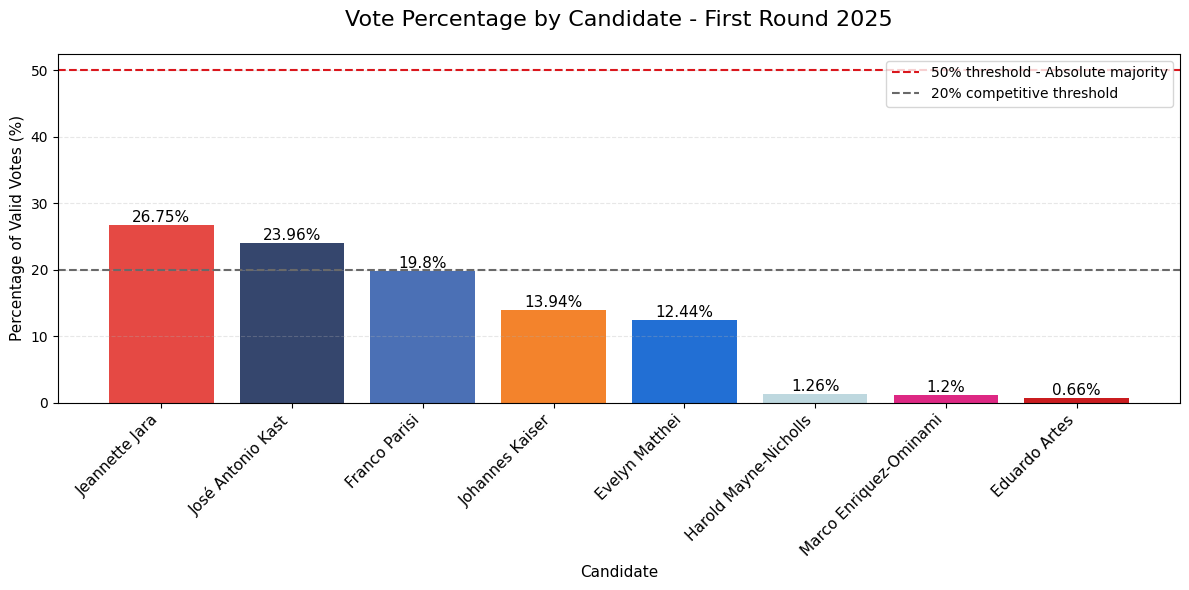

In [13]:
# Build ordered lists from the already-computed DataFrame
candidates_ordered  = candidate_results['candidate'].tolist()
percentages_ordered = candidate_results['vote_percentage'].tolist()
bar_colors          = [CANDIDATE_COLORS[c] for c in candidates_ordered]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(candidates_ordered, percentages_ordered,
              color=bar_colors, linewidth=1)

# Percentage label above each bar
for bar, pct in zip(bars, percentages_ordered):
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height(),
        f'{pct}%',
        ha='center', va='bottom', fontsize=11,
    )

# Electoral reference lines
ax.axhline(y=50, color='#DA171D', linestyle='--', linewidth=1.5,
           label='50% threshold - Absolute majority')
ax.axhline(y=20, color='#696969', linestyle='--', linewidth=1.5,
           label='20% competitive threshold')

ax.set_title('Vote Percentage by Candidate - First Round 2025', fontsize=16, pad=20)
ax.set_ylabel('Percentage of Valid Votes (%)', fontsize=11)
ax.set_xlabel('Candidate', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=11)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

#### Análisis por Grupos de Competitividad

**Grupo 1: Liderazgo Competitivo (Primer Tercio)**

- **Jeannette Jara (26,75%)** — Primera vuelta ganada con la base más estrecha de la izquierda en décadas. Sus 3,45 millones de votos representan la unificación prácticamente total del espacio progresista y oficialista, pero esa suma agotada alcanza apenas para liderar la primera vuelta. Su resultado refleja el techo real del apoyo al gobierno de Boric: sólido en términos de cohesión interna, pero insuficiente para construir una mayoría propia. El desafío estratégico es que llegó a segunda vuelta sin reservas de voto propio relevantes.

- **José Antonio Kast (23,96%)** — A 2,79 puntos porcentuales de Jara (aproximadamente 360 mil votos), Kast consolidó el electorado conservador y logró la mejor primera vuelta de la derecha dura en la era democrática, superando incluso su propio resultado de 2021 en votos absolutos (+58%). Demostró una base territorial amplia y fiel, pero su margen de primera vuelta subestima su posición real de cara al balotaje, ya que el bloque afín —incluyendo Kaiser y parte de Matthei— supera con holgura el 50%.

**Diferencia Jara–Kast: 2,79 puntos.** Una ventaja estadísticamente pequeña para quien lidera: en las elecciones presidenciales latinoamericanas, márgenes inferiores a 5 puntos en primera vuelta suelen invertirse en segunda, especialmente cuando el segundo candidato tiene mayor potencial de transferencia de votos.

**Grupo 2: Competidores Relevantes — El Tercio Decisivo**

- **Franco Parisi (19,80%)** — El fenómeno más disruptivo de la elección. Con 2,55 millones de votos y un crecimiento del 184% en términos absolutos respecto a 2021, el Partido de la Gente consolidó el antisistema como tercera fuerza nacional permanente. Su electorado concentra descontento transversal: económico, de seguridad, migratorio y de rechazo a los polos tradicionales. Será el principal árbitro de la segunda vuelta.

- **Johannes Kaiser (13,94%)** — Irrupción relevante de la derecha libertaria. Capturó un voto ideológico —joven, urbano y con alta escolaridad en ciertos segmentos— que combina rechazo al Estado, posiciones duras en migración y libertades individuales. Su alta compatibilidad ideológica con Kast lo convierte en un transferidor casi natural, aunque la intensidad de algunos de sus postulados genera resistencias incluso dentro de la derecha moderada.

- **Evelyn Matthei (12,44%)** — El resultado más bajo de Chile Vamos en una primera vuelta presidencial competitiva. Atrapada entre el avance de Kast (que capturó el voto conservador movilizado) y el rechazo acumulado al piñerismo, Matthei quedó reducida a enclaves socioeconómicos altos de la Región Metropolitana. Su bajo porcentaje no significa que sus votantes hayan desaparecido, sino que se redistribuyeron hacia Kast en ciclos electorales anteriores y que su perfil moderado no convocó al electorado más radicalizado.

**Suma del "tercio medio" (Parisi + Kaiser + Matthei): 46,18%** (~5,95 millones de votos), un bloque numéricamente mayor que cualquiera de los dos finalistas por sí solos y cuya distribución determina el ganador del balotaje.

**Grupo 3: Candidatos Residuales**

Harold Mayne-Nicholls, Marco Enríquez-Ominami y Eduardo Artés suman apenas el 3,12% del voto válido. El colapso de MEO —que en 2013 obtuvo el 10,99%— es especialmente significativo: refleja el agotamiento de las candidaturas independientes de izquierda y el efecto del voto útil hacia Jara en el bloque progresista.

#### Análisis Estratégico por Bloques Ideológicos

| Bloque                    | Candidatos              | % Total    | Votos aprox. | Característica principal              |
| ------------------------- | ----------------------- | ---------- | ------------ | ------------------------------------- |
| Izquierda                 | Jara + MEO + Artés      | **28,61%** | 3.686.691    | Liderazgo claro, base estrecha        |
| Derecha                   | Kast + Kaiser + Matthei | **50,34%** | 6.486.101    | Mayoría teórica, alta fragmentación   |
| Tercera Vía / Antisistema | Parisi + Mayne-Nicholls | **21,06%** | 2.713.136    | Pivote decisivo del balotaje          |

**Lecturas clave:**

- La derecha sumada superó el 50% por primera vez en la era del voto voluntario. Este umbral, que en 2021 ya se acercaba (Kast + Sichel ≈ 40,8%), se consolida en 2025 e indica un giro estructural del electorado, impulsado principalmente por el desgaste del gobierno de Boric en las áreas de seguridad, migración y crecimiento económico.
- La fragmentación de la derecha (tres candidaturas con doble dígito) impidió una victoria en primera vuelta, pero el fenómeno es más aparente que real: Kaiser y Matthei funcionaron como vasos comunicantes del mismo bloque electoral, no como fracturas irreversibles.
- El voto de Parisi no es un "voto de derecha" en sentido estricto. Es un **voto de descontento estructural**: económico, territorial y antipartidista. En regiones como Tarapacá o Antofagasta, proviene parcialmente de electores que en 2021 votaron por Boric o Provoste. En el Centro Sur, erosionó a Kast. Su transversalidad lo convierte en el factor impredecible del balotaje.
- Ningún candidato superó el 27%. En términos comparados, es una de las primeras vueltas más fragmentadas del continente. Esta baja concentración del voto en el primer lugar anticipa que el ganador de la segunda vuelta lo hará sin un mandato de amplia mayoría, lo que impone desafíos de gobernabilidad desde el día uno.

#### Conclusión

La primera vuelta presidencial de 2025 dejó un escenario donde la **fragmentación no es coyuntural, sino expresión de un reordenamiento político profundo**: la pérdida de gravitación del centro, el fortalecimiento de los polos y la aparición del antisistema como espacio permanente. Jeannette Jara lideró gracias a la cohesión del bloque progresista y el peso demográfico del Chile urbano; José Antonio Kast llegó segundo con una base territorial más amplia y un potencial de transferencia muy superior; y Franco Parisi se convirtió en el gran árbitro de la elección, no tanto por su ideología como por la intensidad territorial de su apoyo y la incertidumbre de su transferencia.

## 5. Bastiones Electorales: Top 10 Comunas por Candidato

Más allá de los porcentajes nacionales, el análisis territorial revela patrones claros de apoyo para cada candidato que permiten comprender la base sociológica de cada proyecto político. Esta sección examina las **10 comunas con mejor desempeño para cada candidato**, identificando los perfiles geográficos, demográficos y socioeconómicos que definen sus bastiones más sólidos.

El ejercicio es revelador porque en sistemas de representación proporcional y de doble vuelta, los bastiones definen el piso de cada candidato —la base mínima garantizada— y permiten estimar cuán eficientemente puede capitalizar ese núcleo duro en la segunda vuelta. También exponen las limitaciones estructurales: un candidato cuyo bastión es homogéneo sociodemográficamente enfrenta mayores dificultades para ampliar su coalición más allá de ese perfil.

In [14]:
import numpy as np

# ============================================================================
# STRONGHOLD ANALYSIS
# ============================================================================

# Percentage column → corresponding vote column
PCT_TO_VOTES = {
    'artes_pct':             'artes_votes',
    'enriquez_ominami_pct':  'enriquez_ominami_votes',
    'jara_pct':              'jara_votes',
    'kaiser_pct':            'kaiser_votes',
    'kast_pct':              'kast_votes',
    'matthei_pct':           'matthei_votes',
    'mayne_nicholls_pct':    'mayne_nicholls_votes',
    'parisi_pct':            'parisi_votes',
}

COLS_PCT = [
    'artes_pct', 'enriquez_ominami_pct', 'jara_pct', 'kaiser_pct',
    'kast_pct', 'matthei_pct', 'mayne_nicholls_pct', 'parisi_pct',
]


def candidate_strongholds(df: pd.DataFrame, col_pct: str, n: int = 10) -> pd.DataFrame:
    """
    Identifies the N communes with the highest vote percentage for a candidate
    and indicates whether that candidate won in each of them.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with percentage and vote columns per candidate.
    col_pct : str
        Percentage column name for the target candidate.
    n : int
        Number of communes to return (default 10).

    Returns
    -------
    pd.DataFrame
        Columns: commune, region, votes, percentage, commune_result.
    """
    vote_col = PCT_TO_VOTES[col_pct]

    # Select required columns, preserving order and avoiding duplicates
    cols_needed = ['commune', 'region', vote_col, col_pct] + COLS_PCT
    cols_needed = list(dict.fromkeys(cols_needed))

    df_tmp = df[cols_needed].copy().reset_index(drop=True)
    df_tmp = df_tmp.rename(columns={vote_col: 'candidate_votes'})

    # Maximum percentage among all other candidates (vectorised)
    other_cols = [c for c in COLS_PCT if c != col_pct]
    max_others = df_tmp[other_cols].max(axis=1).values
    target_pct = df_tmp[col_pct].values

    if target_pct.ndim > 1: target_pct = target_pct.flatten()
    if max_others.ndim > 1: max_others = max_others.flatten()

    df_tmp['commune_result'] = np.where(target_pct >= max_others, 'Wins', 'Loses')

    top_n  = df_tmp.nlargest(n, col_pct)
    result = top_n[['commune', 'region', 'candidate_votes', col_pct, 'commune_result']].copy()
    result = result.rename(columns={'candidate_votes': 'votes', col_pct: 'percentage'})
    return result

### 5.1. Jeannette Jara

In [15]:
jara_strongholds = candidate_strongholds(df_votes, 'jara_pct', n=10)
display(jara_strongholds)

,commune,region,votes,percentage,commune_result
299,Juan Fernandez,Valparaíso,235,43.44,Wins
252,Pedro Aguirre Cerda,Metropolitana,30357,41.90,Wins
264,San Joaquin,Metropolitana,26233,39.29,Wins
244,Lo Espejo,Metropolitana,25101,37.10,Wins
279,ÑUñoa,Metropolitana,65386,36.55,Wins
247,Maipu,Metropolitana,127656,36.40,Wins
318,Valparaiso,Valparaíso,76553,36.34,Wins
265,San Jose de Maipo,Metropolitana,4914,36.20,Wins
234,Conchali,Metropolitana,32397,36.12,Wins
245,Lo Prado,Metropolitana,24166,35.68,Wins


### Patrones Geográficos y Socioeconómicos: Jara

1. **Concentración metropolitana dominante.** Jara domina en comunas de la Región Metropolitana, particularmente en el sector poniente y sur de Santiago (Pedro Aguirre Cerda, Lo Espejo, Lo Prado, San Joaquín, Conchalí, Maipú). Estas son comunas de alta densidad habitacional, con fuerte presencia de sectores populares y clases medias-bajas, históricamente vinculadas al voto de la Concertación y posteriormente de la Nueva Mayoría.

2. **Valparaíso y el voto portuario.** La ciudad-puerto de Valparaíso tiene una larga tradición sindical y de izquierda que se remonta al siglo XX. Su aparición entre los bastiones de Jara no es sorprendente, pero sí es relevante la intensidad: en un contexto de desgaste del oficialismo, Valparaíso mantiene su lealtad progresista, posiblemente reforzada por el peso del voto universitario y de trabajadores portuarios organizados.

3. **Perfil socioeconómico de los bastiones.** La mayoría corresponde a comunas con Índice de Prioridad Social alto según el Ministerio de Desarrollo Social, alta densidad de vivienda social y dependencia de prestaciones estatales. Ñuñoa es la excepción relativa: es una comuna de sectores medios-altos y electores universitarios, lo que sugiere que el voto a Jara en la RM también captura un componente de voto ideológico progresista más allá del eje económico.

**Patrón de conjunto:** El voto a Jara en primera vuelta se **concentra territorialmente** en zonas urbanas densas y de mayor vulnerabilidad relativa, principalmente en el Gran Santiago y Valparaíso. Su apoyo es más denso que amplio: muchos votos en pocas comunas grandes, lo que es una fortaleza en términos de votos absolutos, pero una debilidad en términos de cobertura territorial.

### 5.2. José Antonio Kast

In [16]:
kast_strongholds = candidate_strongholds(df_votes, 'kast_pct', n=10)
display(kast_strongholds)

,commune,region,votes,percentage,commune_result
199,Chanco,Maule,3717,46.61,Wins
94,Lumaco,La Araucanía,3356,46.19,Wins
111,los Sauces,La Araucanía,2818,46.16,Wins
187,Antartica,Magallanes,35,45.45,Wins
204,Empedrado,Maule,1689,44.39,Wins
39,Contulmo,Biobío,2110,42.57,Wins
101,Puren,La Araucanía,4040,41.30,Wins
243,Lo Barnechea,Metropolitana,31581,41.03,Wins
59,Tirua,Biobío,3125,40.82,Wins
196,Timaukel,Magallanes,93,40.09,Wins


#### Patrones Geográficos y Socioeconómicos: Kast

1. **Predominancia rural y sureña.** Kast domina en comunas rurales del sur de Chile —Maule, Biobío, La Araucanía, Magallanes—, ocho de las diez con mayor porcentaje corresponden a localidades de baja densidad poblacional, con economías agrícolas, forestales o de subsistencia. No son comunas ricas: son comunas con baja conectividad, escasa presencia del Estado y altas tasas de emigración juvenil.

2. **El factor Araucanía.** Varios de los bastiones más fuertes de Kast se ubican en comunas afectadas directamente por el conflicto territorial en La Araucanía (Lumaco, Tirúa, Contulmo, Los Sauces). El discurso de Kast en torno a la seguridad, el rechazo al reconocimiento de un "Estado dentro del Estado" y la defensa de los agricultores frente al conflicto mapuche resonó con especial intensidad en estas localidades.

3. **Percepción de abandono estatal como factor transversal.** Un elemento común en casi todos los bastiones de Kast es la sensación de que el centralismo santiaguino no responde a sus demandas específicas. No es solo el rechazo ideológico al progresismo; es una demanda de reconocimiento y presencia del Estado en territorios históricamente relegados.

4. **Lo Barnechea: excepción significativa.** La única comuna de alto ingreso en el top 10 de Kast. Su presencia confirma un traspaso simbólico: una parte del electorado del oriente de Santiago, históricamente de Chile Vamos, migra hacia el Partido Republicano como nueva referencia de la derecha. Este movimiento, aunque no masivo, tuvo implicancias importantes para el resultado de Matthei.

**Patrón de conjunto:** El voto a Kast es **territorialmente expansivo pero demográficamente más disperso** que el de Jara. Ganó en muchas más comunas (169 vs 105), pero en comunas con menor peso poblacional. Su ventaja territorial refleja una coalición amplia en el Chile no-metropolitano, construida sobre distintas demandas concretas —seguridad, orden, anticentralismo— más que sobre una adhesión ideológica estrictamente definida.

### 5.3. Franco Parisi

In [17]:
parisi_strongholds = candidate_strongholds(df_votes, 'parisi_pct', n=10)
display(parisi_strongholds)

,commune,region,votes,percentage,commune_result
4,Ollague,Antofagasta,427,58.17,Wins
282,Colchane,Tarapacá,695,57.30,Wins
11,General Lagos,Arica y Parinacota,302,48.95,Wins
2,Maria Elena,Antofagasta,1429,45.86,Wins
13,Alto del Carmen,Atacama,1565,43.16,Wins
281,Camiña,Tarapacá,729,43.09,Wins
280,Alto Hospicio,Tarapacá,25061,42.94,Wins
20,Tierra Amarilla,Atacama,4365,42.59,Wins
6,Sierra Gorda,Antofagasta,442,41.90,Wins
286,Pozo Almonte,Tarapacá,4037,41.39,Wins


#### Patrones Geográficos y Socioeconómicos: Parisi

1. **Monopolio en el Norte Grande.** Parisi domina de manera contundente en las regiones de Arica y Parinacota, Tarapacá y Antofagasta. Nueve de las diez comunas con mayor porcentaje se ubican en el norte del país. Este no es un dominio competitivo: en varias comunas norteñas, Parisi supera el 40% y deja a los demás candidatos en posiciones muy distantes.

2. **Comunas fronterizas y la crisis migratoria.** Colchane, Ollagüe y General Lagos fueron en 2021 y 2022 los epicentros del ingreso masivo de migrantes irregulares, principalmente venezolanos y colombianos. La saturación de servicios locales, los conflictos de convivencia y la percepción de abandono estatal frente a esa crisis convirtieron a estas comunas en territorio fértil para un discurso de orden y soberanía fronteriza.

3. **Economías mineras y centralismo extractivo.** En comunas como María Elena, Calama o Tocopilla, el sentimiento de que "el Norte produce la riqueza del país pero el centralismo no devuelve nada" tiene arraigo histórico. Parisi canalizó esa demanda histórica con eficacia, combinando discurso antisistema con propuestas de descentralización y royalties redistributivos.

4. **Delincuencia organizada y crimen transnacional.** Alto Hospicio, Iquique y otras comunas del Norte Grande registraron desde 2022 un aumento significativo de delitos asociados a bandas internacionales (Tren de Aragua, entre otras), lo que generó una demanda urgente de orden público que el gobierno de Boric fue percibido como incapaz de satisfacer.

**Patrón de conjunto:** Parisi capitalizó un **voto de protesta territorial profundamente enraizado** en el Norte. No es un voto ideológico en el sentido tradicional: es una respuesta a problemáticas concretas y urgentes —migración, delincuencia, abandono— que el electorado norteño percibió como ignoradas por el duopolio tradicional. Su bastión es el más intenso del mapa electoral, pero también el más geográficamente acotado.

### 5.4. Johannes Kaiser

In [18]:
kaiser_strongholds = candidate_strongholds(df_votes, 'kaiser_pct', n=10)
display(kaiser_strongholds)

,commune,region,votes,percentage,commune_result
155,Futaleufu,Los Lagos,671,31.11,Wins
160,Palena,Los Lagos,380,27.03,Wins
195,San Gregorio,Magallanes,98,26.13,Wins
187,Antartica,Magallanes,20,25.97,Loses
24,Cisnes,Aysén,916,25.86,Wins
148,Chaiten,Los Lagos,811,25.24,Loses
194,Rio Verde,Magallanes,105,24.08,Loses
28,Lago Verde,Aysén,173,23.90,Loses
174,los Muermos,Los Lagos,3407,23.60,Loses
29,O'higgins,Aysén,104,23.58,Loses


#### Patrones Geográficos y Socioeconómicos: Kaiser

1. **Concentración en el Sur y la Patagonia.** Kaiser tiene su mayor porcentaje en comunas de Los Lagos, Aysén y Magallanes: territorios rurales, aislados y de baja densidad poblacional del extremo sur. Su perfil geográfico se solapa significativamente con el de Kast, lo que explica por qué ambos candidatos compitieron por el mismo espacio en el sur, con resultados parcialmente superpuestos.

2. **Nicho ideológico antes que base territorial.** A diferencia de Jara, Kast y Parisi —que tienen bastiones donde son primera fuerza— Kaiser solo ganó en **4 comunas a nivel nacional**, una cifra que evidencia la tensión entre apoyo porcentual concentrado y escasa tracción agregada. Su rendimiento en el top 10 de porcentaje está inflado por el denominador pequeño de comunas rurales muy pequeñas.

3. **Perfil del votante.** El voto a Kaiser combina dos subgrupos distintos: un **componente urbano-joven** con alta escolaridad e identificación libertaria (que vota en ciudades medianas y capitales regionales) y un **componente rural-sureño** más vinculado al orden público y al rechazo de la institucionalidad tradicional. Esta dualidad dificulta la construcción de una base territorial coherente.

4. **Presión ideológica más que competencia real.** Kaiser actuó como un candidato de posicionamiento: ancló el debate hacia posiciones más radicales en migración, Estado mínimo y libertades individuales, forzando a Kast a definirse respecto a esas posiciones. Su función en el sistema de partidos emergente es la de un actor que expande los límites del campo político hacia el libertarianismo.

**Patrón de conjunto:** Kaiser representa un nicho ideológico con potencial de consolidación futura, pero que en 2025 careció de la cobertura territorial necesaria para convertirse en actor autónomo. Su relevancia en esta elección fue más estructural —demostrar que existe un espacio para la derecha libertaria en Chile— que inmediata.

### 5.5. Evelyn Matthei

In [19]:
matthei_strongholds = candidate_strongholds(df_votes, 'matthei_pct', n=10)
display(matthei_strongholds)

,commune,region,votes,percentage,commune_result
272,Vitacura,Metropolitana,29467,42.45,Wins
278,las Condes,Metropolitana,79998,36.54,Wins
256,Providencia,Metropolitana,43965,36.30,Wins
243,Lo Barnechea,Metropolitana,23778,30.89,Loses
277,la Reina,Metropolitana,21697,29.38,Wins
279,ÑUñoa,Metropolitana,48927,27.35,Loses
321,Zapallar,Valparaíso,2168,23.59,Loses
269,Santiago,Metropolitana,56605,23.11,Loses
266,San Miguel,Metropolitana,20141,22.11,Loses
240,Independencia,Metropolitana,13080,20.03,Loses


#### Patrones Geográficos y Socioeconómicos: Matthei

1. **Reducción al enclave del oriente de Santiago.** Matthei concentra casi toda su fuerza en el cuadrante oriente de la Región Metropolitana (Vitacura, Las Condes, Providencia, Lo Barnechea, La Reina), las comunas de mayor ingreso per cápita del país. Esta geografía del voto no es nueva para la derecha tradicional, pero nunca había sido tan excluyente: por primera vez en décadas, la candidata de Chile Vamos no logra competir en ninguna otra región del país con credibilidad.

2. **El colapso del piñerismo como referencia electoral.** Matthei cargó con la herencia del gobierno de Sebastián Piñera (2018-2022), especialmente con la gestión del Estallido Social de octubre de 2019 y el decreto del estado de emergencia. En un electorado que en 2021 ya había penalizado a Sichel —candidato de ese mismo gobierno— con apenas el 12,8% en primera vuelta, Matthei no logró diferenciarse suficientemente.

3. **Competencia por el mismo electorado.** Matthei no perdió votos hacia Jara ni hacia Parisi: los perdió principalmente hacia Kast. El votante conservador de clase media y alta del sur o del centro-sur que en 2017 votaba por Chile Vamos, en 2021 ya migró a Kast y en 2025 consolidó esa migración. El electorado de Matthei es el residuo que no completó esa transición, concentrado en el oriente metropolitano donde la diferencia de clase social con el mundo rural kástero es más marcada.

4. **12,44%: un piso, no un techo.** Matthei obtuvo el resultado más bajo de Chile Vamos en elecciones presidenciales competitivas desde el retorno a la democracia. Este porcentaje representa un piso —el electorado fiel del oriente santiaguino— antes que un indicador de dónde puede llegar la derecha tradicional. La pregunta política de mediano plazo es si Chile Vamos puede reconstruirse como fuerza competitiva o si terminará absorbida por el Partido Republicano.

**Patrón de conjunto:** Matthei representa el **colapso electoral de la derecha moderada**, desplazada hacia un nicho socioeconómico cada vez más estrecho. Su resultado no refleja la desaparición de esa sensibilidad política, sino su fragmentación y redistribución: parte fue a Kast, parte podría haber expresado abstención real o rechazo implícito.

### 5.6. Conclusiones Comparadas: Geografía del Voto por Candidato

El análisis de bastiones permite extraer cinco conclusiones estructurales sobre el mapa electoral de 2025:

1. **Chile vota en "tres territorios" con lógicas propias.**
   - **Chile Urbano-Popular** (Jara): Región Metropolitana poniente y sur, Valparaíso. Economía de servicios, alta densidad, dependencia relativa de prestaciones estatales.
   - **Chile Rural y Periférico** (Kast + Parisi): Sur profundo, norte minero-fronterizo. Ambos bloques comparten el diagnóstico —abandono estatal, inseguridad, anticentalismo— pero lo expresan en territorios distintos.
   - **Chile de Elite** (Matthei): Oriente de Santiago. Un enclave cada vez más residual como actor electoral autónomo.

2. **Kast y Parisi capitalizaron el mismo sentimiento, en distintos territorios.** El eje común de sus bastiones es la percepción de abandono estatal y el rechazo al centralismo. Kast lo expresó con un discurso de orden público y seguridad en el Sur; Parisi, con un discurso antisistema y anti-migración en el Norte. Su complementariedad geográfica fue una de las claves del resultado final.

3. **La derecha tradicional perdió su base fuera del enclave elitista.** El deslizamiento del voto conservador desde Chile Vamos hacia el Partido Republicano —iniciado en 2021— se completó prácticamente en 2025. Matthei ya no es competitiva en el Chile rural, semi-rural ni en las ciudades medianas del interior.

4. **Kaiser actuó como candidato de presión ideológica.** Su rol fue anclar el debate hacia posiciones más radicales y forzar a Kast a definirse, capturando un nicho libertario que tiene potencial de consolidación en ciclos futuros pero que en 2025 careció de la masa crítica territorial para convertirse en fuerza autónoma.

5. **La concentración versus la expansión como tensión estratégica clave.**
   - **Jara** construyó un apoyo denso pero territorialmente acotado: alto rendimiento en pocas comunas muy pobladas.
   - **Kast** construyó un apoyo amplio pero demográficamente disperso: alta cobertura en muchas comunas pequeñas.
   - Esta tensión —densidad urbana vs amplitud territorial— fue el eje central de la disputa por la segunda vuelta.

## 6. Mapeo Territorial: Comunas Ganadas por Candidato

La primera vuelta presidencial de 2025 reveló una **paradoja estructural** entre control territorial y peso demográfico, que es uno de los hallazgos más relevantes del proceso: el candidato que ganó más comunas no fue quien lideró la votación nacional; quien lideró la primera vuelta lo hizo con una base territorial mucho más acotada.

Esta disociación entre "ganar territorios" y "ganar votos" no es trivial: anticipa las dificultades de cada candidato para ampliar su base en segunda vuelta y revela qué tipo de Chile movilizó cada propuesta.

In [20]:
# ============================================================================
# TERRITORIAL WINNER MAPPING
# ============================================================================

def map_territorial_winners(df: pd.DataFrame) -> pd.DataFrame:
    """
    Determines the candidate with the highest vote percentage in each commune
    and consolidates the count of communes won by each candidate.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
        Columns: candidate, communes_won, communes_percentage.
    """
    COL_TO_CANDIDATE = {
        'jara_pct':             'Jeannette Jara',
        'kast_pct':             'José Antonio Kast',
        'parisi_pct':           'Franco Parisi',
        'kaiser_pct':           'Johannes Kaiser',
        'matthei_pct':          'Evelyn Matthei',
        'mayne_nicholls_pct':   'Harold Mayne-Nicholls',
        'enriquez_ominami_pct': 'Marco Enriquez-Ominami',
        'artes_pct':            'Eduardo Artes',
    }
    cols_pct   = list(COL_TO_CANDIDATE.keys())
    winner_col = df[cols_pct].idxmax(axis=1).map(COL_TO_CANDIDATE)

    victories = winner_col.value_counts().reset_index()
    victories.columns = ['candidate', 'communes_won']
    victories['communes_percentage'] = round(
        (victories['communes_won'] / len(df)) * 100, 1
    )
    return victories.sort_values('communes_won', ascending=False).reset_index(drop=True)


territorial_map = map_territorial_winners(df_votes)
territorial_map

,candidate,communes_won,communes_percentage
0,José Antonio Kast,169,48.8
1,Jeannette Jara,105,30.3
2,Franco Parisi,64,18.5
3,Johannes Kaiser,4,1.2
4,Evelyn Matthei,4,1.2


**José Antonio Kast** logró una **hegemonía territorial** al ganar en 169 comunas (48,8% del total), evidenciando una penetración amplia a lo largo del país, especialmente en zonas rurales, semi-rurales y periféricas del centro-sur. **Jeannette Jara** concentró su apoyo en 105 comunas (30,3%), pero con alta densidad poblacional: sus comunas producen muchos más votos por unidad territorial que las de Kast. **Franco Parisi** consolidó un monopolio regional en el Norte con 64 comunas. **Evelyn Matthei** y **Johannes Kaiser** ganaron apenas 4 comunas cada uno, resultado que en el caso de Matthei representa el colapso territorial más drástico de una candidatura de Chile Vamos en la historia reciente.

Esta distribución expresa estrategias electorales radicalmente distintas: Kast apostó por un Chile amplio y periférico; Jara, por el centro demográfico del país. Esa diferencia estratégica fue el eje central de la competencia de segunda vuelta.

### 6.1. Territorial Vote Distribution by Macrozone

In [21]:
# ============================================================================
# COMMUNES WON PER CANDIDATE x MACROZONE (TABLE)
# ============================================================================

def communes_won_by_zone(df_votes: pd.DataFrame, df_region_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Builds a pivot table (candidates as rows, macrozonas as columns) showing
    how many communes each candidate won in each macrozone.

    Parameters
    ----------
    df_votes : pd.DataFrame
    df_region_dim : pd.DataFrame
        Region dimension table with 'region', 'macrozone', 'macrozone_order'.

    Returns
    -------
    pd.DataFrame
    """
    main_candidates = {
        'jara_pct':    'Jeannette Jara',
        'kast_pct':    'José Antonio Kast',
        'parisi_pct':  'Franco Parisi',
        'kaiser_pct':  'Johannes Kaiser',
        'matthei_pct': 'Evelyn Matthei',
    }

    df_merged = df_votes.merge(
        df_region_dim[['region', 'macrozone', 'macrozone_order']],
        on='region', how='left',
    )
    cols_pct = list(main_candidates.keys())
    df_merged['winner'] = df_merged[cols_pct].idxmax(axis=1).map(main_candidates)

    pivot = pd.crosstab(df_merged['winner'], df_merged['macrozone'], margins=False)

    # Ensure all candidates appear even with zero wins
    for cand in main_candidates.values():
        if cand not in pivot.index:
            pivot.loc[cand] = 0

    pivot['Total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('Total', ascending=False).drop(columns='Total')

    # Order columns north to south
    zone_order = (
        df_region_dim[['macrozone', 'macrozone_order']]
        .drop_duplicates()
        .sort_values('macrozone_order')['macrozone']
        .tolist()
    )
    return pivot[zone_order]


zone_table = communes_won_by_zone(df_votes, df_region_dim)
zone_table

macrozone,Norte Grande,Norte Chico,Centro,Centro Sur,Sur,Patagonia
winner,,,,,,
José Antonio Kast,0,0,63,70,27,9
Jeannette Jara,1,9,75,5,5,10
Franco Parisi,19,15,11,11,8,0
Evelyn Matthei,0,0,4,0,0,0
Johannes Kaiser,0,0,0,0,2,2


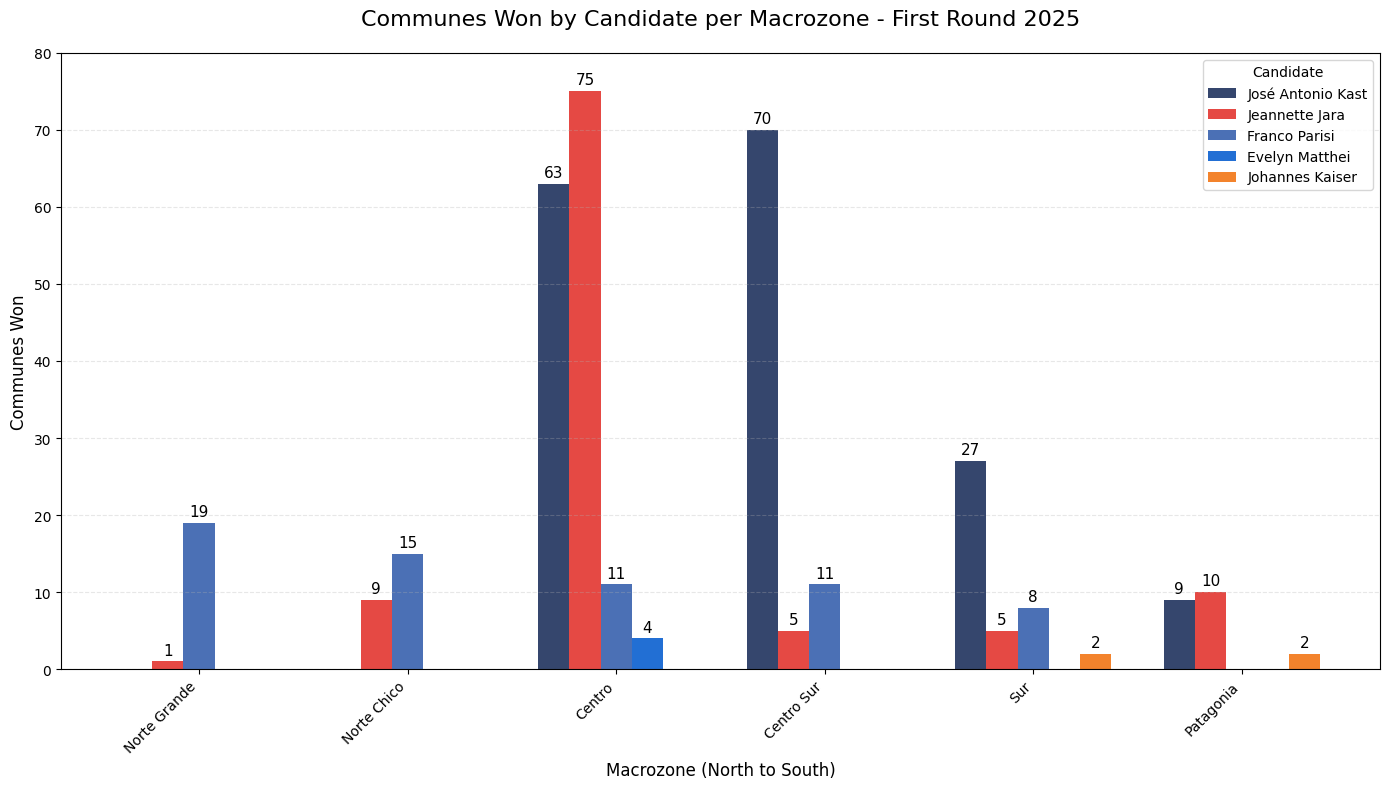

In [22]:
# ============================================================================
# COMMUNES WON PER CANDIDATE x MACROZONE (GROUPED BAR CHART)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np


def plot_communes_won_by_zone(df_votes: pd.DataFrame, df_region_dim: pd.DataFrame) -> None:
    """
    Creates a grouped bar chart showing communes won by each candidate per macrozone.

    Parameters
    ----------
    df_votes : pd.DataFrame
    df_region_dim : pd.DataFrame
    """
    main_candidates = {
        'jara_pct':    'Jeannette Jara',
        'kast_pct':    'José Antonio Kast',
        'parisi_pct':  'Franco Parisi',
        'kaiser_pct':  'Johannes Kaiser',
        'matthei_pct': 'Evelyn Matthei',
    }

    df_merged = df_votes.merge(
        df_region_dim[['region', 'macrozone', 'macrozone_order']],
        on='region', how='left',
    )
    cols_pct = list(main_candidates.keys())
    df_merged['winner'] = df_merged[cols_pct].idxmax(axis=1).map(main_candidates)

    pivot = pd.crosstab(df_merged['winner'], df_merged['macrozone'], margins=False)
    for candidate in main_candidates.values():
        if candidate not in pivot.index:
            pivot.loc[candidate] = 0

    macrozone_order = (
        df_region_dim[['macrozone', 'macrozone_order']]
        .drop_duplicates()
        .sort_values('macrozone_order')['macrozone']
        .tolist()
    )
    pivot = pivot[macrozone_order]
    pivot['Total']   = pivot.sum(axis=1)
    candidates_order = pivot.sort_values('Total', ascending=False).index.tolist()
    pivot            = pivot.loc[candidates_order].drop(columns=['Total'])

    colors = {
        'Jeannette Jara':    '#E54944',
        'José Antonio Kast': '#35466D',
        'Franco Parisi':     '#4B70B5',
        'Johannes Kaiser':   '#F3832C',
        'Evelyn Matthei':    '#226FD4',
    }

    fig, ax = plt.subplots(figsize=(14, 8))
    x       = np.arange(len(macrozone_order))
    width   = 0.15
    offsets = np.linspace(-0.3, 0.3, len(candidates_order))

    for i, candidate in enumerate(candidates_order):
        values = pivot.loc[candidate].values
        bars   = ax.bar(x + offsets[i], values, width,
                        label=candidate, color=colors.get(candidate, '#D3D3D3'))
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        str(int(val)), ha='center', va='bottom', fontsize=11)

    ax.set_xlabel('Macrozone (North to South)', fontsize=12)
    ax.set_ylabel('Communes Won', fontsize=12)
    ax.set_title('Communes Won by Candidate per Macrozone - First Round 2025',
                 fontsize=16, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(macrozone_order, rotation=45, ha='right')
    ax.legend(loc='upper right', fontsize=10, title='Candidate')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, pivot.values.max() + 5)
    plt.tight_layout()
    plt.show()


plot_communes_won_by_zone(df_votes, df_region_dim)

#### Análisis por Macrozona

**Norte Grande y Norte Chico:** Franco Parisi logró un dominio sin precedentes. La gran mayoría de las comunas de las cuatro regiones nortinas cayeron bajo su esfera de influencia, convirtiendo ese territorio en un bloque político prácticamente uniforme. La combinación de crisis migratoria, delincuencia organizada en zonas fronterizas, economías mineras con sensación de extractivismo centralizado y el débil desempeño histórico del Estado en la zona crearon las condiciones para que el antisistema se instalara como hegemonía regional, no como excepción.

**Centro (Región Metropolitana y Valparaíso):** Jeannette Jara impuso su supremacía en la zona de mayor peso demográfico del país. Aquí se concentra aproximadamente el 45-50% de la población nacional, lo que explica por qué Jara pudo liderar la primera vuelta con menos comunas totales que Kast: la eficiencia demográfica de sus victorias es muy superior. Las comunas del Gran Santiago y el Gran Valparaíso producen votos en grandes volúmenes, compensando con creces la desventaja en cobertura territorial.

**Centro Sur y Sur:** José Antonio Kast exhibió dominio contundente. Desde el Maule hasta Los Lagos, las zonas rurales, semi-rurales, agrícolas y forestales respondieron a su discurso con alta intensidad. La Araucanía, Ñuble y el Biobío fueron sus bastiones más sólidos: regiones donde el conflicto territorial, la violencia rural y la percepción de un Estado ausente o capturado por la agenda progresista generaron un rechazo categórico al oficialismo.

**Patagonia:** El territorio se distribuyó principalmente entre Jara y Kast, con presencia marginal de Kaiser. La lejanía geográfica y el aislamiento generan una dinámica electoral particular: mayor peso relativo de factores locales e identidad regional por sobre las narrativas nacionales.

#### La Paradoja Territorio-Demografía

La disociación cuantitativa es elocuente:

- Kast controló el 48,8% del territorio comunal pero obtuvo el 23,96% de los votos.
- Jara ganó en el 30,3% de las comunas pero concentró el 26,75% de los votos.
- Parisi dominó el 18,5% de las comunas con el 19,80% de los votos —la proporción más equilibrada entre territorio y voto de los tres finalistas.

Esta aritmética tiene una lectura política directa: **ganar muchas comunas pequeñas no equivale a tener más poder electoral en un sistema de segunda vuelta**, donde lo que cuenta es el total de votos válidos nacionales. Sin embargo, la cobertura territorial de Kast no es irrelevante: implica una base más diversificada geográficamente, con mayor resistencia a variaciones en la participación regional, y una red de lealtades locales que es activo valioso para el balotaje.

## 7. Resultados por Región

La primera vuelta presidencial de 2025 consolidó una **trifurcación territorial** del voto que va más allá de la simple división norte-sur. Emergieron tres realidades electorales con lógicas propias, demandas diferenciadas y ganadores distintos: el Norte antisistema, el Centro urbano-progresista y el Centro-Sur rural-conservador. Esta segmentación no es nueva —en 2021 ya se esbozaban sus contornos— pero en 2025 se profundizó y clarificó, alcanzando niveles de cohesión interna que dificultan la construcción de coaliciones transversales.

Esta sección analiza el desempeño por región, identifica las regiones bisagra que resultaron determinantes para la segunda vuelta y examina los gradientes de transición que revelan la complejidad del mapa político chileno.

In [23]:
# ============================================================================
# REGIONAL RESULTS AGGREGATION
# ============================================================================

# Lookup dictionaries derived from the dimension table
REGION_ORDER     = dict(zip(df_region_dim['region'], df_region_dim['region_order']))
MACROZONE_BY_REG = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))

CANDIDATE_KEYS = [
    'jara', 'kast', 'parisi', 'kaiser',
    'matthei', 'mayne_nicholls', 'enriquez_ominami', 'artes',
]

KEY_TO_NAME = {
    'jara':             'Jeannette Jara',
    'kast':             'José Antonio Kast',
    'parisi':           'Franco Parisi',
    'kaiser':           'Johannes Kaiser',
    'matthei':          'Evelyn Matthei',
    'mayne_nicholls':   'Harold Mayne-Nicholls',
    'enriquez_ominami': 'Marco Enriquez-Ominami',
    'artes':            'Eduardo Artes',
}


def analyze_results_by_region(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates votes by region, calculates percentages over valid votes,
    determines the regional winner and orders from north to south.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with vote columns per candidate.

    Returns
    -------
    pd.DataFrame
        Columns: region, regional_winner, and percentage per candidate.
    """
    cols_agg = (
        {f'{c}_votes': 'sum' for c in CANDIDATE_KEYS}
        | {'casted_votes': 'sum', 'blank_votes': 'sum', 'null_votes': 'sum'}
    )
    agg = df.groupby('region').agg(cols_agg).reset_index()

    # Protect against division by zero
    agg['valid_votes'] = (
        agg['casted_votes'] - agg['blank_votes'] - agg['null_votes']
    ).replace(0, 1)

    for cand in CANDIDATE_KEYS:
        agg[f'{cand}_percentage'] = round(
            (agg[f'{cand}_votes'] / agg['valid_votes']) * 100, 2
        )

    pct_cols = [f'{c}_percentage' for c in CANDIDATE_KEYS]
    agg['regional_winner'] = (
        agg[pct_cols]
        .idxmax(axis=1)
        .str.replace('_percentage', '', regex=False)
        .map(KEY_TO_NAME)
    )

    result = agg[['region', 'regional_winner'] + pct_cols].copy()
    result['order'] = result['region'].map(REGION_ORDER).fillna(99)
    result = result.sort_values('order').drop(columns='order').reset_index(drop=True)
    return result


regional_results = analyze_results_by_region(df_votes)
regional_results

,region,regional_winner,jara_percentage,kast_percentage,parisi_percentage,kaiser_percentage,matthei_percentage,mayne_nicholls_percentage,enriquez_ominami_percentage,artes_percentage
0,Arica y Parinacota,Franco Parisi,22.77,21.91,27.84,18.09,6.69,0.96,1.15,0.58
1,Tarapacá,Franco Parisi,21.98,22.60,31.11,14.57,6.95,1.14,1.11,0.54
2,Antofagasta,Franco Parisi,23.35,18.02,34.99,13.08,7.47,1.39,1.14,0.53
3,Atacama,Franco Parisi,26.45,18.81,32.60,13.13,6.29,1.01,1.16,0.55
4,Coquimbo,Jeannette Jara,27.49,19.05,26.72,13.75,10.08,1.13,1.20,0.59
5,Valparaíso,Jeannette Jara,29.56,20.26,19.50,15.39,11.88,1.40,1.31,0.70
6,Metropolitana,Jeannette Jara,31.14,21.82,14.26,12.86,16.44,1.46,1.25,0.77
7,Libertador,José Antonio Kast,24.49,25.50,21.91,13.86,11.35,1.13,1.24,0.53
8,Maule,José Antonio Kast,21.59,30.51,22.15,13.65,9.61,0.93,1.11,0.45
9,Ñuble,José Antonio Kast,19.03,31.64,22.10,15.11,9.71,0.87,1.01,0.52


El análisis regional confirma la **trifurcación territorial** del voto, pero también revela matices que la simple asignación de colores oculta.

#### Los Tres Chiles Electorales

**1. Chile Norteño (Dominio de Parisi)**
**Regiones:** Arica y Parinacota, Tarapacá, Antofagasta, Atacama.
Parisi ganó las cuatro regiones del Norte con porcentajes que van del 27,8% en Atacama al 35% en Antofagasta. Lo notable no es solo que ganó, sino que lo hizo por márgenes amplios sobre el segundo lugar. El Norte no estuvo "disputado": fue territorio cerrado para el antisistema.

Las economías del Norte Gran están atadas a la minería del cobre y el litio —Chile concentra el 27% de las reservas mundiales de litio en el norte— pero los habitantes de esas regiones perciben que los beneficios de esa riqueza no se redistribuyen localmente. A eso se suma la crisis migratoria: la Región de Tarapacá tiene la mayor proporción de migrantes per cápita del país, con los consecuentes impactos en el mercado laboral informal, servicios de salud y percepción de inseguridad. Parisi condensó esas demandas mejor que cualquier otro candidato.

**2. Chile Central (Dominio de Jara)**
**Regiones:** Coquimbo, Valparaíso, Metropolitana (más Aysén y Magallanes en el sur extremo).
Jara ganó cinco regiones, con su mejor resultado en la Metropolitana (31,14%). La densidad de estas regiones las convierte en el núcleo del electorado nacional: la Región Metropolitana sola concentra el 40% del padrón electoral chileno.

Coquimbo es el caso más interesante: Jara ganó, pero por apenas 0,77 puntos sobre Parisi. Es la frontera norte del dominio de la izquierda institucional, donde el efecto antisistema ya erosionaba con fuerza.

**3. Chile Centro-Sur y Sur (Dominio de Kast)**
**Regiones:** Libertador O'Higgins, Maule, Ñuble, Biobío, La Araucanía, Los Ríos, Los Lagos.
Kast ganó siete regiones. Sus mayores porcentajes en La Araucanía (32,56%) y Maule (~30%) no sorprenden dado el perfil rural de esas regiones y el impacto del conflicto territorial en el sur. Lo más significativo es que Kast venció en O'Higgins por apenas 1,01 puntos —la región más reñida de toda la elección—, lo que ilustra que la frontera entre el Chile central de Jara y el Chile sureño de Kast corre justo por esa región.

#### Patrones Estructurales

- **Correlación economía-voto.** Existe una relación relativamente consistente entre el tipo de economía regional y la preferencia política: economías extractivo-mineras → antisistema (Norte); economías de servicios y alta densidad → izquierda institucional (Centro); economías primario-exportadoras rurales → derecha conservadora (Centro Sur).

- **El conflicto en La Araucanía como variable independiente.** La región registra los niveles más altos de violencia rural desde 2018, con quema de maquinaria, atentados a predios y ocupaciones de tierra. Este conflicto generó un voto de rechazo hacia el oficialismo (percibido como incapaz de resolverlo) y de apoyo a Kast, quien propuso medidas más directas. La Araucanía fue en 2025 la región más favorable para Kast de todo el país.

- **Patagonia como zona de alta volatilidad.** Aysén y Magallanes votaron por Jara en primera vuelta, pero por márgenes no amplios. Son regiones con lógicas electorales propias, mayor proporción de trabajadores estatales y empleados de la acuicultura, y sensibilidad particular a los temas de conectividad y aislamiento geográfico.

#### Regiones Bisagra

| Región               | Ganador (1ªV) | Diferencia 1°–2° | Significancia estratégica          |
| -------------------- | ------------- | ---------------- | ---------------------------------- |
| Coquimbo             | Jara          | **0,77 pp**      | Frontera norte del dominio de Jara |
| Libertador O'Higgins | Kast          | **1,01 pp**      | La región más disputada del país   |
| Biobío               | Kast          | 2,00 pp          | Zona de triple competencia         |
| Los Ríos             | Kast          | 2,44 pp          | Transición hacia el sur            |

Estas cuatro regiones funcionaron como **laboratorios electorales**: pequeñas variaciones en participación diferencial, transferencias de voto o movilización selectiva podían alterar el resultado regional y, en elecciones ajustadas, el resultado nacional. En la segunda vuelta, representaron los territorios de mayor incertidumbre.

### 7.1. Mapa: Ganadores regionales

/tmp/ipykernel_35345/4238050403.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = communes_clean.geometry.centroid


Polygons excluded (islands / Antarctic): 2
Continental map ready: 16 regions
Map saved to 'regional_maps/regional_winners_map.png'


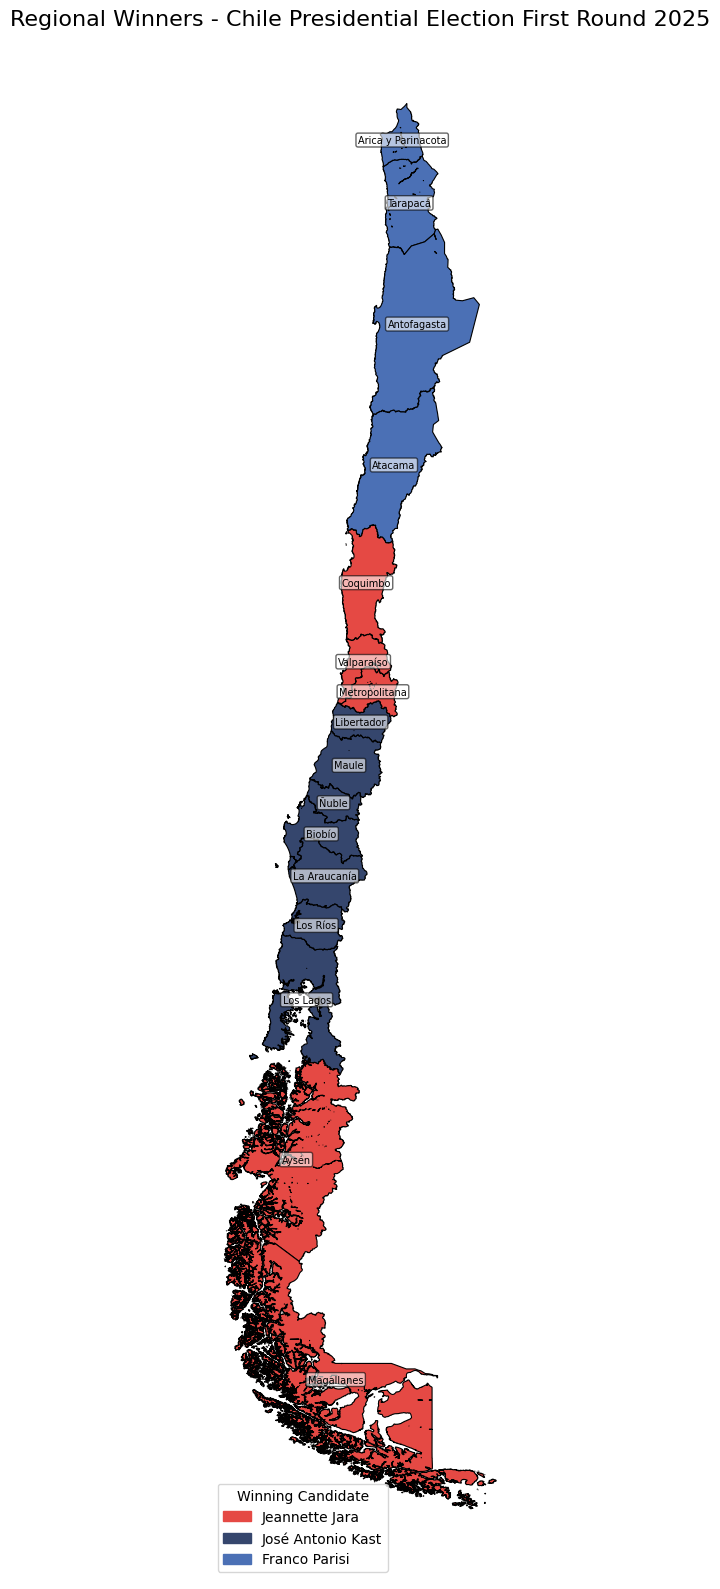

In [24]:
%matplotlib inline

import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================================
# REGIONAL WINNER CHOROPLETH
# ============================================================================

assert 'df_votes' in dir(), "Variable 'df_votes' not defined. Load data first."
assert 'communes' in dir(), "Variable 'communes' not defined. Run geographic data cell first."

# Region code lookup (numeric) for GeoDataFrame merge
REGION_TO_NUM = dict(zip(df_region_dim['region'], df_region_dim['region_code']))

# --- 1. Compute winner per region ---
regions_agg = df_votes.groupby('region').agg(
    {f'{c}_votes': 'sum' for c in CANDIDATE_KEYS}
    | {'casted_votes': 'sum', 'blank_votes': 'sum', 'null_votes': 'sum'}
).reset_index()

regions_agg['valid_votes'] = (
    regions_agg['casted_votes'] - regions_agg['blank_votes'] - regions_agg['null_votes']
).replace(0, 1)

for cand in CANDIDATE_KEYS:
    regions_agg[f'{cand}_pct'] = regions_agg[f'{cand}_votes'] / regions_agg['valid_votes'] * 100

pct_cols        = [f'{c}_pct' for c in CANDIDATE_KEYS]
COL_PCT_TO_NAME = {f'{c}_pct': n for c, n in KEY_TO_NAME.items()}
regions_agg['winner'] = regions_agg[pct_cols].idxmax(axis=1).map(COL_PCT_TO_NAME)

regions_agg['REGION_NUM'] = regions_agg['region'].map(REGION_TO_NUM)
unmapped = regions_agg.loc[regions_agg['REGION_NUM'].isna(), 'region'].tolist()
if unmapped:
    print(f'Regions without numeric mapping: {unmapped}')

regions_agg = regions_agg.dropna(subset=['REGION_NUM'])
regions_agg['REGION_NUM'] = regions_agg['REGION_NUM'].astype(int)

# --- 2. Filter continental Chile, excluding islands and Antarctic territory ---
BBOX = dict(lon_min=-76, lon_max=-65, lat_min=-56, lat_max=-17)

communes_clean = communes.copy()
communes_clean['geometry'] = communes_clean['geometry'].buffer(0)

centroids = communes_clean.geometry.centroid
mask = (
    centroids.x.between(BBOX['lon_min'], BBOX['lon_max']) &
    centroids.y.between(BBOX['lat_min'], BBOX['lat_max'])
)
print(f'Polygons excluded (islands / Antarctic): {(~mask).sum()}')
communes_continental = communes_clean[mask].copy()

# Dissolve commune polygons into regions
regions_geom = communes_continental.dissolve(by='REGION_NUM', aggfunc='first').reset_index()
map_gdf = regions_geom.merge(regions_agg, on='REGION_NUM', how='left')
map_gdf['winner'] = map_gdf['winner'].fillna('No data')
map_gdf['color']  = map_gdf['winner'].map(CANDIDATE_COLORS)
print(f'Continental map ready: {len(map_gdf)} regions')

# --- 3. Render choropleth ---
fig, ax = plt.subplots(1, 1, figsize=(12, 16))
map_gdf.plot(ax=ax, color=map_gdf['color'], edgecolor='black', linewidth=0.8)

for _, row in map_gdf.iterrows():
    if row.geometry and row['winner'] != 'No data':
        c = row.geometry.centroid
        label = str(row.get('region', ''))[:20]
        ax.text(c.x, c.y, label, fontsize=7, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

present_winners = map_gdf['winner'].unique()
patches = [
    mpatches.Patch(color=CANDIDATE_COLORS[c], label=c)
    for c in CANDIDATE_COLORS
    if c in present_winners and c != 'No data'
]
ax.legend(handles=patches, loc='lower left', title='Winning Candidate', fontsize=10)
ax.set_title('Regional Winners - Chile Presidential Election First Round 2025', fontsize=16)
ax.set_axis_off()
plt.tight_layout()

os.makedirs('regional_maps', exist_ok=True)
output_path = 'regional_maps/regional_winners_map.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Map saved to '{output_path}'")
plt.show()

### 7.2. Brechas en el apoyo regional

In [25]:
# ============================================================================
# WINNER-RUNNER-UP GAP BY REGION
# ============================================================================

def regional_support_gaps(df: pd.DataFrame, df_region_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates the percentage difference between the winning candidate and the
    runner-up in each region, using aggregated vote totals weighted by population.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with region and candidate vote columns.
    df_region_dim : pd.DataFrame
        Region dimension table with 'region' and 'region_order'.

    Returns
    -------
    pd.DataFrame
        Columns: region, winner, winner_percentage, runner_up,
        runner_up_percentage, difference_pct.
    """
    region_order = dict(zip(df_region_dim['region'], df_region_dim['region_order']))

    # Restrict to the 5 main candidates for gap analysis
    main_keys = ['jara', 'kast', 'parisi', 'kaiser', 'matthei']

    cols_agg = (
        {f'{c}_votes': 'sum' for c in main_keys}
        | {'casted_votes': 'sum', 'blank_votes': 'sum', 'null_votes': 'sum'}
    )
    agg = df.groupby('region').agg(cols_agg).reset_index()
    agg['valid_votes'] = (
        agg['casted_votes'] - agg['blank_votes'] - agg['null_votes']
    ).replace(0, 1)

    for cand in main_keys:
        agg[f'{cand}_pct'] = (agg[f'{cand}_votes'] / agg['valid_votes']) * 100

    main_names = {
        'Jeannette Jara':    'jara_pct',
        'José Antonio Kast': 'kast_pct',
        'Franco Parisi':     'parisi_pct',
        'Johannes Kaiser':   'kaiser_pct',
        'Evelyn Matthei':    'matthei_pct',
    }

    rows = []
    for _, row in agg.iterrows():
        percentages  = {name: row[col] for name, col in main_names.items()}
        sorted_cands = sorted(percentages.items(), key=lambda x: x[1], reverse=True)
        rows.append({
            'region':               row['region'],
            'winner':               sorted_cands[0][0],
            'winner_percentage':    round(sorted_cands[0][1], 2),
            'runner_up':            sorted_cands[1][0],
            'runner_up_percentage': round(sorted_cands[1][1], 2),
            'difference_pct':       round(sorted_cands[0][1] - sorted_cands[1][1], 2),
        })

    result          = pd.DataFrame(rows)
    result['order'] = result['region'].map(region_order).fillna(99)
    result          = result.sort_values('order').drop(columns='order').reset_index(drop=True)
    return result


regional_gaps = regional_support_gaps(df_votes, df_region_dim)
display(regional_gaps)

,region,winner,winner_percentage,runner_up,runner_up_percentage,difference_pct
0,Arica y Parinacota,Franco Parisi,27.84,Jeannette Jara,22.77,5.07
1,Tarapacá,Franco Parisi,31.11,José Antonio Kast,22.60,8.51
2,Antofagasta,Franco Parisi,34.99,Jeannette Jara,23.35,11.64
3,Atacama,Franco Parisi,32.60,Jeannette Jara,26.45,6.15
4,Coquimbo,Jeannette Jara,27.49,Franco Parisi,26.72,0.77
5,Valparaíso,Jeannette Jara,29.56,José Antonio Kast,20.26,9.30
6,Metropolitana,Jeannette Jara,31.14,José Antonio Kast,21.82,9.32
7,Libertador,José Antonio Kast,25.50,Jeannette Jara,24.49,1.01
8,Maule,José Antonio Kast,30.51,Franco Parisi,22.15,8.36
9,Ñuble,José Antonio Kast,31.64,Franco Parisi,22.10,9.54


Más allá del ganador absoluto en cada región, el análisis de las brechas entre primero y segundo lugar revela la estructura interna de la competencia y permite identificar zonas de alta tensión electoral que definieron la dinámica del balotaje.

#### Gradiente Norte-Sur: Transición y Competitividad

El análisis de las diferencias entre primer y segundo lugar muestra un **gradiente geográfico claro**, pero con puntos de inflexión que merecen atención particular:

- **Norte Grande (Arica a Antofagasta):** Dominio amplio de Parisi, con diferencias de 5 a 12 puntos sobre el segundo lugar. La intensidad del voto norteño es tal que Jara, que en el Centro gana con holgura, aparece relegada a un segundo o tercer lugar distante.

- **Coquimbo — el punto de quiebre:** Con solo 0,77 puntos de diferencia entre Jara y Parisi, esta región marca la frontera norte del dominio progresista. Es también donde el "efecto Parisi" empieza a diluirse y donde el voto obligatorio incorporó una masa de electores con sensibilidades más cercanas al Norte que al Centro.

- **Valparaíso y Metropolitana:** Dominio de Jara con diferencias de 9 puntos sobre el segundo, que en ambas regiones es Kast. En la RM, el resultado de Jara (31,14%) contrasta con el de Kast (21,82%) de forma que no deja dudas sobre quién controla el corazón demográfico del país.

- **O'Higgins:** Zona de máxima tensión. Kast gana por apenas 1,01 puntos, en una región internamente dividida: las comunas más urbanas (Rancagua, San Fernando) son más favorables a Jara, mientras el hinterland rural y las comunas vitivinícolas y agrícolas favorecen a Kast.

- **Desde Maule hasta La Araucanía:** Reaparece Parisi como segunda fuerza, desplazando a Jara al tercer lugar. Este es un patrón inesperado: el antisistema logra ser segunda fuerza en zonas sureñas donde Kast domina, lo que revela que parte del descontento con el centralismo en el sur no fue capturado solo por la derecha conservadora.

- **Desde Los Ríos al sur:** Jara recupera el segundo lugar, pero las diferencias se reducen. Las regiones del sur extremo —Aysén, Magallanes— tienen una composición laboral distinta (trabajadores del Estado, acuicultura, pesca) que genera un electorado más favorable al progresismo que el sur agrícola del Maule o La Araucanía.

#### Comparación con la Primera Vuelta de 2021

En 2021, Sebastián Sichel (Chile Vamos) logró competir de forma más equilibrada en el centro-sur, obteniendo resultados superiores al 20% en la mayoría de las regiones. En 2025, Matthei —su sucesora en ese espacio— colapsó a niveles del 8-12% en prácticamente todas las regiones fuera de la RM, lo que indica que la migración del voto Chile Vamos hacia Kast se completó entre 2021 y 2025. Por otro lado, Parisi creció en todas las regiones sin excepción, lo que transforma el escenario tripartito: en varias regiones del sur, el duelo principal en segunda vuelta fue antecedido de una primera vuelta donde el segundo lugar ya no era Jara sino Parisi.

#### Implicancias Estratégicas para el Balotaje

Las regiones bisagra identificadas (O'Higgins, Coquimbo, Biobío, Los Ríos) fueron las de mayor valor estratégico para la segunda vuelta. En todas ellas, la diferencia entre los dos primeros fue inferior a 3 puntos, lo que implica que cualquier variación en movilización diferencial o transferencia de voto podía alterar el resultado regional. Dado que en estas regiones Parisi obtuvo entre el 15% y el 20%, la forma en que sus votantes se redistribuyeron fue el factor determinante.

## 8. Resultados en Capitales Regionales

Uno de los contrastes más reveladores de la primera vuelta presidencial de 2025 es la **brecha sistemática entre los resultados en capitales regionales y los resultados en el conjunto de cada región**. Esta brecha no es un detalle técnico: es un indicador de cómo distintos contextos socioeconómicos y funcionales —la ciudad capital versus el hinterland— producen comportamientos electorales radicalmente distintos, incluso dentro de una misma región administrativa.

Esta sección analiza cómo se comportó el voto en las 16 capitales regionales, revelando la dicotomía entre el Chile urbano-administrativo y el Chile rural-periférico, y destacando las implicancias estratégicas de esa división para la segunda vuelta.

In [26]:
# ============================================================================
# COMMUNE NAME NORMALISATION
# ============================================================================

def normalize_name(name: str) -> str:
    """
    Backward-compatible alias for normalize_commune_name (§2.4).
    Retained so downstream functions (regional capitals, gap analysis)
    continue to work without modification; all normalization logic is
    consolidated in normalize_commune_name.
    """
    return normalize_commune_name(name)


# ============================================================================
# REGIONAL CAPITAL RESULTS
# ============================================================================

def regional_capital_results(df: pd.DataFrame, df_region_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Filters the DataFrame to the 16 regional capitals and identifies the winning
    candidate in each with their percentage over local valid votes.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with 'commune', 'region', and candidate percentage columns.
    df_region_dim : pd.DataFrame
        Region dimension table with 'region' and 'region_order'.

    Returns
    -------
    pd.DataFrame
        Columns: capital, region, winner, winner_percentage and individual
        percentages for the 5 main candidates.
    """
    REGIONAL_CAPITALS = [
        'Arica', 'Iquique', 'Antofagasta', 'Copiapo', 'La Serena',
        'Valparaiso', 'Santiago', 'Rancagua', 'Talca', 'Chillan',
        'Concepcion', 'Temuco', 'Valdivia', 'Puerto Montt', 'Coyhaique',
        'Punta Arenas',
    ]

    capitals_norm = {normalize_name(c): c for c in REGIONAL_CAPITALS}
    region_order  = dict(zip(df_region_dim['region'], df_region_dim['region_order']))

    key_to_name_5 = {
        'jara':    'Jeannette Jara',
        'kast':    'José Antonio Kast',
        'parisi':  'Franco Parisi',
        'kaiser':  'Johannes Kaiser',
        'matthei': 'Evelyn Matthei',
    }

    df_tmp = df.copy()
    df_tmp['commune_norm'] = df_tmp['commune'].apply(normalize_name)
    cap_df = df_tmp[df_tmp['commune_norm'].isin(capitals_norm.keys())].copy()
    cap_df['capital'] = cap_df['commune_norm'].map(capitals_norm)

    missing = set(REGIONAL_CAPITALS) - set(cap_df['capital'].unique())
    if missing:
        print(f'Capitals not found in data: {missing}')

    cands_5    = ['jara', 'kast', 'parisi', 'kaiser', 'matthei']
    cols_pct_5 = [f'{c}_pct' for c in cands_5]

    cap_df['winner'] = (
        cap_df[cols_pct_5].idxmax(axis=1).str.replace('_pct', '', regex=False).map(key_to_name_5)
    )
    cap_df['winner_percentage'] = cap_df[cols_pct_5].max(axis=1)

    result          = cap_df[['capital', 'region', 'winner', 'winner_percentage'] + cols_pct_5].copy()
    result['order'] = result['region'].map(region_order).fillna(99)
    result          = result.sort_values('order').drop(columns='order').reset_index(drop=True)
    return result


capital_results = regional_capital_results(df_votes, df_region_dim)
capital_results

,capital,region,winner,winner_percentage,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct
0,Arica,Arica y Parinacota,Franco Parisi,27.68,22.97,21.79,27.68,18.16,6.69
1,Iquique,Tarapacá,Jeannette Jara,25.03,25.03,23.71,24.26,15.60,8.34
2,Antofagasta,Antofagasta,Franco Parisi,32.54,24.71,17.98,32.54,12.99,8.44
3,Copiapo,Atacama,Franco Parisi,30.51,25.89,20.26,30.51,13.48,6.88
4,La Serena,Coquimbo,Jeannette Jara,28.72,28.72,18.95,21.90,14.68,12.59
5,Valparaiso,Valparaíso,Jeannette Jara,36.34,36.34,17.11,16.59,15.23,10.67
6,Santiago,Metropolitana,Jeannette Jara,32.71,32.71,20.73,7.20,12.80,23.11
7,Rancagua,Libertador,Jeannette Jara,26.54,26.54,21.54,22.62,14.08,11.91
8,Talca,Maule,Jeannette Jara,26.65,26.65,25.36,20.15,12.97,12.03
9,Chillan,Ñuble,José Antonio Kast,27.70,22.65,27.70,20.29,15.21,11.35


### 8.1. Deficiencias en el apoyo en las 16 capitales regionales

In [27]:
# ============================================================================
# WINNER-RUNNER-UP GAP IN REGIONAL CAPITALS
# ============================================================================

def capital_support_gaps(df: pd.DataFrame, df_region_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates the percentage difference between the winning candidate and the
    runner-up in each regional capital, quantifying the victory margin.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with 'commune', 'region', and candidate percentage columns.
    df_region_dim : pd.DataFrame
        Region dimension table with 'region' and 'region_order'.

    Returns
    -------
    pd.DataFrame
        Columns: capital, region, winner, winner_percentage,
        runner_up, runner_up_percentage, difference_pct.
    """
    REGIONAL_CAPITALS = [
        'Arica', 'Iquique', 'Antofagasta', 'Copiapo', 'La Serena',
        'Valparaiso', 'Santiago', 'Rancagua', 'Talca', 'Chillan',
        'Concepcion', 'Temuco', 'Valdivia', 'Puerto Montt', 'Coyhaique',
        'Punta Arenas',
    ]

    capitals_norm = {normalize_name(c): c for c in REGIONAL_CAPITALS}
    region_order  = dict(zip(df_region_dim['region'], df_region_dim['region_order']))

    candidate_pct_cols = {
        'Jeannette Jara':    'jara_pct',
        'José Antonio Kast': 'kast_pct',
        'Franco Parisi':     'parisi_pct',
        'Johannes Kaiser':   'kaiser_pct',
        'Evelyn Matthei':    'matthei_pct',
    }

    df_tmp = df.copy()
    df_tmp['commune_norm'] = df_tmp['commune'].apply(normalize_name)
    cap_df = df_tmp[df_tmp['commune_norm'].isin(capitals_norm.keys())].copy()
    cap_df['capital'] = cap_df['commune_norm'].map(capitals_norm)

    rows = []
    for _, row in cap_df.iterrows():
        percentages  = {name: row[col] for name, col in candidate_pct_cols.items()}
        sorted_cands = sorted(percentages.items(), key=lambda x: x[1], reverse=True)
        rows.append({
            'capital':              row['capital'],
            'region':               row['region'],
            'winner':               sorted_cands[0][0],
            'winner_percentage':    round(sorted_cands[0][1], 2),
            'runner_up':            sorted_cands[1][0],
            'runner_up_percentage': round(sorted_cands[1][1], 2),
            'difference_pct':       round(sorted_cands[0][1] - sorted_cands[1][1], 2),
        })

    result          = pd.DataFrame(rows)
    result['order'] = result['region'].map(region_order).fillna(99)
    result          = result.sort_values('order').drop(columns='order').reset_index(drop=True)
    return result


capital_gaps = capital_support_gaps(df_votes, df_region_dim)
capital_gaps

,capital,region,winner,winner_percentage,runner_up,runner_up_percentage,difference_pct
0,Arica,Arica y Parinacota,Franco Parisi,27.68,Jeannette Jara,22.97,4.71
1,Iquique,Tarapacá,Jeannette Jara,25.03,Franco Parisi,24.26,0.77
2,Antofagasta,Antofagasta,Franco Parisi,32.54,Jeannette Jara,24.71,7.83
3,Copiapo,Atacama,Franco Parisi,30.51,Jeannette Jara,25.89,4.62
4,La Serena,Coquimbo,Jeannette Jara,28.72,Franco Parisi,21.90,6.82
5,Valparaiso,Valparaíso,Jeannette Jara,36.34,José Antonio Kast,17.11,19.23
6,Santiago,Metropolitana,Jeannette Jara,32.71,Evelyn Matthei,23.11,9.60
7,Rancagua,Libertador,Jeannette Jara,26.54,Franco Parisi,22.62,3.92
8,Talca,Maule,Jeannette Jara,26.65,José Antonio Kast,25.36,1.29
9,Chillan,Ñuble,José Antonio Kast,27.70,Jeannette Jara,22.65,5.05


### Análisis Urbano-Rural: La Brecha de los Dos Chiles

El hallazgo más estructural de la sección de capitales regionales es la **inversión del mapa de poder** que ocurre al pasar de las capitales al territorio regional completo.

#### Control de Capitales vs. Control Territorial

| Candidato             | Capitales Ganadas | % Capitales | Regiones Ganadas | % Regiones | Interpretación                   |
| --------------------- | ----------------- | ----------- | ---------------- | ---------- | -------------------------------- |
| **Jeannette Jara**    | **10 / 16**       | **62,5%**   | 5 / 16           | 31,3%      | Fenómeno urbano-capital          |
| **José Antonio Kast** | 4 / 16            | 25,0%       | **7 / 16**       | **43,8%**  | Fenómeno rural-territorial       |
| **Franco Parisi**     | 2 / 16            | 12,5%       | 4 / 16           | 25,0%      | Fenómeno norteño con debilidad urbana |
| Matthei / Kaiser      | 0                 | 0%          | 0                | 0%         | Sin representación regional      |

**La paradoja es nítida:** Jara ganó 10 de 16 capitales y solo 5 de 16 regiones. Kast ganó 4 capitales y 7 regiones. Esto significa que las capitales "votan distinto" a sus propias regiones, y de forma muy consistente: son más favorables a Jara, menos favorables a Kast, y casi impermeables a Parisi fuera del Norte.

#### Lecturas por Candidato

**Jeannette Jara — La candidata de las ciudades-capital.** Su dominio en capitales como Valparaíso (36,34%), La Serena (28,72%) y Valdivia (31,03%) refleja el peso del voto universitario, de empleados públicos y de sectores de servicios que se concentran en estas ciudades. Incluso en regiones donde pierde (La Araucanía, Maule), Jara logra resultados respetables en Temuco y Talca, evidenciando que las capitales actúan como "islas progresistas" dentro de regiones conservadoras.

**José Antonio Kast — Más fuerte en el hinterland que en la capital.** Kast gana capitales como Temuco, Puerto Montt y Chillán —ciudades que combinan funciones administrativas con un fuerte entorno rural próximo—, pero su ventaja real está en el territorio circundante a esas ciudades, no en ellas mismas. En Temuco, por ejemplo, gana en la capital pero con margen menor que en comunas rurales adyacentes de La Araucanía.

**Franco Parisi — Debilidad urbana estructural.** Parisi solo gana Antofagasta e Iquique entre las capitales regionales. En todas las demás —incluyendo capitales de regiones que ganó en el agregado regional, como Arica y Copiapó— pierde ante Jara. Esto confirma que su voto es significativamente más fuerte en comunas rurales, mineras y fronterizas que en los centros urbanos consolidados, incluso del Norte.

**Evelyn Matthei — Subrepresentación urbana generalizada.** Matthei obtiene su mejor resultado en Santiago (23,11%), donde la alta concentración de sectores de altos ingresos le brinda su "base natural". Fuera de ese enclave, su promedio en capitales regionales cae a niveles del 10-11%, confirmando que el colapso de Chile Vamos no es un fenómeno solo rural o periférico, sino transversal, incluyendo las ciudades.

**Johannes Kaiser — El caso más sorprendente.** Kaiser muestra mejor performance relativa en capitales (~15,4%) que en su promedio nacional (13,94%). Destaca en Coyhaique (20,62%) y Punta Arenas (17,23%), lo que sugiere que su electorado —urbano, joven, con alta conectividad a redes sociales y debate ideológico en línea— se concentra más en ciudades que en el mundo rural, a diferencia del patrón de Kast.

#### Iquique: el caso más revelador

Iquique registra un empate técnico entre Jara y Kast en torno al 25%, con Parisi en tercer lugar por debajo de ambos. Este resultado es excepcional: en una capital regional del Norte Grande —zona de dominio de Parisi en el agregado regional—, los dos candidatos del "duopolio" logran desplazarlo. Iquique, con mayor presencia de sectores medios formales, comercio y funcionariado, muestra que la debilidad urbana de Parisi aplica incluso en su bastión geográfico.

#### Implicancias para la Segunda Vuelta

La brecha capital-hinterland tiene una lectura estratégica directa: en la segunda vuelta, las capitales regionales funcionan como **multiplicadores de voto** para Jara, mientras el territorio circundante lo es para Kast. La movilización diferencial en uno u otro sentido —especialmente en regiones bisagra como O'Higgins, Biobío y Los Ríos— puede ser determinante cuando los márgenes son estrechos.

## 9. Comportamiento Electoral en Centros Urbanos

Un aspecto central para comprender la primera vuelta presidencial de 2025 es el **gradiente urbano-rural del voto**, que en esta elección se manifestó con una claridad y consistencia inusual. Esta sección analiza cómo varió el comportamiento electoral según el tamaño poblacional de las comunas, desde las grandes metrópolis hasta las localidades rurales más pequeñas.

El análisis revela una correlación casi perfecta entre tamaño comunal y preferencia de voto: mientras mayor y más densa es la comuna, más favorece a Jeannette Jara; mientras más pequeña y rural, más se inclina hacia José Antonio Kast. Esta regularidad no es aleatoria: expresa diferencias estructurales en el tipo de demandas, la inserción en el mercado laboral y la relación con el Estado según el tipo de territorio.

### 9.1. Grandes centros urbanos (> 200.000 habitantes)

In [28]:
# ============================================================================
# LARGE URBAN CENTERS (> 200,000 INHABITANTS)
# ============================================================================

# ============================================================================
# SHARED SETUP: NORMALIZATION, CANDIDATE MAP, DATA LOAD AND MERGE
# ============================================================================

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

# Load source data
df_votes      = pd.read_csv(url_votes, encoding='utf-8-sig')
df_pop        = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

df_votes['commune_norm'] = df_votes['commune'].apply(normalize_name)
df_pop['commune_norm']   = df_pop['commune'].apply(normalize_name)

df_merged = df_votes.merge(
    df_pop[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

candidates_5 = ['jara','kast','parisi','kaiser','matthei']
pct_cols     = [f'{c}_pct' for c in candidates_5]

df_urban = df_merged[df_merged['population'] > 200_000].copy()
df_urban = df_urban.sort_values('population', ascending=False)

pop_total    = df_urban['population'].sum()
pop_national = df_merged['population'].sum()
print(f'Communes: {len(df_urban)}')
print(f'Population covered: {pop_total:,} ({pop_total/pop_national*100:.1f}% national)')

# Determine commune winner
for col in pct_cols:
    df_urban[col] = df_urban[col].astype(float)
df_urban['winner'] = df_urban[pct_cols].idxmax(axis=1).str.replace('_pct','',regex=False).map(CANDIDATE_NAMES)

# Tables by macrozone (north to south)
table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    df_zone = df_urban[df_urban['macrozone'] == zone]
    if len(df_zone) > 0:
        print(f'\n{zone.upper()} ({len(df_zone)} communes)')
        print('-'*80)
        display(df_zone[table_cols].round(2))

# Candidate summary
print('\nSUMMARY BY CANDIDATE')
stats_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = df_urban[df_urban['winner'] == cname]
    if len(subset) == 0:
        continue
    stats_rows.append({
        'candidate':       cname,
        'communes_won':    len(subset),
        'total_population':int(subset['population'].sum()),
        'pct_pop_segment': round(subset['population'].sum() / pop_total * 100, 1),
        'casted_votes':    int(subset['casted_votes'].sum()),
    })
df_stats = pd.DataFrame(stats_rows).sort_values('communes_won', ascending=False)
display(df_stats)


Communes: 21
Population covered: 6,443,321 (35.4% national)

NORTE GRANDE (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
0,Antofagasta,Antofagasta,Norte Grande,401096,255984,24.71,17.98,32.54,12.99,8.44,Franco Parisi



NORTE CHICO (2 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
68,Coquimbo,Coquimbo,Norte Chico,263719,167795,27.48,18.32,25.85,14.38,10.78,Jeannette Jara
78,la Serena,Coquimbo,Norte Chico,250141,174173,28.72,18.95,21.90,14.68,12.59,Jeannette Jara



CENTRO (14 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
104,Temuco,La Araucanía,Centro Sur,292518,211836,22.05,29.36,18.00,15.67,11.74,José Antonio Kast
38,Concepcion,Biobío,Centro Sur,230375,171339,28.00,24.22,16.42,13.33,14.51,Jeannette Jara
64,los Angeles,Biobío,Centro Sur,219441,159128,14.57,32.23,25.70,16.12,9.15,José Antonio Kast



SUR (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
161,Puerto Montt,Los Lagos,Sur,277040,185344,21.78,26.81,20.61,16.26,11.51,José Antonio Kast



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
0,Jeannette Jara,16,4957092,76.9,3467640
1,José Antonio Kast,3,788999,12.2,556308
2,Franco Parisi,1,401096,6.2,255984
3,Evelyn Matthei,1,296134,4.6,222675


**Hallazgo principal:** Jara ganó 16 de 21 comunas del segmento de más de 200.000 habitantes y controló el **76,9% de la población** de ese segmento —más de 3,46 millones de votantes—, su mayor ventaja relativa en cualquier categoría de tamaño.

#### Patrón Observado

La relación entre tamaño de la comuna y porcentaje de voto a Jara es positiva y consistente:

- En las comunas de más de 300.000 habitantes (Maipú, Puente Alto, La Florida, San Bernardo, Las Condes), Jara promedió entre 33% y 36% en sus victorias, con excepción de Las Condes —donde Kast o Matthei lideran por el perfil socioeconómico del electorado.
- En las comunas grandes donde Jara no domina (Temuco, Los Ángeles, Puerto Montt), el patrón se explica por el entorno cultural y económico predominante: ciudades grandes en términos absolutos, pero insertas en regiones de perfil rural-conservador, lo que "contamina" el voto urbano con las sensibilidades del territorio adyacente.
- El caso de Antofagasta es significativo: con más de 300.000 habitantes, debería ser terreno favorable para Jara según el gradiente general, pero aquí Parisi gana —confirmando que la singularidad del Norte Grande opera con una lógica propia que trasciende el tamaño demográfico.

#### Por qué Jara lidera en las grandes ciudades

Las ciudades grandes concentran tres tipos de electorado que favorecen a la izquierda institucional: (1) trabajadores de servicios y comercio con alta sindicalización y dependencia de políticas laborales del Estado; (2) sectores universitarios y profesionales jóvenes con identificación progresista; (3) poblaciones en vivienda social con dependencia directa de prestaciones estatales. La oferta de Jara —continuidad del gobierno de Boric en sus aspectos de política social, defensa de derechos laborales y ampliación de servicios— resonó con esas sensibilidades mejor que las alternativas disponibles.

#### Kast y Parisi en las grandes ciudades

Kast penetra en algunas ciudades grandes del sur (Temuco, Los Ángeles, Puerto Montt), donde el entorno regional compensa el efecto urbano. Parisi logra solo Antofagasta, confirmando que su modelo de apoyo no es escalable a contextos metropolitanos fuera del Norte.

### 9.2. Centros urbanos medianos (100.000 – 199.999 habitantes)

In [29]:
# ============================================================================
# MEDIUM URBAN CENTERS (100,000 - 199,999 INHABITANTS)
# ============================================================================

# ============================================================================
# SHARED SETUP: NORMALIZATION, CANDIDATE MAP, DATA LOAD AND MERGE
# ============================================================================

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

# Load source data
df_votes      = pd.read_csv(url_votes, encoding='utf-8-sig')
df_pop        = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

df_votes['commune_norm'] = df_votes['commune'].apply(normalize_name)
df_pop['commune_norm']   = df_pop['commune'].apply(normalize_name)

df_merged = df_votes.merge(
    df_pop[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

candidates_5 = ['jara','kast','parisi','kaiser','matthei']
pct_cols     = [f'{c}_pct' for c in candidates_5]

df_medium = df_merged[(df_merged['population'] >= 100_000) & (df_merged['population'] <= 199_999)].copy()
df_medium = df_medium.sort_values('population', ascending=False)

pop_total    = df_medium['population'].sum()
pop_national = df_merged['population'].sum()
print(f'Communes: {len(df_medium)}')
print(f'Population covered: {pop_total:,} ({pop_total/pop_national*100:.1f}% national)')

# Determine commune winner
for col in pct_cols:
    df_medium[col] = df_medium[col].astype(float)
df_medium['winner'] = df_medium[pct_cols].idxmax(axis=1).str.replace('_pct','',regex=False).map(CANDIDATE_NAMES)

# Tables by macrozone (north to south)
table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    df_zone = df_medium[df_medium['macrozone'] == zone]
    if len(df_zone) > 0:
        print(f'\n{zone.upper()} ({len(df_zone)} communes)')
        print('-'*80)
        display(df_zone[table_cols].round(2))

# Candidate summary
print('\nSUMMARY BY CANDIDATE')
stats_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = df_medium[df_medium['winner'] == cname]
    if len(subset) == 0:
        continue
    stats_rows.append({
        'candidate':       cname,
        'communes_won':    len(subset),
        'total_population':int(subset['population'].sum()),
        'pct_pop_segment': round(subset['population'].sum() / pop_total * 100, 1),
        'casted_votes':    int(subset['casted_votes'].sum()),
    })
df_stats = pd.DataFrame(stats_rows).sort_values('communes_won', ascending=False)
display(df_stats)


Communes: 35
Population covered: 5,063,889 (27.8% national)

NORTE GRANDE (3 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
284,Iquique,Tarapacá,Norte Grande,199587,131590,25.03,23.71,24.26,15.60,8.34,Jeannette Jara
1,Calama,Antofagasta,Norte Grande,166334,108350,18.69,19.28,38.98,14.37,6.09,Franco Parisi
280,Alto Hospicio,Tarapacá,Norte Grande,142086,60526,17.08,20.12,42.94,12.63,4.74,Franco Parisi



NORTE CHICO (2 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
16,Copiapo,Atacama,Norte Chico,168831,111212,25.89,20.26,30.51,13.48,6.88,Franco Parisi
71,Ovalle,Coquimbo,Norte Chico,118696,83715,24.73,20.40,31.41,13.16,7.77,Franco Parisi



CENTRO (23 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
184,Valdivia,Los Ríos,Sur,170043,125638,31.03,22.09,16.98,14.47,11.94,Jeannette Jara
159,Osorno,Los Lagos,Sur,166455,126161,24.75,24.58,21.02,16.46,10.19,Jeannette Jara



PATAGONIA (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
193,Punta Arenas,Magallanes,Patagonia,132363,96811,28.8,22.89,16.54,17.23,10.48,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
0,Jeannette Jara,21,3014611,59.5,2106407
1,José Antonio Kast,8,1185709,23.4,779985
2,Franco Parisi,5,719595,14.2,448382
3,Evelyn Matthei,1,143974,2.8,123633


**Hallazgo principal:** Jara **mantiene su liderazgo** en los centros urbanos medianos, pero con menor intensidad. Su control de la población del segmento cae del 76,9% (grandes ciudades) al **59,5%** (ciudades de 100.000-199.999 habitantes), mientras Kast aparece con mayor fuerza en el sur y centro-sur.

#### Tendencias por Candidato

**Jeannette Jara:** Gana 21 de 35 comunas del segmento (60%). Su porcentaje promedio se mantiene sólido en el Centro, especialmente en comunas de la RM y Valparaíso con perfil popular (Estación Central, La Pintana, Recoleta, San Miguel). Pierde terreno relativo en comunas medianas del centro-sur.

**José Antonio Kast:** Reaparece con claridad, ganando 8 comunas medianas. Sus victorias en este segmento se concentran en el Maule, Ñuble, Biobío y Los Lagos: ciudades intermedias como Chillán, Curicó y Melipilla donde el entorno rural próximo permea el comportamiento del voto urbano.

**Franco Parisi:** Gana 5 comunas medianas en el Norte Grande y Norte Chico (Calama, Alto Hospicio, Copiapó, Ovalle). Su performance en este segmento es coherente con su patrón general: presencia relevante en el Norte, pero limitada fuera de él.

**Evelyn Matthei:** Solo gana Providencia —una de las pocas comunas de alto ingreso en el segmento mediano—, confirmando su carácter de candidatura de nicho.

#### La Ciudad Mediana como Zona de Transición

Las ciudades de 100.000 a 200.000 habitantes son el primer nivel donde el "efecto ciudad" empieza a diluirse. Su composición socioeconómica es más heterogénea que la de las grandes metrópolis y su vínculo con el entorno rural es más estrecho. Esto crea un electorado mixto: sectores populares urbanos que votan como en las grandes ciudades (Jara), junto a capas medias-bajas y sectores con identidades más conservadoras que se acercan al patrón de Kast. La transición entre ambos patrones no es lineal: depende de la región, del perfil económico local y de la distancia cultural con el mundo rural adyacente.

### 9.3. Pequeños centros urbanos (50.000 – 99.999 habitantes)

In [30]:
# ============================================================================
# SMALL URBAN CENTERS (50,000 - 99,999 INHABITANTS)
# ============================================================================

# ============================================================================
# SHARED SETUP: NORMALIZATION, CANDIDATE MAP, DATA LOAD AND MERGE
# ============================================================================

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

# Load source data
df_votes      = pd.read_csv(url_votes, encoding='utf-8-sig')
df_pop        = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

df_votes['commune_norm'] = df_votes['commune'].apply(normalize_name)
df_pop['commune_norm']   = df_pop['commune'].apply(normalize_name)

df_merged = df_votes.merge(
    df_pop[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

candidates_5 = ['jara','kast','parisi','kaiser','matthei']
pct_cols     = [f'{c}_pct' for c in candidates_5]

df_small = df_merged[(df_merged['population'] >= 50_000) & (df_merged['population'] <= 99_999)].copy()
df_small = df_small.sort_values('population', ascending=False)

pop_total    = df_small['population'].sum()
pop_national = df_merged['population'].sum()
print(f'Communes: {len(df_small)}')
print(f'Population covered: {pop_total:,} ({pop_total/pop_national*100:.1f}% national)')

# Determine commune winner
for col in pct_cols:
    df_small[col] = df_small[col].astype(float)
df_small['winner'] = df_small[pct_cols].idxmax(axis=1).str.replace('_pct','',regex=False).map(CANDIDATE_NAMES)

# Tables by macrozone (north to south)
table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    df_zone = df_small[df_small['macrozone'] == zone]
    if len(df_zone) > 0:
        print(f'\n{zone.upper()} ({len(df_zone)} communes)')
        print('-'*80)
        display(df_zone[table_cols].round(2))

# Candidate summary
print('\nSUMMARY BY CANDIDATE')
stats_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = df_small[df_small['winner'] == cname]
    if len(subset) == 0:
        continue
    stats_rows.append({
        'candidate':       cname,
        'communes_won':    len(subset),
        'total_population':int(subset['population'].sum()),
        'pct_pop_segment': round(subset['population'].sum() / pop_total * 100, 1),
        'casted_votes':    int(subset['casted_votes'].sum()),
    })
df_stats = pd.DataFrame(stats_rows).sort_values('communes_won', ascending=False)
display(df_stats)


Communes: 33
Population covered: 2,493,250 (13.7% national)

NORTE CHICO (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
21,Vallenar,Atacama,Norte Chico,54222,39834,25.87,18.46,33.63,13.71,5.84,Franco Parisi



CENTRO (23 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
313,San Antonio,Valparaíso,Centro,96770,71777,34.45,18.02,22.75,12.25,8.97,Jeannette Jara
309,Quillota,Valparaíso,Centro,96753,69955,25.40,22.74,22.55,15.52,10.40,Jeannette Jara
207,Linares,Maule,Centro,96744,76027,21.51,29.84,21.97,14.87,9.49,José Antonio Kast
252,Pedro Aguirre Cerda,Metropolitana,Centro,96062,75390,41.90,16.76,15.05,11.75,10.56,Jeannette Jara
264,San Joaquin,Metropolitana,Centro,95602,69365,39.29,17.29,14.16,12.31,13.16,Jeannette Jara
253,Peñaflor,Metropolitana,Centro,94402,68197,31.07,19.20,20.28,13.82,11.95,Jeannette Jara
245,Lo Prado,Metropolitana,Centro,91290,70486,35.68,18.97,17.02,12.90,11.74,Jeannette Jara
277,la Reina,Metropolitana,Centro,89870,75601,27.56,22.35,4.70,12.69,29.38,Evelyn Matthei
244,Lo Espejo,Metropolitana,Centro,87295,70863,37.10,17.86,21.58,11.12,8.69,Jeannette Jara
272,Vitacura,Metropolitana,Centro,86420,70359,7.20,35.14,0.82,12.90,42.45,Evelyn Matthei



CENTRO SUR (7 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
163,Puerto Varas,Los Lagos,Sur,52942,42063,20.8,28.73,13.43,17.54,16.66,José Antonio Kast



PATAGONIA (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
26,Coyhaique,Aysén,Patagonia,57823,40606,26.76,22.83,15.58,20.62,11.4,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
0,Jeannette Jara,19,1534479,61.5,1144301
1,José Antonio Kast,11,728259,29.2,534083
3,Evelyn Matthei,2,176290,7.1,145960
2,Franco Parisi,1,54222,2.2,39834


#### Patrones Principales

1. **Jara mantiene el liderazgo, pero con mayor competencia.**
   Gana **19 de 33 comunas** (57,6%) y controla el **61,5%** de la población del segmento. Su dominio se sostiene principalmente en el Centro (RM + Valparaíso), donde sigue siendo muy fuerte (San Antonio, Quillota, Lo Espejo). Sin embargo, la diferencia respecto a Kast se reduce considerablemente en comparación con los segmentos anteriores.

2. **Kast consolida su avance.**
   Gana **11 comunas** (29,2% de la población del segmento). Su presencia es especialmente notable en el Centro Sur (Hualpén, Chiguayante, Padre Las Casas, Villarrica, Angol) y en algunas comunas del Maule y Libertador, donde el perfil semi-rural del entorno se traduce en mayor apoyo al candidato conservador.

3. **Matthei y Parisi juegan roles marginales.**
   Matthei gana La Reina y Vitacura —ambas de perfil socioeconómico alto—, confirmando su nicho elitista. Parisi solo gana Vallenar, en el Norte Chico.

#### Comparación con Segmentos Anteriores

| Aspecto                       | Grandes (>200k)   | Medianos (100-199k) | **Pequeños (50-99k)** | Tendencia       |
| ----------------------------- | ----------------- | ------------------- | --------------------- | --------------- |
| Dominio Jara (% población)    | **76,9%**         | 59,5%               | 61,5%                 | Estabilización  |
| Presencia de Kast             | Baja              | Media-Alta          | **Alta**              | Aumenta         |
| Competitividad general        | Baja (Jara clara) | Media               | **Alta**              | Aumenta         |
| Rol de Parisi                 | Muy bajo          | Moderado            | Bajo                  | Disminuye       |

La estabilización del porcentaje de Jara en el segmento pequeño (61,5%, similar a los medianos) en lugar de una caída pronunciada sugiere que hay un piso urbano de lealtad progresista que se mantiene incluso en ciudades menores, mientras el gradiente de Kast sigue creciendo. El cambio de tendencia más drástico aparece en el segmento siguiente: las comunas rural-urbanas de menos de 50.000 habitantes.

### 9.4. Centros rurales-urbanos (10.000 – 49.999 habitantes)

In [31]:
# ============================================================================
# RURAL–URBAN CENTERS (10,000 – 49,999 INHABITANTS)
# ============================================================================

# ============================================================================
# SHARED SETUP: NORMALIZATION, CANDIDATE MAP, DATA LOAD AND MERGE
# ============================================================================

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

# Load source data
df_votes      = pd.read_csv(url_votes, encoding='utf-8-sig')
df_pop        = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

df_votes['commune_norm'] = df_votes['commune'].apply(normalize_name)
df_pop['commune_norm']   = df_pop['commune'].apply(normalize_name)

df_merged = df_votes.merge(
    df_pop[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

candidates_5 = ['jara','kast','parisi','kaiser','matthei']
pct_cols     = [f'{c}_pct' for c in candidates_5]

df_small = df_merged[(df_merged['population'] >= 10_000) & (df_merged['population'] <= 49_999)].copy()
df_small = df_small.sort_values('population', ascending=False)

pop_total    = df_small['population'].sum()
pop_national = df_merged['population'].sum()
print(f'Communes: {len(df_small)}')
print(f'Population covered: {pop_total:,} ({pop_total/pop_national*100:.1f}% national)')

# Determine commune winner
for col in pct_cols:
    df_small[col] = df_small[col].astype(float)
df_small['winner'] = df_small[pct_cols].idxmax(axis=1).str.replace('_pct','',regex=False).map(CANDIDATE_NAMES)

# Tables by macrozone (north to south)
table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    df_zone = df_small[df_small['macrozone'] == zone]
    if len(df_zone) > 0:
        print(f'\n{zone.upper()} ({len(df_zone)} communes)')
        print('-'*80)
        display(df_zone[table_cols].round(2))

# Candidate summary
print('\nSUMMARY BY CANDIDATE')
stats_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = df_small[df_small['winner'] == cname]
    if len(subset) == 0:
        continue
    stats_rows.append({
        'candidate':       cname,
        'communes_won':    len(subset),
        'total_population':int(subset['population'].sum()),
        'pct_pop_segment': round(subset['population'].sum() / pop_total * 100, 1),
        'casted_votes':    int(subset['casted_votes'].sum()),
    })
df_stats = pd.DataFrame(stats_rows).sort_values('communes_won', ascending=False)
display(df_stats)

Communes: 164
Population covered: 3,736,021 (20.5% national)

NORTE GRANDE (4 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
8,Tocopilla,Antofagasta,Norte Grande,25400,17152,26.62,14.93,40.50,10.11,5.18,Franco Parisi
286,Pozo Almonte,Tarapacá,Norte Grande,16878,10079,17.88,20.11,41.39,13.88,4.53,Franco Parisi
3,Mejillones,Antofagasta,Norte Grande,14084,8827,26.99,15.23,38.47,10.93,5.81,Franco Parisi
7,Taltal,Antofagasta,Norte Grande,12097,8260,26.63,16.72,36.91,11.79,5.27,Franco Parisi



NORTE CHICO (12 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
69,Illapel,Coquimbo,Norte Chico,32009,24582,30.98,18.32,29.52,10.65,7.91,Jeannette Jara
70,Monte Patria,Coquimbo,Norte Chico,29997,24152,20.94,19.62,39.17,12.08,5.66,Franco Parisi
76,Vicuña,Coquimbo,Norte Chico,28047,22040,26.08,19.92,29.77,13.80,8.09,Franco Parisi
75,Salamanca,Coquimbo,Norte Chico,27823,20969,26.97,20.31,28.64,13.63,8.00,Franco Parisi
79,los Vilos,Coquimbo,Norte Chico,22879,16939,31.99,19.49,22.90,13.07,9.76,Jeannette Jara
14,Caldera,Atacama,Norte Chico,18805,14170,30.46,16.13,29.27,14.39,7.20,Jeannette Jara
67,Combarbala,Coquimbo,Norte Chico,12954,10326,28.91,18.88,27.42,12.97,9.35,Jeannette Jara
15,Chañaral,Atacama,Norte Chico,12345,9399,30.99,16.08,34.59,10.11,5.88,Franco Parisi
73,Punitaqui,Coquimbo,Norte Chico,12076,9710,22.06,17.25,41.07,12.23,5.43,Franco Parisi
20,Tierra Amarilla,Atacama,Norte Chico,11846,10694,20.84,18.12,42.59,11.80,4.22,Franco Parisi



CENTRO (69 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
147,Castro,Los Lagos,Sur,46997,35536,26.00,24.09,24.06,13.31,9.39,Jeannette Jara
145,Ancud,Los Lagos,Sur,40949,32767,23.05,27.69,22.94,14.66,8.61,José Antonio Kast
185,la Union,Los Ríos,Sur,38907,31427,20.50,28.05,22.49,16.72,9.73,José Antonio Kast
146,Calbuco,Los Lagos,Sur,36474,27680,18.31,31.97,24.86,13.75,8.46,José Antonio Kast
182,Panguipulli,Los Ríos,Sur,35098,29642,19.74,31.16,21.67,16.50,8.10,José Antonio Kast
183,Rio Bueno,Los Ríos,Sur,33363,26629,18.71,29.64,21.64,17.79,9.71,José Antonio Kast
168,Quellon,Los Lagos,Sur,28460,20492,19.83,26.48,30.19,14.55,6.29,Franco Parisi
180,Mariquina,Los Ríos,Sur,22973,18106,20.79,26.80,28.29,13.32,8.23,Franco Parisi
154,Frutillar,Los Lagos,Sur,22554,17874,20.54,28.05,21.76,17.89,9.78,José Antonio Kast
186,los Lagos,Los Ríos,Sur,21431,16762,19.05,31.33,22.91,16.28,8.15,José Antonio Kast



PATAGONIA (2 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
190,Natales,Magallanes,Patagonia,24152,17388,30.22,25.06,16.37,15.14,9.01,Jeannette Jara
22,Aysen,Aysén,Patagonia,23170,17357,27.41,21.91,21.74,17.83,7.98,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
1,José Antonio Kast,98,2162856,57.9,1743012
0,Jeannette Jara,33,859268,23.0,671278
2,Franco Parisi,33,713897,19.1,560779


**Hallazgo clave:** **Kast domina con claridad** este segmento. Gana **98 de 164 comunas** y controla el **57,9%** de la población, convirtiéndose en el candidato indiscutido del Chile de tamaño intermedio-rural.

#### Patrones Observados

1. **Dominio de Kast en el Centro Sur y Sur.** La base más consistente de Kast en este segmento son las comunas semi-rurales y agrícolas de La Araucanía, Ñuble, Biobío y Los Lagos. La identidad rural, la economía forestal y agrícola, y la percepción del conflicto en La Araucanía como un problema no resuelto por el progresismo configuran un bloque electoral muy favorable.

2. **Retroceso pronunciado de Jara.** Solo gana 33 comunas en este segmento (23% de la población), concentradas principalmente en el Norte Chico y algunas bolsas del Centro. En el sur, prácticamente desaparece. Este es el segmento donde la brecha entre Jara y Kast es más marcada en favor de este último.

3. **Parisi mantiene presencia en el Norte.** Gana 33 comunas, principalmente en el Norte Grande y Norte Chico (Tocopilla, Pozo Almonte, Mejillones), confirmando que incluso en comunas pequeñas y medianas del Norte, el antisistema es competitivo.

#### La Inversión del Patrón: El Punto de Quiebre

| Segmento de Población    | % Población Jara | % Población Kast | Candidato Dominante |
| ------------------------ | ---------------- | ---------------- | ------------------- |
| Grandes (>200k)          | **76,9%**        | 12,2%            | **Jara**            |
| Medianos (100-199k)      | 59,5%            | 23,4%            | **Jara**            |
| Pequeños (50-99k)        | 61,5%            | 29,2%            | **Jara**            |
| **Rural-Urbano (10-49k)**| 23,0%            | **57,9%**        | **Kast**            |

El salto entre el segmento de pequeños centros (50-99k) y el rural-urbano (10-49k) es el más pronunciado de toda la gradiente: Jara pasa del 61,5% al 23% de control poblacional, y Kast del 29,2% al 57,9%. Este punto de inflexión —en torno a las 50.000 personas— representa la frontera entre el "Chile urbano" y el "Chile rural" en términos electorales. No es una frontera geográfica sino demográfica y funcional: las comunas menores de 50.000 habitantes en el Centro Sur y Sur tienen economías, redes sociales e identidades culturales cualitativamente diferentes de las ciudades mayores de la misma región.

### 9.5. Localidades rurales (< 10.000 habitantes)

In [32]:
# ============================================================================
# RURAL LOCALITIES (< 10,000 INHABITANTS)
# ============================================================================

# ============================================================================
# SHARED SETUP: NORMALIZATION, CANDIDATE MAP, DATA LOAD AND MERGE
# ============================================================================

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

# Load source data
df_votes      = pd.read_csv(url_votes, encoding='utf-8-sig')
df_pop        = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

df_votes['commune_norm'] = df_votes['commune'].apply(normalize_name)
df_pop['commune_norm']   = df_pop['commune'].apply(normalize_name)

df_merged = df_votes.merge(
    df_pop[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

candidates_5 = ['jara','kast','parisi','kaiser','matthei']
pct_cols     = [f'{c}_pct' for c in candidates_5]

df_rural = df_merged[df_merged['population'] < 10_000].copy()
df_rural = df_rural.sort_values('population', ascending=False)

pop_total    = df_rural['population'].sum()
pop_national = df_merged['population'].sum()
print(f'Communes: {len(df_rural)}')
print(f'Population covered: {pop_total:,} ({pop_total/pop_national*100:.1f}% national)')

# Determine commune winner
for col in pct_cols:
    df_rural[col] = df_rural[col].astype(float)
df_rural['winner'] = df_rural[pct_cols].idxmax(axis=1).str.replace('_pct','',regex=False).map(CANDIDATE_NAMES)

# Tables by macrozone (north to south)
table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    df_zone = df_rural[df_rural['macrozone'] == zone]
    if len(df_zone) > 0:
        print(f'\n{zone.upper()} ({len(df_zone)} communes)')
        print('-'*80)
        display(df_zone[table_cols].round(2))

# Candidate summary
print('\nSUMMARY BY CANDIDATE')
stats_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = df_rural[df_rural['winner'] == cname]
    if len(subset) == 0:
        continue
    stats_rows.append({
        'candidate':       cname,
        'communes_won':    len(subset),
        'total_population':int(subset['population'].sum()),
        'pct_pop_segment': round(subset['population'].sum() / pop_total * 100, 1),
        'casted_votes':    int(subset['casted_votes'].sum()),
    })
df_stats = pd.DataFrame(stats_rows).sort_values('communes_won', ascending=False)
display(df_stats)


Communes: 90
Population covered: 475,064 (2.6% national)

NORTE GRANDE (11 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
5,San Pedro de Atacama,Antofagasta,Norte Grande,9843,6722,31.88,14.37,33.84,10.34,6.24,Franco Parisi
285,Pica,Tarapacá,Norte Grande,6272,5233,22.26,19.76,33.41,16.41,5.86,Franco Parisi
2,Maria Elena,Antofagasta,Norte Grande,4834,3261,22.27,15.15,45.86,9.24,4.69,Franco Parisi
283,Huara,Tarapacá,Norte Grande,2858,2726,16.89,25.89,36.96,13.34,4.95,Franco Parisi
12,Putre,Arica y Parinacota,Norte Grande,1547,2169,15.76,28.06,31.29,16.24,6.17,Franco Parisi
6,Sierra Gorda,Antofagasta,Norte Grande,1472,1081,22.84,16.30,41.90,12.13,5.02,Franco Parisi
281,Camiña,Tarapacá,Norte Grande,1335,1730,7.21,35.93,43.09,10.58,2.84,Franco Parisi
10,Camarones,Arica y Parinacota,Norte Grande,861,1467,19.77,21.82,30.75,16.68,8.44,Franco Parisi
282,Colchane,Tarapacá,Norte Grande,790,1223,2.06,31.90,57.30,6.68,0.99,Franco Parisi
11,General Lagos,Arica y Parinacota,Norte Grande,508,634,7.62,28.69,48.95,9.56,4.21,Franco Parisi



NORTE CHICO (7 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
66,Canela,Coquimbo,Norte Chico,9639,8004,34.47,19.82,27.39,9.05,6.34,Jeannette Jara
19,Huasco,Atacama,Norte Chico,9369,7405,30.20,14.99,34.24,13.20,4.93,Franco Parisi
18,Freirina,Atacama,Norte Chico,7577,5575,27.28,15.89,39.54,10.06,5.23,Franco Parisi
13,Alto del Carmen,Atacama,Norte Chico,4788,3810,20.93,16.85,43.16,11.06,5.87,Franco Parisi
72,Paihuano,Coquimbo,Norte Chico,4649,4469,25.98,20.63,24.70,14.48,11.20,Jeannette Jara
77,la Higuera,Coquimbo,Norte Chico,4335,4108,27.69,17.11,33.98,11.89,6.91,Franco Parisi
74,Rio Hurtado,Coquimbo,Norte Chico,4334,4003,19.27,25.86,30.10,14.14,8.04,Franco Parisi



CENTRO (23 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
156,Hualaihue,Los Lagos,Sur,9480,7846,20.19,29.38,21.10,17.53,9.02,José Antonio Kast
162,Puerto Octay,Los Lagos,Sur,8865,7872,25.50,23.26,27.18,15.31,6.72,Franco Parisi
169,Quemchi,Los Lagos,Sur,8409,6985,19.93,31.75,25.36,13.20,6.89,José Antonio Kast
179,Mafil,Los Ríos,Sur,8074,6581,18.56,29.48,25.58,15.96,8.00,José Antonio Kast
172,San Juan de la Costa,Los Lagos,Sur,7776,7242,25.90,24.46,24.46,14.91,7.19,Jeannette Jara
170,Quinchao,Los Lagos,Sur,7678,6179,26.56,25.07,28.41,9.98,7.42,Franco Parisi
167,Queilen,Los Lagos,Sur,5690,4563,23.70,25.26,31.27,10.96,6.74,Franco Parisi
175,Corral,Los Ríos,Sur,5501,4589,28.46,24.01,21.62,16.15,7.25,Jeannette Jara
150,Cochamo,Los Lagos,Sur,4199,3671,16.94,34.87,15.22,20.91,8.52,José Antonio Kast
164,Puqueldon,Los Lagos,Sur,4048,3517,21.30,23.78,38.18,8.61,5.89,Franco Parisi



PATAGONIA (16 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
191,Porvenir,Magallanes,Patagonia,6809,4102,31.11,26.07,18.81,14.51,6.74,Jeannette Jara
24,Cisnes,Aysén,Patagonia,5137,3736,24.28,24.99,15.33,25.86,7.20,Johannes Kaiser
23,Chile Chico,Aysén,Patagonia,4905,3681,35.45,21.50,11.54,20.20,8.29,Jeannette Jara
25,Cochrane,Aysén,Patagonia,3458,2402,28.29,24.64,11.44,22.92,10.21,Jeannette Jara
30,Rio Ibañez,Aysén,Patagonia,2723,2310,25.87,25.60,11.77,22.78,11.28,Jeannette Jara
27,Guaitecas,Aysén,Patagonia,1598,1076,23.46,32.63,21.14,11.49,8.59,José Antonio Kast
28,Lago Verde,Aysén,Patagonia,779,779,26.38,28.31,12.15,23.90,7.32,José Antonio Kast
29,O'higgins,Aysén,Patagonia,647,458,24.94,31.97,8.39,23.58,8.39,José Antonio Kast
31,Tortel,Aysén,Patagonia,505,417,30.53,18.07,16.03,22.65,9.16,Jeannette Jara
192,Primavera,Magallanes,Patagonia,431,402,30.36,20.66,19.39,13.01,13.27,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
1,José Antonio Kast,48,284287,59.8,253974
2,Franco Parisi,23,104120,21.9,89102
0,Jeannette Jara,15,76314,16.1,63353
3,Johannes Kaiser,4,10343,2.2,7910


**Hallazgo clave:** En las comunas más pequeñas y rurales de Chile, **José Antonio Kast logra su dominio más absoluto**, controlando aproximadamente el 60% de la población de este segmento. El patrón establecido en el segmento rural-urbano se profundiza y se vuelve prácticamente unidireccional.

#### Patrones en Comunas Muy Pequeñas

- **Dominio de Kast en el Centro Sur y Sur:** En Maule, Ñuble, Biobío, La Araucanía, Los Ríos y Los Lagos, Kast arrasa en las localidades más pequeñas. Comunas como Chanco (46,61%), Empedrado (44,39%), Lumaco y Contulmo son arquetipos del "Chile profundo" kástero: economías agrícolas o forestales, alta proporción de adultos mayores, escasa presencia de servicios del Estado y una identidad cultural fuertemente conservadora.

- **Monopolio de Parisi en el Norte:** Gana la mayoría de las comunas muy pequeñas del Norte Grande y Norte Chico, con resultados extremos en Ollagüe (58,17%) y Colchane —dos de las comunas con menor población de Chile y epicentros de la crisis migratoria. La intensidad de Parisi en estas localidades es la más alta del mapa electoral: no es una victoria, es una hegemonía.

- **Jara se mantiene solo en enclaves específicos:** Principalmente en la Patagonia (algunas comunas de Aysén y Magallanes) y en islas como Juan Fernández e Isla de Pascua. En el mundo rural continental del Centro Sur y Sur, su presencia es prácticamente testimonial.

#### Gradiente Completo Urbano-Rural

| Tamaño de Comuna  | % Pobl. Jara | % Pobl. Kast | Candidato Dominante | Tipo de Chile  |
| ----------------- | ------------ | ------------ | ------------------- | -------------- |
| > 200.000 hab.    | **76,9%**    | 12,2%        | **Jara**            | Urbano denso   |
| 100.000 – 199.999 | 59,5%        | 23,4%        | Jara                | Urbano intermedio |
| 50.000 – 99.999   | 61,5%        | 29,2%        | Jara                | Urbano pequeño |
| 10.000 – 49.999   | 23,0%        | **57,9%**    | **Kast**            | Semi-rural     |
| **< 10.000 hab.** | ~16%         | **~60%**     | **Kast**            | Rural profundo |

La consistencia de esta gradiente a lo largo de cinco segmentos de tamaño es estadísticamente notable. La correlación entre tamaño-densidad comunal y preferencia política no es un artefacto muestral: es una estructura sociológica real que refleja diferencias profundas en el tipo de economía, en la relación con el Estado y en las demandas prioritarias del electorado según su inserción territorial.

### 9.6. Population Segmentation Overview

POPULATION SEGMENTATION ANALYSIS


,segment,total_communes,total_pop,top_winner,top_winner_pct,turnout
0,Large Urban\n> 200k,21,6443321,Jeannette Jara,76.19,69.88
1,Medium Urban\n100k-199k,35,5063889,Jeannette Jara,60.00,68.30
2,Small Urban\n50k-99k,33,2493250,Jeannette Jara,57.58,74.77
3,Rural-Urban\n10k-49k,164,3736021,José Antonio Kast,59.76,79.63
4,Rural\n< 10k,90,475064,José Antonio Kast,53.33,87.22


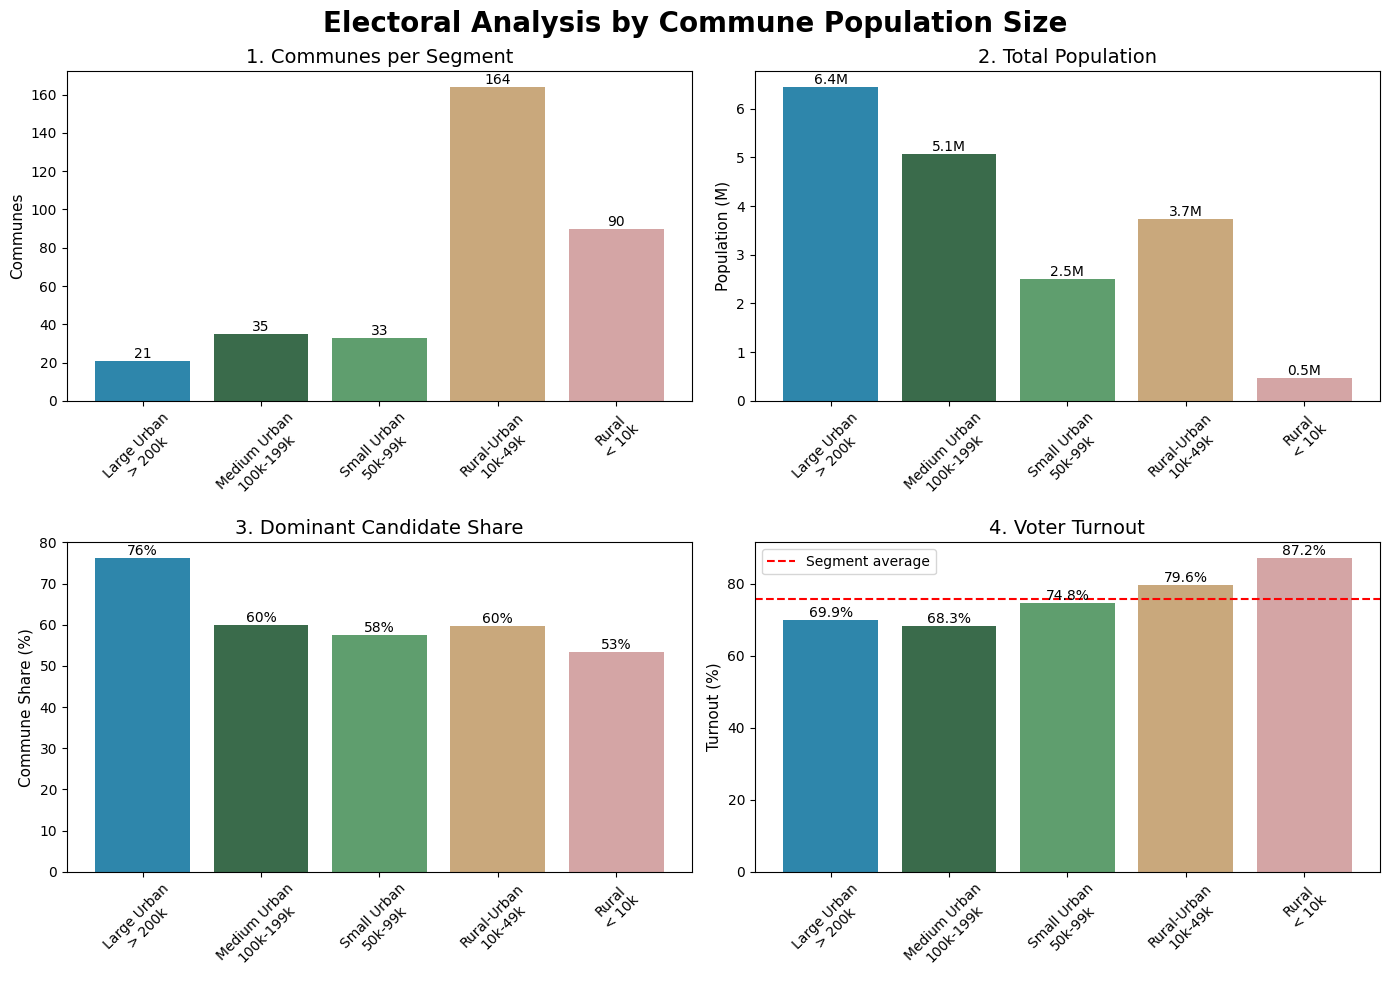

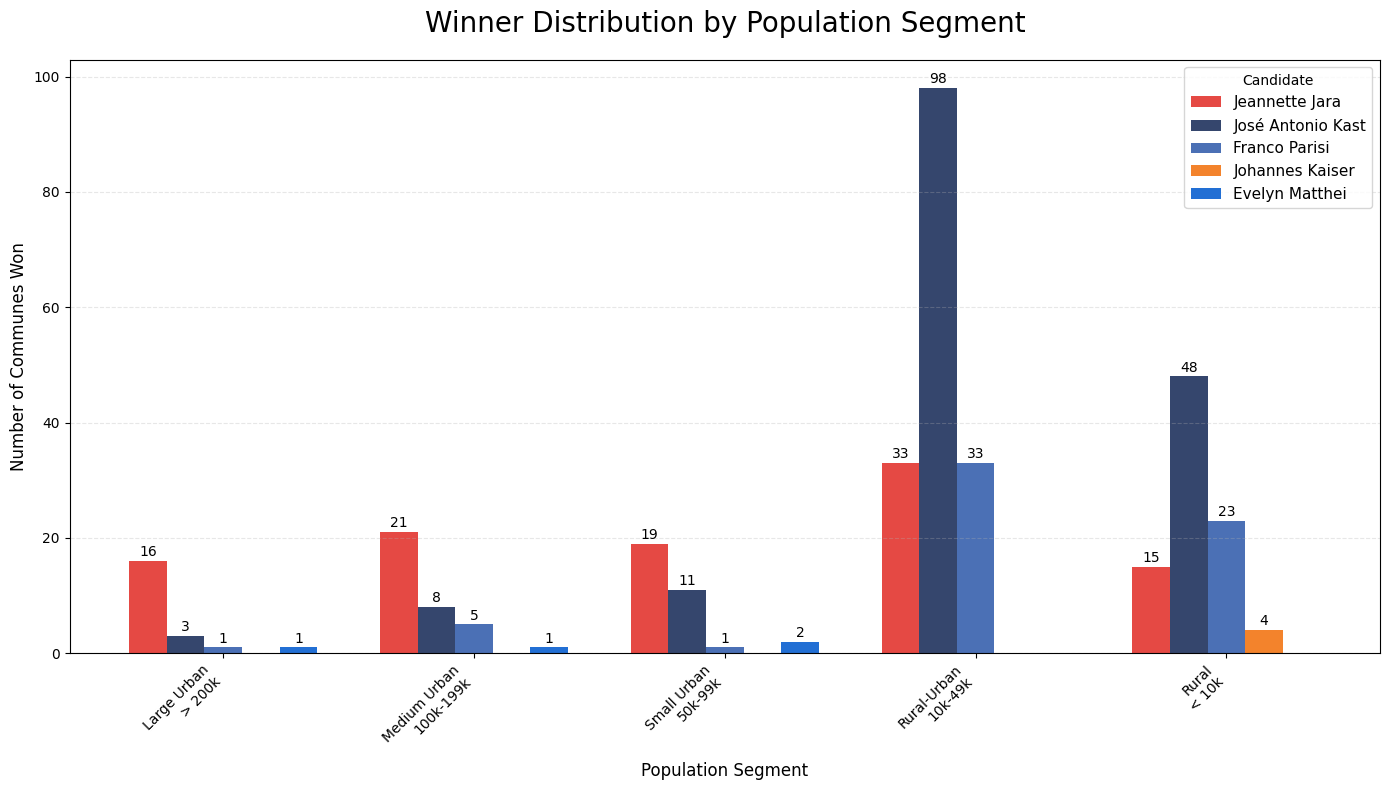

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# POPULATION SEGMENTATION OVERVIEW
# ============================================================================

# Convert columns to numeric types
for col in pct_cols:
    df_merged[col] = df_merged[col].astype(float)
df_merged['population'] = df_merged['population'].astype(int)

# Determine winner for each commune
df_merged['winner'] = (
    df_merged[pct_cols]
    .idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(CANDIDATE_NAMES)
)

# Define population segments
SEGMENTS = [
    {'name': 'Large Urban\n> 200k',     'min': 200_001, 'max': float('inf'), 'color': '#2E86AB'},
    {'name': 'Medium Urban\n100k-199k', 'min': 100_000, 'max': 199_999,      'color': '#3A6B4B'},
    {'name': 'Small Urban\n50k-99k',    'min':  50_000, 'max':  99_999,      'color': '#5F9E6E'},
    {'name': 'Rural-Urban\n10k-49k',    'min':  10_000, 'max':  49_999,      'color': '#C9A87C'},
    {'name': 'Rural\n< 10k',            'min':       0, 'max':   9_999,      'color': '#D4A5A5'},
]

def assign_segment(pop: int) -> str:
    """Assign population segment based on commune size."""
    if pop > 200_000:  return 'Large Urban\n> 200k'
    if pop >= 100_000: return 'Medium Urban\n100k-199k'
    if pop >= 50_000:  return 'Small Urban\n50k-99k'
    if pop >= 10_000:  return 'Rural-Urban\n10k-49k'
    return 'Rural\n< 10k'

df_merged['segment'] = df_merged['population'].apply(assign_segment)

# Calculate statistics per segment
seg_stats = []
for seg in SEGMENTS:
    df_seg = df_merged[df_merged['segment'] == seg['name']]
    n_comm = len(df_seg)
    if n_comm == 0:
        continue
    top_winner = df_seg['winner'].value_counts().index[0]
    top_pct = df_seg['winner'].value_counts().iloc[0] / n_comm * 100
    seg_stats.append({
        'segment':        seg['name'],
        'total_communes': n_comm,
        'total_pop':      df_seg['population'].sum(),
        'top_winner':     top_winner,
        'top_winner_pct': top_pct,
        'turnout':        df_seg['casted_votes'].sum() / df_seg['population'].sum() * 100,
    })
df_seg_stats = pd.DataFrame(seg_stats)

# Print summary table
print('POPULATION SEGMENTATION ANALYSIS')
display(df_seg_stats.round(2))

# ============================================================================
# CHART 1: OVERVIEW METRICS PER SEGMENT (2x2 GRID)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Electoral Analysis by Commune Population Size', fontsize=20, fontweight='bold')

seg_names = df_seg_stats['segment'].tolist()
seg_colors = [s['color'] for s in SEGMENTS if s['name'] in seg_names]

def labeled_bar(ax, labels, values, ylabel, title, fmt='{:.0f}'):
    """Helper to create labeled bar charts."""
    bars = ax.bar(labels, values, color=seg_colors)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt.format(v), ha='center', va='bottom', fontsize=10)

labeled_bar(axes[0, 0], seg_names, df_seg_stats['total_communes'], 'Communes', '1. Communes per Segment')
labeled_bar(axes[0, 1], seg_names, df_seg_stats['total_pop'] / 1e6,  'Population (M)', '2. Total Population', fmt='{:.1f}M')
labeled_bar(axes[1, 0], seg_names, df_seg_stats['top_winner_pct'],  'Commune Share (%)', '3. Dominant Candidate Share', fmt='{:.0f}%')
labeled_bar(axes[1, 1], seg_names, df_seg_stats['turnout'],         'Turnout (%)', '4. Voter Turnout', fmt='{:.1f}%')

# Add average line to turnout chart
axes[1, 1].axhline(df_seg_stats['turnout'].mean(), color='red', linestyle='--', linewidth=1.5, label='Segment average')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ============================================================================
# CHART 2: WINNER DISTRIBUTION BY SEGMENT (GROUPED BAR CHART)
# ============================================================================

fig2, ax = plt.subplots(figsize=(14, 8))

# Define candidates and their colors
all_winners = ['Jeannette Jara', 'José Antonio Kast', 'Franco Parisi', 'Johannes Kaiser', 'Evelyn Matthei']
winner_colors = {
    'Jeannette Jara': '#E54944',
    'José Antonio Kast': '#35466D',
    'Franco Parisi': '#4B70B5',
    'Johannes Kaiser': '#F3832C',
    'Evelyn Matthei': '#226FD4'
}

# Prepare data matrix: winners x segments
winner_counts = {}
for winner in all_winners:
    counts = []
    for seg in seg_names:
        df_seg = df_merged[df_merged['segment'] == seg]
        count = len(df_seg[df_seg['winner'] == winner])
        counts.append(count)
    winner_counts[winner] = counts

# Set up bar positions
x = np.arange(len(seg_names))
width = 0.15
offsets = np.linspace(-0.3, 0.3, len(all_winners))

# Create grouped bars
for i, winner in enumerate(all_winners):
    bars = ax.bar(x + offsets[i], winner_counts[winner], width, 
                  label=winner, color=winner_colors.get(winner, '#D3D3D3'))
    
    # Add value labels on top of bars
    for bar, val in zip(bars, winner_counts[winner]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(val), ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Population Segment', fontsize=12)
ax.set_ylabel('Number of Communes Won', fontsize=12)
ax.set_title('Winner Distribution by Population Segment', fontsize=20, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(seg_names, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=11, title='Candidate')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

#### Conclusión: Dos Chiles, Tres Territorios

##### El Patrón General

| Tamaño de Comuna              | Candidato Dominante   | % Población Controlada | Característica Central |
| ----------------------------- | --------------------- | ---------------------- | ---------------------- |
| Grandes (> 200.000 hab.)      | **Jeannette Jara**    | **76,9%**              | Metrópolis densas      |
| Medianos (100-199k)           | **Jeannette Jara**    | 59,5%                  | Ciudades intermedias   |
| Pequeños (50-99k)             | **Jeannette Jara**    | 61,5%                  | Ciudades pequeñas      |
| Rural-Urbano (10-49k)         | **José Antonio Kast** | **57,9%**              | Comunas semi-rurales   |
| Muy Pequeñas / Rurales (<10k) | **José Antonio Kast** | **~60%**               | Chile rural profundo   |

**Jara fue la candidata indiscutida del Chile urbano.** Su fortaleza en las ciudades grandes le permitió ganar la primera vuelta a pesar de tener una cobertura territorial mucho menor. El 76,9% de la población de las ciudades más grandes del país —más de 3,46 millones de personas— votó en comunas que eligieron a Jara como primera fuerza. Esa concentración de votos en pocos territorios de alta densidad explica la paradoja central del resultado: menos comunas, más votos.

**Kast fue el referente del Chile rural y provincial.** Su dominio crece de forma monótona a medida que disminuye el tamaño comunal. En el Chile de menos de 50.000 habitantes —que engloba la mayoría del territorio geográfico del país, aunque no la mayoría de su población— Kast es la primera fuerza con diferencias contundentes.

#### El Tercer Territorio: Parisi y el Norte Antisistema

Parisi representa un caso distinto a la gradiente urbano-rural: su dominio en el Norte no sigue el patrón de tamaño, sino el de territorio con características específicas (minería, frontera, crisis migratoria). En comunas grandes del Norte (Antofagasta) y en comunas muy pequeñas (Ollagüe, Colchane), Parisi gana con intensidades similares, lo que confirma que su voto responde a un eje temático —el descontento norteño— antes que a un eje demográfico.

#### Punto de Inflexión y Segunda Vuelta

El punto de quiebre demográfico en torno a las **50.000 personas** es uno de los hallazgos más precisos del análisis. Por encima de ese umbral, Jara es la primera fuerza sistemática; por debajo, Kast domina con claridad. Esta frontera funcional implica que en la segunda vuelta, la clave estaba en las comunas medianas y pequeñas de las regiones bisagra: son los territorios donde ninguno de los dos finalistas tenía garantizado su dominio y donde la transferencia del voto de Parisi, Kaiser y Matthei era más incierta y potencialmente decisiva.

## 10. Ganadores por Comuna
### 10.1. Mapa Nacional de Ganadores por Comuna

/tmp/ipykernel_35345/1954305096.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.94])


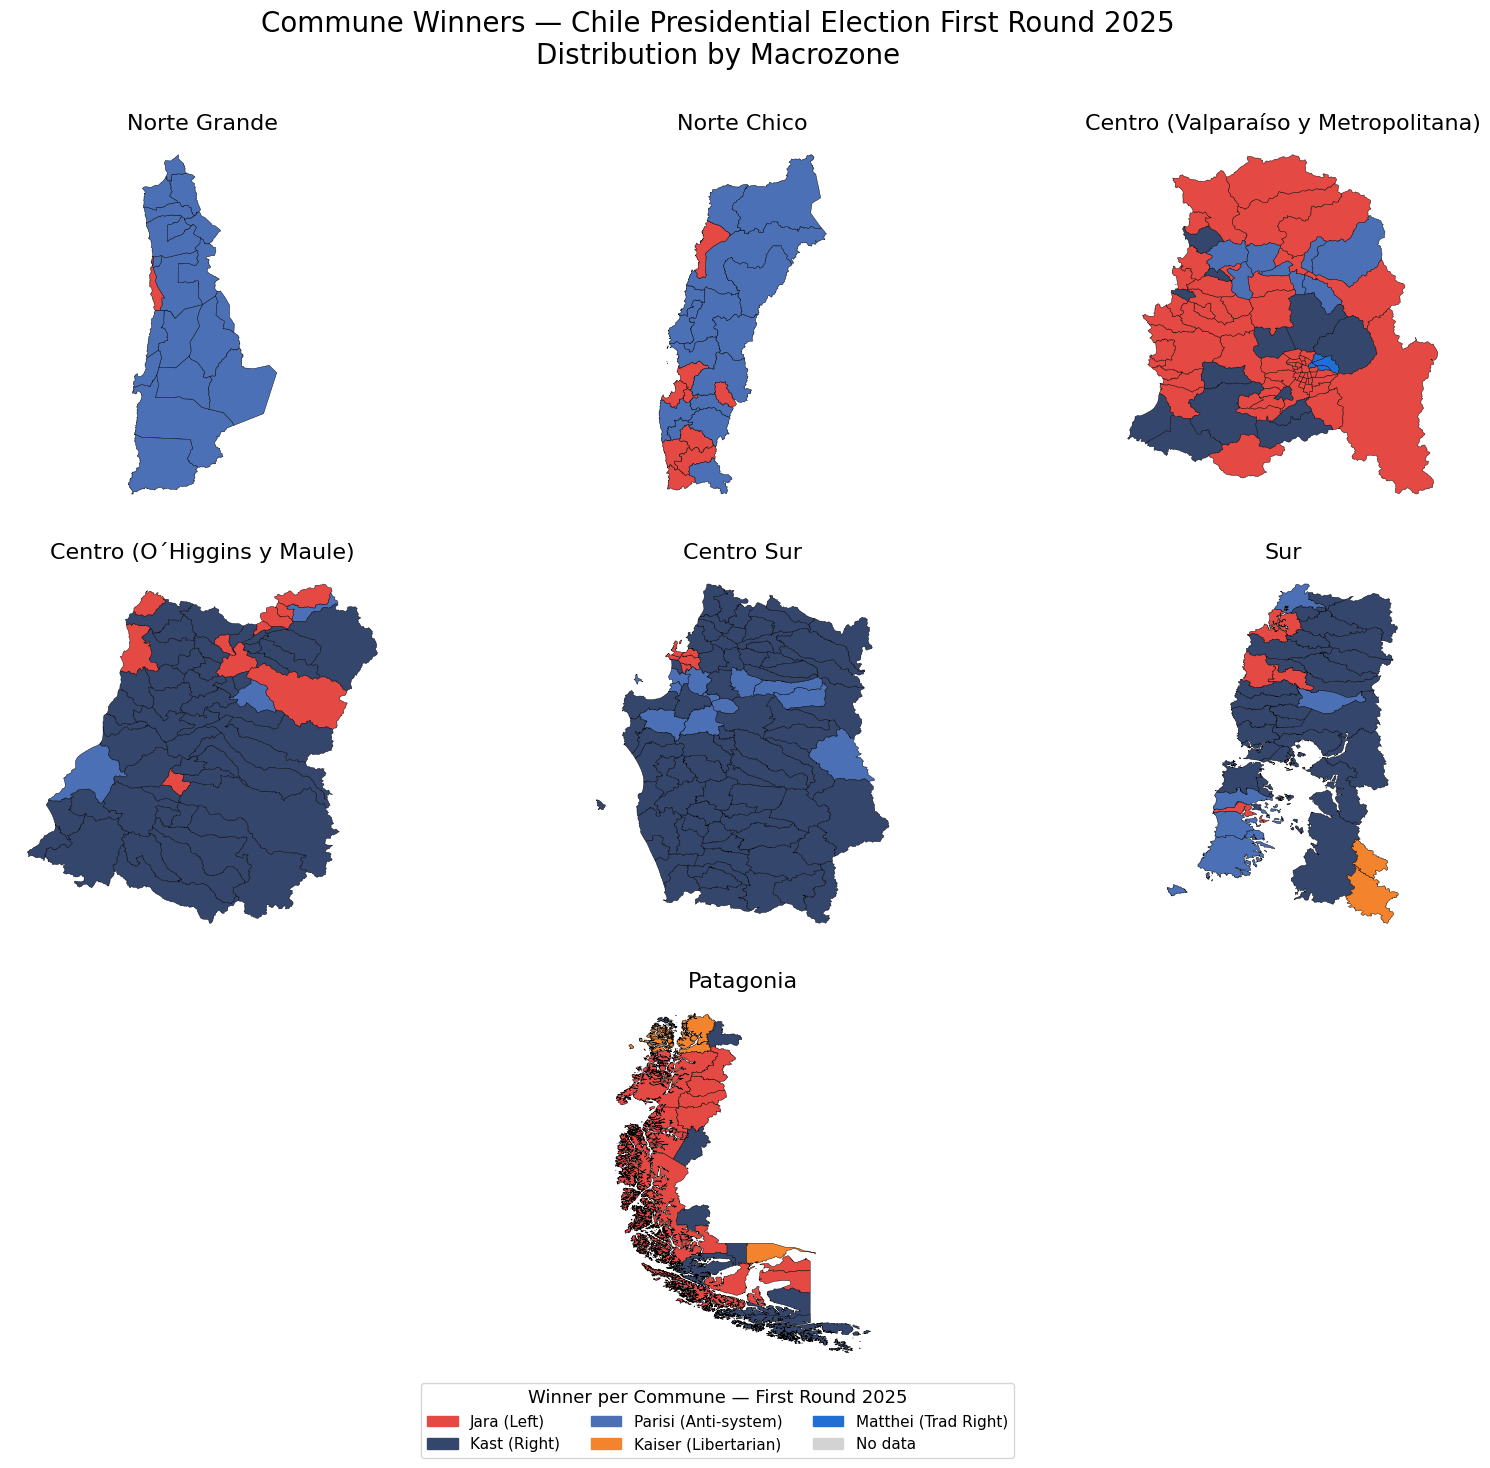

In [34]:
# ============================================================================
# COMMUNE-LEVEL WINNER MAP — FIRST ROUND 2025
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import geopandas as gpd
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------------------
# 1. CANDIDATE COLOR PALETTE (fixed colors, no gradients)
# ---------------------------------------------------------------------------
CANDIDATE_COLORS = {
    'Jara (Left)':              '#E54944',
    'Kast (Right)':             '#35466D',
    'Parisi (Anti-system)':     '#4B70B5',
    'Kaiser (Libertarian)':     '#F3832C',
    'Matthei (Trad Right)':     '#226FD4',
    'Mayne-Nicholls (Indep)':   '#BED8DF',
    'Enriquez-Ominami (Left)':  '#DD2883',
    'Artes (Far Left)':         '#CA1C1F',
    'No data':                  '#D3D3D3',
}

WINNER_MAP_2025 = {
    'jara':    'Jara (Left)',
    'kast':    'Kast (Right)',
    'parisi':  'Parisi (Anti-system)',
    'kaiser':  'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)',
    'mayne_nicholls':   'Mayne-Nicholls (Indep)',
    'enriquez_ominami': 'Enriquez-Ominami (Left)',
    'artes':   'Artes (Far Left)',
}

def assign_winner_color(row):
    """Return the hex color associated with the 2025 commune winner."""
    winner = row.get('winner_2025')
    if pd.isna(winner):
        return CANDIDATE_COLORS['No data']
    return CANDIDATE_COLORS.get(winner, CANDIDATE_COLORS['No data'])

# ---------------------------------------------------------------------------
# 2. DERIVE 2025 WINNER PER COMMUNE FROM RAW VOTE SHARES
# ---------------------------------------------------------------------------
pct_cols_all = [
    'jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct',
    'matthei_pct', 'mayne_nicholls_pct', 'enriquez_ominami_pct', 'artes_pct',
]

df_votes_map = df_votes.copy()
for col in pct_cols_all:
    df_votes_map[col] = pd.to_numeric(df_votes_map[col], errors='coerce').fillna(0)

df_votes_map['winner_2025_key'] = df_votes_map[pct_cols_all].idxmax(axis=1).str.replace('_pct', '', regex=False)
df_votes_map['winner_2025'] = df_votes_map['winner_2025_key'].map(WINNER_MAP_2025)

# ---------------------------------------------------------------------------
# 3. NAME NORMALIZATION FOR SPATIAL JOIN
# ---------------------------------------------------------------------------
communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
df_votes_map['commune_norm']  = df_votes_map['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# 4. SPATIAL JOIN: MERGE GEOMETRIES WITH WINNER DATA
# ---------------------------------------------------------------------------
map_data = communes_map.merge(
    df_votes_map[['commune_norm', 'winner_2025']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

map_data['color'] = map_data.apply(assign_winner_color, axis=1).fillna(CANDIDATE_COLORS['No data'])

# Exclude island communes (unreachable territory distorts layout)
map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

unmatched = map_data[map_data['winner_2025'].isna()]['NOM_COM'].tolist()
if unmatched:
    print(f"Communes with no match ({len(unmatched)}): {unmatched[:10]}")

# ---------------------------------------------------------------------------
# 5. MACROZONE ASSIGNMENT (7 ZONES)
# ---------------------------------------------------------------------------
MACROZONE_MAP = {
    15: 'Norte Grande',
    1:  'Norte Grande',
    2:  'Norte Grande',
    3:  'Norte Chico',
    4:  'Norte Chico',
    5:  'Centro (Valparaíso y Metropolitana)',
    13: 'Centro (Valparaíso y Metropolitana)',
    6:  'Centro (O\u00b4Higgins y Maule)',
    7:  'Centro (O\u00b4Higgins y Maule)',
    16: 'Centro Sur',
    8:  'Centro Sur',
    9:  'Centro Sur',
    14: 'Sur',
    10: 'Sur',
    11: 'Patagonia',
    12: 'Patagonia',
}

map_data['macrozone'] = map_data['REGION_NUM'].map(MACROZONE_MAP)

# ---------------------------------------------------------------------------
# 6. 3×3 GRID LAYOUT
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
gs  = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 1])

zone_axes = [
    (ax1, 'Norte Grande'),
    (ax2, 'Norte Chico'),
    (ax3, 'Centro (Valparaíso y Metropolitana)'),
    (ax4, 'Centro (O\u00b4Higgins y Maule)'),
    (ax5, 'Centro Sur'),
    (ax6, 'Sur'),
    (ax7, 'Patagonia'),
]

for ax, macro in zone_axes:
    macro_data = map_data[map_data['macrozone'] == macro].copy()
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(macro, fontsize=14)
        ax.set_axis_off()
        continue

    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
    ax.set_title(macro, fontsize=16)
    ax.set_axis_off()
    ax.set_aspect('equal')

    if macro == 'Patagonia':
        bounds   = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

# Hide unused grid cells
ax_empty1 = fig.add_subplot(gs[2, 0])
ax_empty2 = fig.add_subplot(gs[2, 2])
ax_empty1.set_visible(False)
ax_empty2.set_visible(False)

fig.suptitle(
    'Commune Winners — Chile Presidential Election First Round 2025\nDistribution by Macrozone',
    fontsize=20, y=0.96,
)

# ---------------------------------------------------------------------------
# 7. LEGEND (only candidates with at least one commune win)
# ---------------------------------------------------------------------------
present_winners = map_data['winner_2025'].dropna().unique()
legend_entries  = [
    (label, CANDIDATE_COLORS[label])
    for label in [
        'Jara (Left)', 'Kast (Right)', 'Parisi (Anti-system)',
        'Kaiser (Libertarian)', 'Matthei (Trad Right)',
    ]
    if label in present_winners
]
legend_entries.append(('No data', CANDIDATE_COLORS['No data']))

legend_handles = [mpatches.Patch(color=color, label=label) for label, color in legend_entries]

fig.legend(
    handles=legend_handles, loc='lower center', ncol=3, fontsize=11,
    title='Winner per Commune — First Round 2025', title_fontsize=13,
    bbox_to_anchor=(0.5, 0.05),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.94])
plt.show()


### 10.2. Áreas Metropolitanas y Conurbaciones

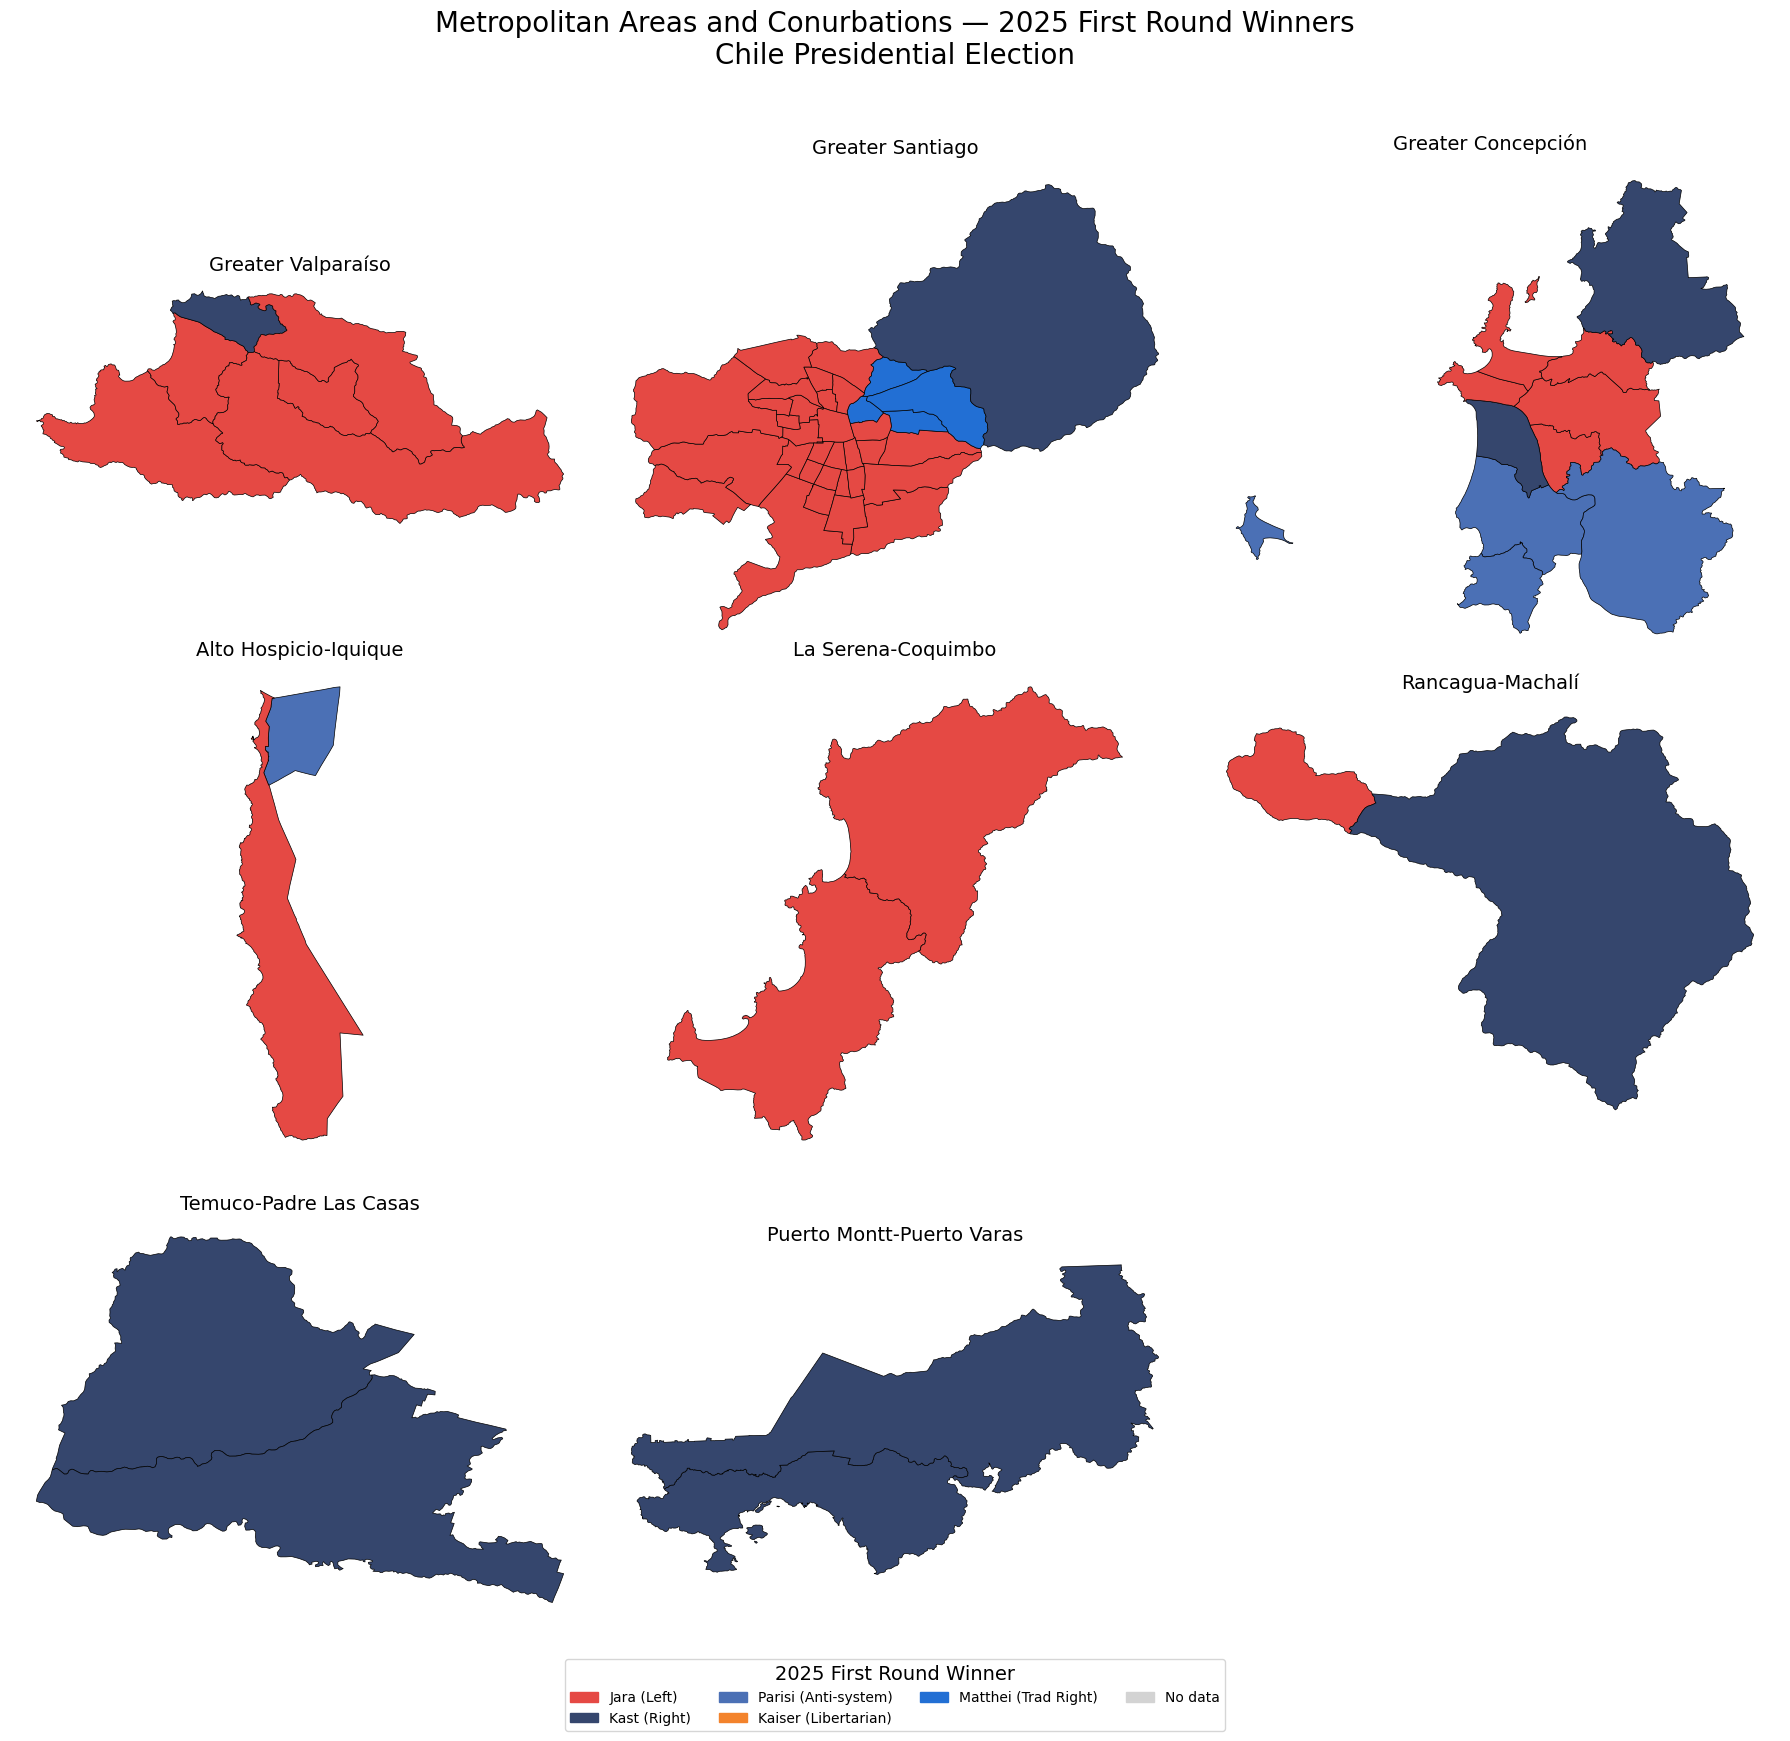

In [35]:
# ============================================================================
# METROPOLITAN AREAS AND CONURBATIONS — FIRST ROUND 2025 WINNERS
# ============================================================================

# ---------------------------------------------------------------------------
# 1. URBAN AGGLOMERATION DEFINITIONS
# Raw display names (accents preserved) — matching is done via normalized
# keys to avoid encoding divergence with the GeoJSON source.
# ---------------------------------------------------------------------------

# Primary metropolitan areas (by population)
GREATER_SANTIAGO = [
    "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
    "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
    "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
    "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
    "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
    "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
    "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
]

GREATER_VALPARAISO = [
    "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
]

GREATER_CONCEPCION = [
    "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
    "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
]

# Secondary conurbations (north to south)
ALTO_HOSPICIO_IQUIQUE  = ["Alto Hospicio", "Iquique"]
LA_SERENA_COQUIMBO     = ["La Serena", "Coquimbo"]
RANCAGUA_MACHALI       = ["Rancagua", "Machalí"]
TEMUCO_METRO           = ["Temuco", "Padre Las Casas"]
PUERTO_MONTT_VARAS     = ["Puerto Montt", "Puerto Varas"]

# ---------------------------------------------------------------------------
# 2. GRID LAYOUT CONFIGURATION
# Tuple order: (grid_position, commune_list, display_title)
# ---------------------------------------------------------------------------
FACET_CONFIG = [
    # Row 0 — primary metropolitan areas
    ((0, 0), GREATER_VALPARAISO, 'Greater Valparaíso'),
    ((0, 1), GREATER_SANTIAGO,   'Greater Santiago'),
    ((0, 2), GREATER_CONCEPCION, 'Greater Concepción'),
    # Row 1 — northern and central conurbations
    ((1, 0), ALTO_HOSPICIO_IQUIQUE, 'Alto Hospicio-Iquique'),
    ((1, 1), LA_SERENA_COQUIMBO,    'La Serena-Coquimbo'),
    ((1, 2), RANCAGUA_MACHALI,      'Rancagua-Machalí'),
    # Row 2 — southern conurbations; cell (2,2) intentionally empty
    ((2, 0), TEMUCO_METRO,      'Temuco-Padre Las Casas'),
    ((2, 1), PUERTO_MONTT_VARAS, 'Puerto Montt-Puerto Varas'),
]

# Pre-compute normalized key sets for each area to avoid per-row normalization
# inside the render loop; NOM_COM_NORM already exists on map_data from cell #88.
area_norm_keys = {
    title: {normalize_commune_name(c) for c in commune_list}
    for _, commune_list, title in FACET_CONFIG
}

# ---------------------------------------------------------------------------
# 3. RENDER 3×3 FACET GRID
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle(
    'Metropolitan Areas and Conurbations — 2025 First Round Winners\n'
    'Chile Presidential Election',
    fontsize=20, y=0.98,
)

for (row, col), commune_list, title in FACET_CONFIG:
    ax       = axes[row, col]
    norm_set = area_norm_keys[title]

    # Filter via normalized key (encoding-safe, consistent with the spatial join)
    area_data = map_data[map_data['NOM_COM_NORM'].isin(norm_set)].copy()

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{title}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=14)
        ax.set_axis_off()
        continue

    # winner_2025 already mapped to display labels in cell #88;
    # re-map to color using the same palette defined there.
    area_data['color'] = area_data['winner_2025'].map(CANDIDATE_COLORS).fillna(CANDIDATE_COLORS['No data'])

    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hide the unused bottom-right cell
axes[2, 2].set_visible(False)

# ---------------------------------------------------------------------------
# 4. SHARED LEGEND
# ---------------------------------------------------------------------------
present_candidates = map_data['winner_2025'].dropna().unique()

legend_entries = [
    (label, CANDIDATE_COLORS[label])
    for label in [
        'Jara (Left)', 'Kast (Right)', 'Parisi (Anti-system)',
        'Kaiser (Libertarian)', 'Matthei (Trad Right)',
    ]
    if label in present_candidates
]
legend_entries.append(('No data', CANDIDATE_COLORS['No data']))

legend_handles = [mpatches.Patch(color=color, label=label) for label, color in legend_entries]

fig.legend(
    handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
    title='2025 First Round Winner', title_fontsize=14,
    bbox_to_anchor=(0.5, 0.02),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


## 11. Comunas Recuperables (Margen < 1.000 Votos)

Más allá de las comunas ganadas con holgura, un indicador estratégico de primera importancia son las **comunas recuperables**: aquellas donde la diferencia entre el primero y el segundo lugar fue inferior a 1.000 votos. Este umbral —elegido por su relevancia práctica en términos de movilización— delimita los territorios donde un esfuerzo diferencial de participación o una transferencia de votos modesta puede cambiar el resultado.

Esta sección analiza las 81 comunas recuperables de Jara y las 53 de Kast, identificando los patrones geográficos que revelan las vulnerabilidades de cada candidato y las implicancias de cara a la segunda vuelta.

In [36]:
# ============================================================================
# RECOVERABLE COMMUNE ANALYSIS - JARA VS KAST
# ============================================================================

# Derive absolute vote counts from percentages and valid votes
df_votes['valid_votes']     = df_votes['casted_votes'] - df_votes['blank_votes'] - df_votes['null_votes']
df_votes['jara_abs_votes']  = (df_votes['jara_pct']  / 100) * df_votes['valid_votes']
df_votes['kast_abs_votes']  = (df_votes['kast_pct']  / 100) * df_votes['valid_votes']
df_votes['vote_difference'] = np.abs(df_votes['jara_abs_votes'] - df_votes['kast_abs_votes'])

df_close = df_votes[df_votes['vote_difference'] < 1000].copy()
df_close['winner']       = np.where(df_close['jara_abs_votes'] > df_close['kast_abs_votes'],
                                     'Jeannette Jara', 'José Antonio Kast')
df_close['loser']        = np.where(df_close['winner'] == 'Jeannette Jara',
                                     'José Antonio Kast', 'Jeannette Jara')
df_close['votes_needed'] = df_close['vote_difference']

# Summary per candidate
summary_rows = []
for candidate in ['Jeannette Jara', 'José Antonio Kast']:
    subset      = df_close[df_close['loser'] == candidate]
    if len(subset) == 0:
        continue
    total_votes = int(subset['votes_needed'].sum())
    difficulty  = (
        'Minor challenge'       if total_votes < 5_000  else
        'Moderate challenge'    if total_votes < 20_000 else
        'Significant challenge'
    )
    summary_rows.append({
        'candidate':             candidate,
        'recoverable_communes':  len(subset),
        'total_votes_needed':    total_votes,
        'avg_votes_needed':      round(subset['votes_needed'].mean(), 0),
        'difficulty_level':      difficulty,
    })

print('RECOVERABLE COMMUNES (MARGIN < 1,000 VOTES)')
print('='*80)
display(pd.DataFrame(summary_rows))

# Detail by candidate and macrozone (north to south)
macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone', 'macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_close['macrozone'] = df_close['region'].map(macrozone_map)

detail_cols = ['commune', 'region', 'macrozone',
               'jara_abs_votes', 'kast_abs_votes', 'vote_difference', 'votes_needed']

for candidate in ['Jeannette Jara', 'José Antonio Kast']:
    print('\n' + '='*80)
    print(f'RECOVERABLE FOR {candidate.upper()} (lost by fewer than 1,000 votes)')
    print('='*80)
    df_cand = df_close[df_close['loser'] == candidate].copy()
    if len(df_cand) == 0:
        print('No recoverable communes.')
        continue
    for zone in macrozone_order:
        df_zone = df_cand[df_cand['macrozone'] == zone]
        if len(df_zone) > 0:
            print(f'\n{zone.upper()} ({len(df_zone)} communes)')
            print('-'*80)
            df_disp = df_zone[detail_cols].copy()
            for col in ['jara_abs_votes','kast_abs_votes','vote_difference','votes_needed']:
                df_disp[col] = df_disp[col].round(0).astype(int)
            display(df_disp)

RECOVERABLE COMMUNES (MARGIN < 1,000 VOTES)


,candidate,recoverable_communes,total_votes_needed,avg_votes_needed,difficulty_level
0,Jeannette Jara,81,33999,420.0,Significant challenge
1,José Antonio Kast,53,17720,334.0,Moderate challenge



RECOVERABLE FOR JEANNETTE JARA (lost by fewer than 1,000 votes)

NORTE GRANDE (9 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
1,Calama,Antofagasta,Norte Grande,19492,20107,615,615
4,Ollague,Antofagasta,Norte Grande,90,117,27,27
10,Camarones,Arica y Parinacota,Norte Grande,281,310,29,29
11,General Lagos,Arica y Parinacota,Norte Grande,47,177,130,130
12,Putre,Arica y Parinacota,Norte Grande,332,591,259,259
281,Camiña,Tarapacá,Norte Grande,122,608,486,486
282,Colchane,Tarapacá,Norte Grande,25,387,362,362
283,Huara,Tarapacá,Norte Grande,447,685,238,238
286,Pozo Almonte,Tarapacá,Norte Grande,1744,1962,218,218



NORTE CHICO (1 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
47,Lota,Biobío,Centro Sur,9499,8592,907,907
55,San Rosendo,Biobío,Centro Sur,853,836,17,17



SUR (7 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
147,Castro,Los Lagos,Sur,8860,8209,651,651
159,Osorno,Los Lagos,Sur,30047,29841,206,206
160,Palena,Los Lagos,Sur,353,338,15,15
162,Puerto Octay,Los Lagos,Sur,1931,1761,170,170
170,Quinchao,Los Lagos,Sur,1549,1462,87,87
172,San Juan de la Costa,Los Lagos,Sur,1795,1695,100,100
175,Corral,Los Ríos,Sur,1253,1057,196,196



PATAGONIA (9 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
22,Aysen,Aysén,Patagonia,4545,3633,912,912
23,Chile Chico,Aysén,Patagonia,1232,747,485,485
25,Cochrane,Aysén,Patagonia,643,560,83,83
30,Rio Ibañez,Aysén,Patagonia,578,572,6,6
31,Tortel,Aysén,Patagonia,120,71,49,49
190,Natales,Magallanes,Patagonia,4939,4096,843,843
191,Porvenir,Magallanes,Patagonia,1209,1013,196,196
192,Primavera,Magallanes,Patagonia,119,81,38,38
195,San Gregorio,Magallanes,Patagonia,97,89,8,8


### Caso 1: Jeannette Jara — Las 81 comunas recuperables

**Patrón estructural:** Las comunas recuperables de Jara se concentran en zonas de transición y semi-rurales —no en las grandes ciudades, donde ganó con holgura— lo que indica que su debilidad estructural está en el **Chile intermedio**: comunas de tamaño mediano y pequeño donde el gradiente urbano-rural opera contra ella.

- **Norte Grande (9 comunas):** Calama, Ollagüe, Camarones, General Lagos y otras comunas norteñas donde Jara quedó muy cerca de Parisi o Kast. Su presencia en el Norte es fundamentalmente como segunda o tercera fuerza, no como contendiente seria.
- **Centro (O'Higgins, Maule, Valparaíso):** Gran concentración de comunas recuperables en estas regiones bisagra. Comunas como Rengo, Codegua, Coinco en O'Higgins, o varias comunas rurales del Maule, representan territorios donde Jara fue segunda fuerza por márgenes estrechos pero en comunas con densidad poblacional baja.
- **Centro Sur:** Alta presencia en Biobío y La Araucanía, regiones donde el dominio de Kast es claro en el agregado, pero donde algunas comunas más urbanizadas o con economías mixtas dejaron márgenes estrechos.

**Característica común de las comunas recuperables de Jara:** Son mayoritariamente comunas de entre 5.000 y 50.000 habitantes, de perfil semi-rural o de transición. En ellas, Jara fue segunda fuerza perdiendo por márgenes estrechos en territorios donde el voto kástero tiene raíces culturales más profundas. Recuperarlas exigiría un desplazamiento del votante medio de esas comunas que va más allá de la simple movilización: requeriría un cambio en la percepción sobre los temas de orden y seguridad.

### Caso 2: José Antonio Kast — Las 53 comunas recuperables

Las comunas recuperables de Kast presentan un patrón geográficamente más diversificado, con presencia en todas las macrozonas, lo que refleja su mayor cobertura territorial.

1. **Norte Grande y Norte Chico (13 comunas):** Kast compitió de cerca con Parisi en comunas mineras y rurales del Norte (María Elena, Mejillones, Taltal, Pica, Freirina). En este caso, la recuperación exigiría desplazar votos de Parisi en su bastión más sólido, lo que es estructuralmente difícil.

2. **Centro (22 comunas):** La mayor concentración. Muchas comunas semi-rurales de O'Higgins, Maule y Valparaíso donde Kast estuvo cerca de Jara. Estos son los territorios más estratégicamente relevantes para la segunda vuelta: son recuperables y están en regiones bisagra de alta importancia.

3. **Centro Sur y Sur (9 comunas):** Comunas donde Jara, sorprendentemente, logró acercarse en territorios que son base natural de Kast. Esto ocurrió principalmente en comunas con mayor presencia de trabajadores de industrias estatales o de servicios.

4. **Patagonia (9 comunas):** Alta densidad de comunas reñidas en Aysén y Magallanes, zona donde la competencia entre Jara y Kast es más equilibrada que en el resto del país, y donde Kaiser también juega un rol relevante.

**Patrón clave de las comunas recuperables de Kast:** Están más distribuidas geográficamente, concentradas en zonas de transición donde la competencia con Jara fue más reñida. Sus comunas recuperables en el Centro y Centro Sur son estratégicamente las más valiosas: están en regiones bisagra, tienen mayor tamaño relativo y la diferencia de movilización necesaria es menor en términos absolutos.

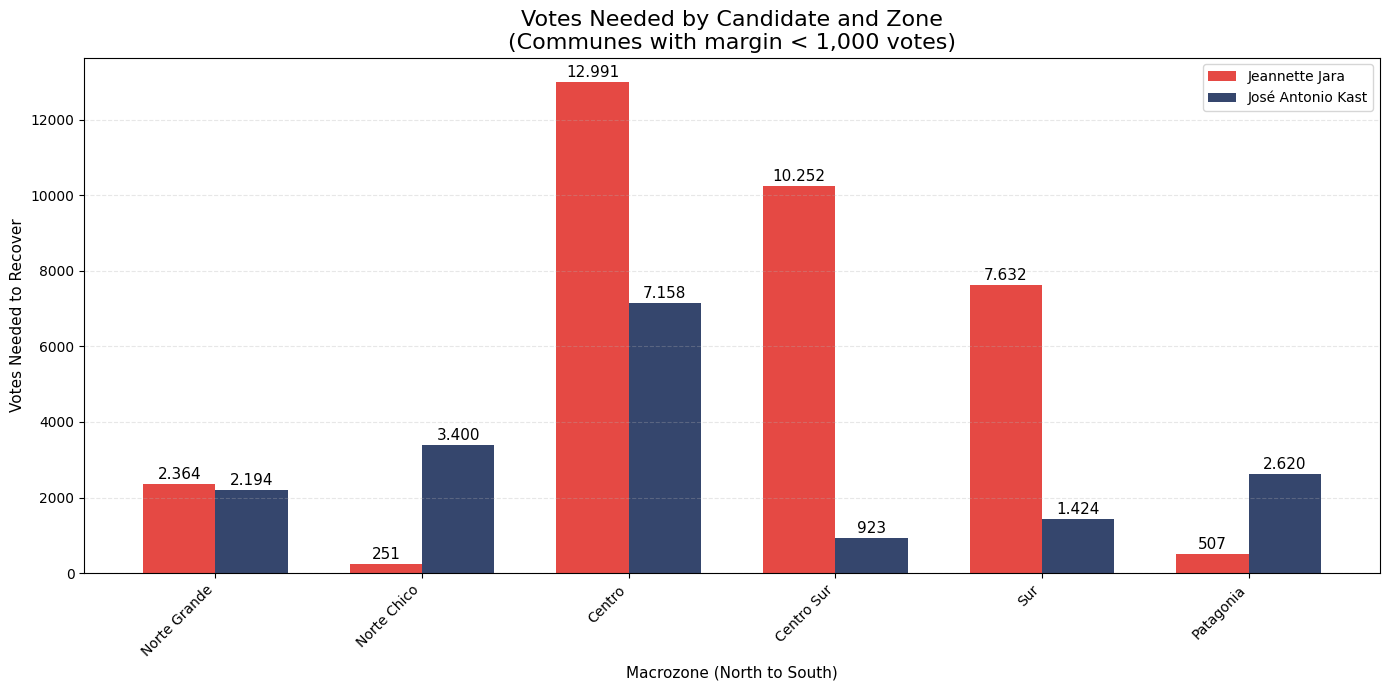

In [37]:
# ============================================================================
# RECOVERABLE COMMUNES - GROUPED BAR CHART (VOTES NEEDED BY ZONE)
# ============================================================================

zone_vote_rows = []
for candidate in ['Jeannette Jara', 'José Antonio Kast']:
    df_cand = df_close[df_close['loser'] == candidate]
    for zone in macrozone_order:
        df_zone = df_cand[df_cand['macrozone'] == zone]
        zone_vote_rows.append({
            'candidate':    candidate,
            'macrozone':    zone,
            'votes_needed': df_zone['votes_needed'].sum() if len(df_zone) > 0 else 0,
        })

df_zone_votes = pd.DataFrame(zone_vote_rows)

fig, ax = plt.subplots(figsize=(14, 7))
x     = np.arange(len(macrozone_order))
width = 0.35

votes_jara = [
    df_zone_votes[(df_zone_votes['candidate'] == 'Jeannette Jara') &
                  (df_zone_votes['macrozone'] == z)]['votes_needed'].values[0]
    for z in macrozone_order
]
votes_kast = [
    df_zone_votes[(df_zone_votes['candidate'] == 'José Antonio Kast') &
                  (df_zone_votes['macrozone'] == z)]['votes_needed'].values[0]
    for z in macrozone_order
]

bars1 = ax.bar(x - width/2, votes_jara, width, label='Jeannette Jara',   color='#E54944')
bars2 = ax.bar(x + width/2, votes_kast, width, label='José Antonio Kast', color='#35466D')

ax.set_xlabel('Macrozone (North to South)', fontsize=11)
ax.set_ylabel('Votes Needed to Recover', fontsize=11)
ax.set_title('Votes Needed by Candidate and Zone\n(Communes with margin < 1,000 votes)', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(macrozone_order, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bars_group in [bars1, bars2]:
    for bar in bars_group:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 50,
                    f'{int(h):,}'.replace(',','.'), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Este gráfico muestra el total de votos adicionales que Jara (rojo) y Kast (azul) hubieran necesitado para revertir todas las comunas que perdieron por menos de 1.000 votos en cada macrozona. Es un indicador de **eficiencia del esfuerzo de movilización**: cuántos votos cuesta cambiar el resultado en cada zona.

#### Lectura Estratégica del Gráfico

- **Jara** requería el mayor esfuerzo absoluto de movilización, especialmente en el **Centro** (12.991 votos) y **Centro Sur** (10.252 votos). Su desafío de movilización era costoso no solo en cantidad, sino en el tipo de votante que necesitaba convencer: electores de comunas semi-rurales con sensibilidades distintas a su base natural.

- **Kast** tenía un desafío más eficiente en términos de votos por comunas recuperadas. Su mayor necesidad se concentra en el **Centro** (7.158 votos), pero en el Centro Sur y Sur requería volúmenes muy bajos (923 y 1.424 respectivamente). Esto significa que en las regiones bisagra del sur, Kast tenía "victorias baratas" disponibles —pocas comunas que requieren pocos votos adicionales para cambiar de color.

**Conclusión:** El mapa de esfuerzo necesario favorecía estructuralmente a Kast de cara a la segunda vuelta. No solo porque necesitaba menos votos en términos absolutos para recuperar comunas, sino porque sus comunas recuperables estaban mejor distribuidas geográficamente, lo que facilita la movilización focalizada por región.

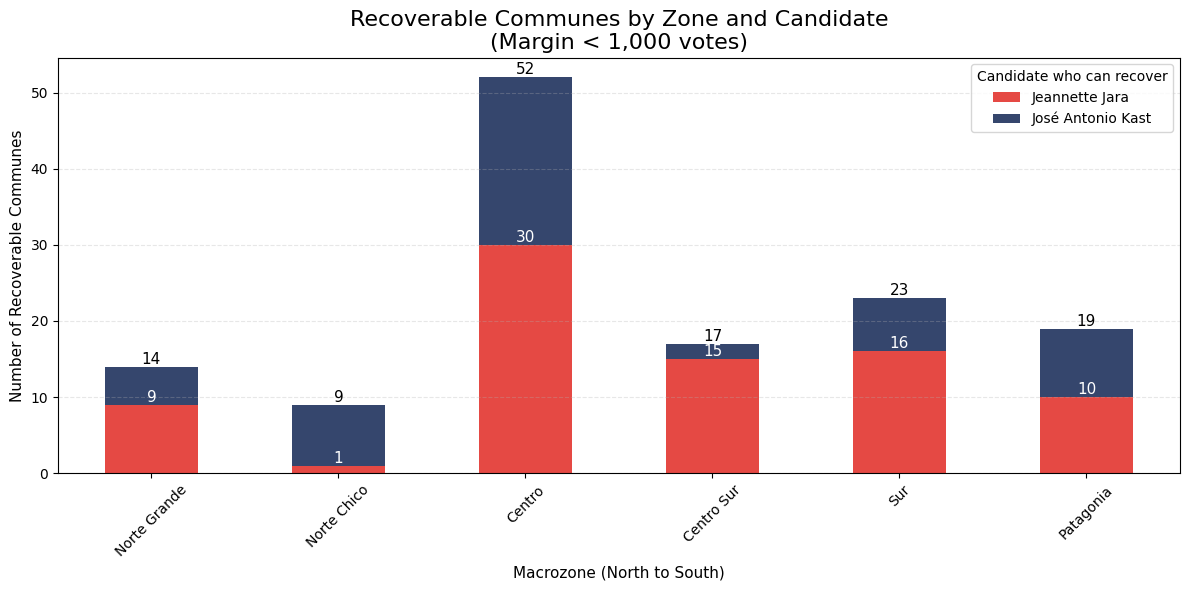

In [38]:
# ============================================================================
# RECOVERABLE COMMUNES - STACKED BAR CHART (COUNT BY ZONE)
# ============================================================================

zone_count_rows = []
for candidate in ['Jeannette Jara', 'José Antonio Kast']:
    df_cand = df_close[df_close['loser'] == candidate]
    for zone in macrozone_order:
        zone_count_rows.append({
            'candidate': candidate,
            'macrozone': zone,
            'communes':  len(df_cand[df_cand['macrozone'] == zone]),
        })

df_zone_counts = pd.DataFrame(zone_count_rows)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = (
    df_zone_counts
    .pivot(index='macrozone', columns='candidate', values='communes')
    .fillna(0)
    .reindex(macrozone_order)
)

cand_colors = {'Jeannette Jara': '#E54944', 'José Antonio Kast': '#35466D'}
pivot.plot(kind='bar', stacked=True, ax=ax,
           color=[cand_colors[c] for c in pivot.columns])

ax.set_xlabel('Macrozone (North to South)', fontsize=11)
ax.set_ylabel('Number of Recoverable Communes', fontsize=11)
ax.set_title('Recoverable Communes by Zone and Candidate\n(Margin < 1,000 votes)', fontsize=16)
ax.legend(title='Candidate who can recover', loc='upper right')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, linestyle='--')

text_colors = {'Jeannette Jara': 'white', 'José Antonio Kast': 'black'}
for i, container in enumerate(ax.containers):
    ax.bar_label(container, fmt='%d', fontsize=11, color=text_colors[pivot.columns[i]])

plt.tight_layout()
plt.show()

#### Distribución por Macrozona: Síntesis

- **Centro:** La zona más disputada del análisis (52 comunas recuperables en total). Jara tenía 30 oportunidades y Kast 22. La densidad de comunas reñidas en O'Higgins, Maule y Valparaíso confirma que estas regiones funcionaron como el campo de batalla real de la segunda vuelta.
- **Centro Sur y Sur:** Jara tenía más comunas recuperables en cantidad (15 + 16), pero Kast mostraba mayor solidez de base —necesitaba menos votos para retener las suyas— y sus comunas recuperables estaban en regiones donde el voto obligatorio había incorporado electores más afines a su mensaje.
- **Norte Grande y Norte Chico:** Jara y Kast tenían comunas recuperables, pero el control estructural de Parisi en esa zona hacía que las opciones reales de cambio fueran muy limitadas.
- **Patagonia:** Alta competitividad relativa (19 comunas recuperables), prácticamente equilibrada entre Jara y Kast, con Kaiser como tercera fuerza relevante que capturó parte del electorado de ambos.

**Síntesis estratégica final:**

Aunque Jeannette Jara ganó la primera vuelta por el peso demográfico de las grandes ciudades, el mapa de comunas recuperables muestra que **José Antonio Kast partía con una posición más ventajosa** para el balotaje: necesitaba menos votos para voltear resultados en zonas clave y tenía una base más consolidada en el sur y centro-sur. La geografía de la competitividad, más que los porcentajes nacionales, era el verdadero indicador de las fuerzas relativas de cara a la segunda vuelta.

## 12. Proyección Segunda Vuelta (Jara vs. Kast)

Este análisis proyecta los resultados posibles del balotaje entre **Jeannette Jara** y **José Antonio Kast**, aplicando supuestos de transferencia de voto para cada candidato eliminado. Se presentan cuatro escenarios que cubren el rango razonable de distribuciones del voto de Parisi —el factor de mayor incertidumbre— y se evalúa la robustez estructural de la ventaja de cada finalista bajo distintas condiciones.

El análisis se basa en patrones históricos de transferencia de voto en Chile, en el perfil ideológico de cada electorado y en el contexto político específico de noviembre de 2025.

### 12.1. Escenario Base — Transferencia Natural de Votos

| Candidato eliminado    | Votos    | Supuesto de transferencia                    | Fundamento                                                                 |
|------------------------|----------|----------------------------------------------|----------------------------------------------------------------------------|
| Johannes Kaiser        | 1.796.034 | 95% → Kast, 5% abstención                  | Alineación ideológica libertaria-derecha; abstención refleja diferencias programáticas. |
| Eduardo Artés          | 85.516    | 100% → Jara                                | Electorado de izquierda radical sin alternativa ideológica en el balotaje.  |
| Marco Enríquez-Ominami | 154.321   | 100% → Jara                                | Voto independiente de izquierda; rechazo a respaldar candidatura de derecha. |
| Evelyn Matthei         | 1.603.104 | 55% → Kast, 20% → Jara, 25% abstención    | La derecha tradicional se divide: mayoría a Kast, minoria a Jara (ex-Evópoli, RN moderado), alta abstención del sector desencantado. |
| Harold Mayne-Nicholls  | 162.366   | 40% → Jara, 25% → Kast, 35% abstención    | Voto independiente de perfil heterogéneo; alta abstención por desencanto con ambas opciones. |

El voto de Franco Parisi (2.550.770) **no se asigna en este escenario base**, reflejando la incertidumbre genuina sobre su transferencia. El escenario base evalúa la posición estructural de cada candidato antes de resolver la incógnita de Parisi.

In [39]:
# ============================================================================
# RUNOFF PROJECTION - BASELINE SCENARIO
# ============================================================================

# 1. National totals
total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# 2. First round votes (candidates only)
votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()

# 3. Baseline transfer scenario
# Kaiser (libertarian right) → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes (far left) → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO (independent left) → 100% Jara
votes_jara_proj += votes_meo

# Matthei (historical right) → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne-Nicholls (independent) → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# 4. Total valid votes in projection
total_valid_proj = votes_jara_proj + votes_kast_proj

# 5. Total abstention (excludes blank/null, already counted)
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne

# 6. Difference (positive = Jara leads, negative = Kast leads)
diff = votes_jara_proj - votes_kast_proj

# ============================================================================
# RESULTS
# ============================================================================

print("\n" + "="*70)
print("RUNOFF PROJECTION - BASELINE SCENARIO")
print("="*70)

print("\n📊 TOTAL CAST VOTES:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser ({votes_kaiser:,.0f}) → 95% Kast, 5% abstention".replace(',', '.'))
print(f"   Eduardo Artes ({votes_artes:,.0f}) → 100% Jara".replace(',', '.'))
print(f"   Marco Enríquez-Ominami ({votes_meo:,.0f}) → 100% Jara".replace(',', '.'))
print(f"   Evelyn Matthei ({votes_matthei:,.0f}) → 55% Kast, 20% Jara, 25% abstention".replace(',', '.'))
print(f"   Harold Mayne-Nicholls ({votes_mayne:,.0f}) → 40% Jara, 25% Kast, 35% abstention".replace(',', '.'))

print("\n" + "="*70)
print("📈 RUNOFF PROJECTION (VALID VOTES ONLY)")
print("="*70)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print("\n📊 NON-VOTING SUMMARY (CONTEXT):")
print(f"   Abstention (voters not participating): {abstention_total:,.0f}".replace(',', '.'))
print(f"   Blank + null votes: {total_blank + total_null:,.0f}".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))


RUNOFF PROJECTION - BASELINE SCENARIO

📊 TOTAL CAST VOTES:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1.796.034) → 95% Kast. 5% abstention
   Eduardo Artes (85.516) → 100% Jara
   Marco Enríquez-Ominami (154.321) → 100% Jara
   Evelyn Matthei (1.603.104) → 55% Kast. 20% Jara. 25% abstention
   Harold Mayne-Nicholls (162.366) → 40% Jara. 25% Kast. 35% abstention

📈 RUNOFF PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 4.072.258 votes (41.6% of valid votes)
✅ José Antonio Kast: 5.715.494 votes (58.4% of valid votes)

📊 NON-VOTING SUMMARY (CONTEXT):
   Abstention (voters not participating): 547.406
   Blank + null votes: 502.527

📊 MARGIN: 1.643.236 votes in favor of Kast


#### Interpretación del Escenario Base

Incluso sin asignar el voto de Parisi, Kast proyecta una ventaja sólida, lo que ilustra la asimetría estructural del punto de partida para la segunda vuelta:

- El bloque Kaiser + Matthei (después de aplicar los supuestos de transferencia) aporta a Kast aproximadamente 2,6 millones de votos adicionales, lo que supera con holgura los aportes de Artés y MEO hacia Jara.
- La abstención prevista del sector Matthei (25%) no altera sustancialmente el resultado: incluso en el escenario más conservador de transferencia hacia Kast, la ventaja estructural de este se mantiene.
- El voto de Parisi es el único factor que puede cambiar la ecuación de forma significativa. Sin él, Kast gana cómodamente; con él repartido de forma favorable a Jara, el resultado se hace competitivo. Esto convierte a Parisi en el "gran elector" de la segunda vuelta.

### 12.2. Escenario Óptimo para Jara

#### Contexto Político y Supuestos

Este escenario proyecta el mejor resultado posible para Jeannette Jara en segunda vuelta, basado en la convergencia de dos fenómenos:

##### 1. Recuperación del voto norteño histórico
Las regiones del Norte Grande fueron históricamente bastiones de la Concertación y la Nueva Mayoría. El voto minero y popular del Norte —que en 2021 fue parcialmente a Boric y en 2025 se canalizó masivamente hacia Parisi— podría retornar al bloque progresista en el balotaje como voto estratégico, si el electorado norteño percibe que la alternativa de Kast implica mayor riesgo para sus demandas específicas (laborales, sociales, migratorias).

##### 2. El factor Parisi: del rechazo al voto útil progresista
Franco Parisi y el Partido de la Gente (PDG) representan un espacio político híbrido: antisistema en su retórica, con demandas sociales que se superponen parcialmente con el progresismo en temas como derechos laborales y acceso a servicios. Si Parisi emitiera un apoyo explícito a Jara —enmarcándolo como "transformación social desde el descontento"— o si la coordinación entre el PDG y el oficialismo se concretara, una fracción significativa del electorado parisiense podría votar por Jara como voto de cambio estructural antes que de continuidad del gobierno de Boric.

#### Resultados del Escenario

In [40]:
# 1. National totals
total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# 2. First round votes
votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_parisi = df_votes['parisi_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()

# 3. OPTIMAL FOR JARA SCENARIO

# Kaiser → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO → 100% Jara
votes_jara_proj += votes_meo

# Matthei → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# Parisi → 60% Jara, 40% abstention (optimal for Jara)
votes_jara_proj += votes_parisi * 0.60
abstention_parisi = votes_parisi * 0.40
# Parisi does NOT go to Kast in this scenario

# 4. Total valid votes in projection
total_valid_proj = votes_jara_proj + votes_kast_proj

# 5. Difference
diff = votes_jara_proj - votes_kast_proj

# 6. Total abstention
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne + abstention_parisi

# 7. Results
print("\n" + "="*70)
print("RUNOFF PROJECTION - OPTIMAL FOR JARA SCENARIO")
print("="*70)

print("\n📊 TOTAL CAST VOTES:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention")
print(f"   Eduardo Artes (85,516) → 100% Jara")
print(f"   Marco Enríquez-Ominami (154,321) → 100% Jara")
print(f"   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention")
print(f"   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention")
print(f"\n⭐ Franco Parisi (2,550,770) → 60% Jara, 40% abstention (OPTIMAL FOR JARA)")

print("\n" + "="*70)
print("📈 RUNOFF PROJECTION (VALID VOTES ONLY)")
print("="*70)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print(f"\n❌ Non-voters (abstention + blank + null): {abstention_total + total_blank + total_null:,.0f} votes".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))



RUNOFF PROJECTION - OPTIMAL FOR JARA SCENARIO

📊 TOTAL CAST VOTES:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention
   Eduardo Artes (85,516) → 100% Jara
   Marco Enríquez-Ominami (154,321) → 100% Jara
   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention
   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention

⭐ Franco Parisi (2,550,770) → 60% Jara, 40% abstention (OPTIMAL FOR JARA)

📈 RUNOFF PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 5.602.720 votes (49.5% of valid votes)
✅ José Antonio Kast: 5.715.494 votes (50.5% of valid votes)

❌ Non-voters (abstention + blank + null): 2.070.241 votes

📊 MARGIN: 112.774 votes in favor of Kast


#### Análisis del Escenario

Este escenario requiere la convergencia simultánea de tres condiciones favorables para Jara:

1. **Reagrupamiento del electorado norteño.** Una parte relevante del voto de Parisi en el Norte Grande —especialmente en comunas mineras y populares— regresa al oficialismo como voto estratégico anti-derecha. Este movimiento es históricamente plausible: el Norte tuvo fuertes gobiernos de la Concertación durante décadas.

2. **Narrativa efectiva de "transformación desde el descontento".** Jara logra convencer a una mayoría del electorado parisiense de que ella representa el cambio real —no la continuidad burocrática— y que votar por Kast no resuelve sus demandas concretas de seguridad y bienestar.

3. **Abstención selectiva en el bloque de derecha.** Una fracción significativa del electorado de Matthei y Mayne-Nicholls no se moviliza hacia Kast, ya sea por desencanto con el tono de su campaña o por rechazo a las posiciones más extremas del bloque republicano-libertario.

#### Implicancias Estratégicas

Incluso bajo este escenario —el más favorable posible para Jara— **Kast proyecta ganar por un margen inferior a los 113 mil votos**, equivalentes a menos del 0,85% del total emitido. Ese margen habría convertido la segunda vuelta en una de las más reñidas de la historia democrática chilena, donde factores como la movilización del último día, la distribución geográfica de la participación diferencial y el desempeño en las regiones bisagra habrían sido absolutamente decisivos.

La lectura política de este escenario no es optimista para Jara: demuestra que incluso en las mejores condiciones concebibles, su victoria era improbable. La base estructural de Kast —construida sobre el bloque de derecha consolidado y la asimetría en la transferencia de los candidatos eliminados— era demasiado sólida para ser revertida sin una coalición casi imposible.

### 12.3. Escenario Neutral — Fragmentación Natural del Voto de Parisi

#### Contexto Político

Este escenario refleja la fragmentación "natural" del voto de Parisi cuando el Partido de la Gente no entrega una directriz clara para la segunda vuelta.

**Mensaje probable del PDG:**
> *"Que cada persona vote según sus valores y conciencia."*

**Implicancias políticas:**
- Parisi permanece en silencio o no emite una recomendación explícita de voto.
- El PDG se fractura internamente: los sectores con orientación social se inclinan por Jara, mientras los que priorizan seguridad, orden y migración optan por Kast.
- El electorado parisiense se redistribuye según sus sensibilidades individuales, sin efecto de coordinación.

#### Resultados del Escenario

In [41]:
# 1. National totals
total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# 2. First round votes
votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_parisi = df_votes['parisi_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()

# 3. NEUTRAL SCENARIO (Parisi vote fragmentation)

# Kaiser → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO → 100% Jara
votes_jara_proj += votes_meo

# Matthei → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# Parisi → 40% Jara, 50% Kast, 10% abstention (NEUTRAL)
votes_jara_proj += votes_parisi * 0.40
votes_kast_proj += votes_parisi * 0.50
abstention_parisi = votes_parisi * 0.10

# 4. Totals
total_valid_proj = votes_jara_proj + votes_kast_proj
diff = votes_jara_proj - votes_kast_proj
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne + abstention_parisi

# 5. Results
print("\n" + "="*70)
print("RUNOFF PROJECTION - NEUTRAL SCENARIO")
print("="*70)

print("\n📊 TOTAL CAST VOTES:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention")
print(f"   Eduardo Artes (85,516) → 100% Jara")
print(f"   Marco Enríquez-Ominami (154,321) → 100% Jara")
print(f"   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention")
print(f"   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention")
print(f"\n⭐ Franco Parisi (2,550,770) → 40% Jara, 50% Kast, 10% abstention (NEUTRAL)")

print("\n" + "="*70)
print("📈 RUNOFF PROJECTION (VALID VOTES ONLY)")
print("="*70)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print(f"\n❌ Non-voters (abstention + blank + null): {abstention_total + total_blank + total_null:,.0f} votes".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))



RUNOFF PROJECTION - NEUTRAL SCENARIO

📊 TOTAL CAST VOTES:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention
   Eduardo Artes (85,516) → 100% Jara
   Marco Enríquez-Ominami (154,321) → 100% Jara
   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention
   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention

⭐ Franco Parisi (2,550,770) → 40% Jara, 50% Kast, 10% abstention (NEUTRAL)

📈 RUNOFF PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 5.092.566 votes (42.1% of valid votes)
✅ José Antonio Kast: 6.990.879 votes (57.9% of valid votes)

❌ Non-voters (abstention + blank + null): 1.305.010 votes

📊 MARGIN: 1.898.313 votes in favor of Kast


Este escenario representa el resultado más probable según el comportamiento histórico del electorado antisistema ante el balotaje, cuando no existe una instrucción explícita de su líder.

#### Contexto y Análisis

El electorado de Parisi es sociológicamente heterogéneo: contiene sectores populares con demandas de bienestar social (que tienden a Jara en segunda instancia), pero también sectores preocupados por seguridad, migración y rechazo a la "casta política" (que tienden a Kast o a la abstención). En ausencia de instrucción clara, ese electorado se distribuye según sus preferencias individuales.

La inclinación del 50% hacia Kast y 40% hacia Jara (con 10% de abstención) refleja el diagnóstico más probable: el voto de Parisi, aunque no es un voto de derecha tradicional, tiene una afinidad mayor con el diagnóstico de Kast sobre seguridad y migración que con la propuesta de continuidad moderada de Jara. Esta inclinación es consistente con el perfil de las comunas donde Parisi fue más fuerte: zonas fronterizas afectadas por migración irregular y crimen organizado, donde el discurso de mano dura de Kast resuena más que la promesa de transformación social.

**Conclusión del Escenario Neutral:**

En este escenario —probablemente el más cercano a lo ocurrido en la realidad— **Kast obtiene una victoria sólida con margen superior a los 15 puntos porcentuales**. La fragmentación natural del voto antisistema no fue suficiente para Jara, que necesitaba una transferencia masiva y coordinada para competir. La abstención moderada del electorado parisiense (10%) afectó más a Jara que a Kast, dado que ella requería una transferencia casi completa para cerrar la brecha estructural.

### 12.4. Escenario Óptimo para Kast

#### Contexto Político

Este escenario refleja las condiciones más favorables para **José Antonio Kast**, donde múltiples factores convergen en su favor de forma simultánea.

##### 1. Parisi llama a votar por Kast
**Mensaje posible:**
> *"Somos los dos antisistema, contra la casta política que ha gobernado Chile por 30 años."*

Parisi se posiciona como aliado coyuntural de Kast en el rechazo al establishment y canaliza a sus votantes hacia el candidato republicano como "el menos sistema" de los dos finalistas.

##### 2. Desgaste del gobierno de Boric como activo electoral de Jara
El gobierno acumuló evaluaciones negativas en las áreas más sensibles del electorado: seguridad pública (aumento del 20% en delitos de mayor connotación social entre 2022 y 2025), crecimiento económico (PIB promedio 2023-2025 por debajo del 2%), y crisis migratoria no resuelta. Jara, como militante del oficialismo y ex ministra del trabajo de Boric, carga con esa herencia directamente.

##### 3. Crisis del Norte como palanca electoral
Las regiones nortinas —históricamente bisagra— experimentaron en el período 2022-2025 los impactos más severos de la crisis migratoria y del crimen organizado. Kast capitalizó ese descontento presentándose como la alternativa de orden y recuperación soberana de la frontera.

##### 4. Consolidación del bloque de derecha
La unificación en segunda vuelta del electorado de Kaiser, Matthei y una fracción significativa de Parisi alrededor de Kast produciría una coalición cuantitativamente dominante.

In [42]:
# 1. National totals
total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# 2. First round votes
votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_parisi = df_votes['parisi_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()

# 3. OPTIMAL FOR KAST SCENARIO

# Kaiser → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO → 100% Jara
votes_jara_proj += votes_meo

# Matthei → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# Parisi → 30% Jara, 60% Kast, 10% abstention (OPTIMAL FOR KAST)
votes_jara_proj += votes_parisi * 0.30
votes_kast_proj += votes_parisi * 0.60
abstention_parisi = votes_parisi * 0.10

# 4. Totals
total_valid_proj = votes_jara_proj + votes_kast_proj
diff = votes_jara_proj - votes_kast_proj
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne + abstention_parisi

# 5. Results
print("\n" + "="*70)
print("RUNOFF PROJECTION - OPTIMAL FOR KAST SCENARIO")
print("="*70)

print("\n📊 TOTAL CAST VOTES:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention")
print(f"   Eduardo Artes (85,516) → 100% Jara")
print(f"   Marco Enríquez-Ominami (154,321) → 100% Jara")
print(f"   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention")
print(f"   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention")
print(f"\n⭐ Franco Parisi (2,550,770) → 30% Jara, 60% Kast, 10% abstention (OPTIMAL FOR KAST)")

print("\n" + "="*70)
print("📈 RUNOFF PROJECTION (VALID VOTES ONLY)")
print("="*70)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print(f"\n❌ Non-voters (abstention + blank + null): {abstention_total + total_blank + total_null:,.0f} votes".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))



RUNOFF PROJECTION - OPTIMAL FOR KAST SCENARIO

📊 TOTAL CAST VOTES:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention
   Eduardo Artes (85,516) → 100% Jara
   Marco Enríquez-Ominami (154,321) → 100% Jara
   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention
   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention

⭐ Franco Parisi (2,550,770) → 30% Jara, 60% Kast, 10% abstention (OPTIMAL FOR KAST)

📈 RUNOFF PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 4.837.489 votes (40.0% of valid votes)
✅ José Antonio Kast: 7.245.956 votes (60.0% of valid votes)

❌ Non-voters (abstention + blank + null): 1.305.010 votes

📊 MARGIN: 2.408.467 votes in favor of Kast


Este escenario ilustra el máximo potencial de Kast en condiciones de coalición amplia y apoyo antisistema.

#### Análisis del Escenario

Los cuatro pilares de este escenario son política e históricamente plausibles:

1. **Apoyo de Parisi:** Implica que el PDG, en lugar de mantenerse neutral, actúa como socio coyuntural de la derecha dura, unido por el rechazo al oficialismo. Este movimiento tiene precedentes en política comparada latinoamericana, donde los candidatos populistas de tercera fuerza frecuentemente apoyan a la derecha en balotajes cuando el candidato a derrotar es el incumbente o su representante directo.

2. **El Norte como activo de Kast:** La transferencia del voto norteño de Parisi a Kast requiere que el electorado de esas regiones perciba a Kast como mejor opción para enfrentar migración y delincuencia. Dado que muchas de sus demandas coinciden con el diagnóstico de Kast sobre estas materias, el movimiento es factible, aunque no automático.

3. **Jara como "símbolo del continuismo".** En escenarios de alto desgaste gubernamental, el candidato oficialista carga con toda la herencia negativa, independientemente de sus propuestas propias. Jara fue ministra de Boric y representante de su coalición: esa identidad es un activo con su base, pero un pasivo ante el electorado crítico.

#### Conclusión del Escenario

En el mejor escenario posible para Kast —con 60% del voto de Parisi hacia él y el bloque de derecha unificado— la victoria proyectada supera los 20 puntos porcentuales. Es el escenario que más se aleja del resultado de primera vuelta, pero también el que requiere mayor coordinación política de los actores involucrados.

### 12.5. Comparación de los Cuatro Escenarios

| Escenario                   | Transferencia Parisi              | Jara (% válidos) | Kast (% válidos) | Margen Kast       | Resultado        |
| --------------------------- | --------------------------------- | ---------------- | ---------------- | ----------------- | ---------------- |
| **Base** (sin Parisi)       | No asignado                       | 41,6%            | **58,4%**        | +1.643.236 votos  | Victoria cómoda  |
| **Óptimo Jara**             | 60% Jara – 30% Kast – 10% Abst.  | 49,5%            | **50,5%**        | +112.774 votos    | Victoria estrecha|
| **Neutral**                 | 40% Jara – 50% Kast – 10% Abst.  | 42,1%            | **57,9%**        | +1.898.313 votos  | Victoria clara   |
| **Óptimo Kast**             | 30% Jara – 60% Kast – 10% Abst.  | 40,0%            | **60,0%**        | +2.408.467 votos  | Victoria amplia  |

#### Conclusión Analítica del Análisis de Escenarios

Los cuatro escenarios construyen un **rango de resultados posibles** que va desde la victoria estrecha de Kast (escenario óptimo Jara, con +112.774 votos) hasta la victoria amplia de más de 20 puntos (escenario óptimo Kast). En todos los casos, Kast proyecta ganar. Esto no es un artefacto de los supuestos elegidos: es el reflejo de una asimetría estructural real.

**La lección fundamental:** La primera vuelta creó la ilusión de una competencia equilibrada —26,75% vs 23,96%— que no reflejaba la verdadera correlación de fuerzas de cara al balotaje. Una vez aplicadas las transferencias de voto de los candidatos eliminados, la ventaja estructural de Kast se vuelve patente en prácticamente todos los escenarios razonables. El único escenario donde la elección habría sido genuinamente competitiva requería una transferencia de Parisi hacia Jara de al menos el 60%, condición que habría demandado una coordinación política sin precedentes entre el antisistema y el oficialismo.

## 13. El Fenómeno del Voto Antisistema — Parisi frente al Duopolio

Uno de los fenómenos más disruptivos de la primera vuelta presidencial de 2025 fue la consolidación de **Franco Parisi** como un tercer polo político claro y estable, no como alternativa marginal, sino como primera fuerza regional y segunda fuerza en el debate sobre la segunda vuelta.

Esta sección analiza el voto antisistema en su expresión territorial más intensa: las comunas donde Parisi no solo compitió contra el duopolio, sino donde lo **superó en forma combinada**, revelando la existencia de un "Chile antisistema" con características territoriales, económicas y culturales propias que trascienden la mera protesta y se configuran como identidad política emergente.

In [43]:
# ============================================================================
# ANTI-ESTABLISHMENT VOTE ANALYSIS
# ============================================================================

df_analysis = df_votes.copy()

# Duopoly combined share: Jara + Kast
df_analysis['jara_kast_sum']     = df_analysis['jara_pct'] + df_analysis['kast_pct']
df_analysis['parisi_vs_duopoly'] = df_analysis['parisi_pct'] - df_analysis['jara_kast_sum']

# Communes where Parisi outpolls the entire duopoly
df_antisystem = (
    df_analysis[df_analysis['parisi_pct'] > df_analysis['jara_kast_sum']]
    .copy()
    .sort_values('parisi_vs_duopoly', ascending=False)
)

print('ANTI-ESTABLISHMENT VOTE - PARISI VS DUOPOLY')
print('Communes where Parisi outpolls Jara + Kast combined')
print('=' * 80)
print(f'Communes qualifying: {len(df_antisystem)} of {len(df_analysis)}')
print(f'Share of all communes: {len(df_antisystem)/len(df_analysis)*100:.1f}%')
print(f'Average Parisi lead over duopoly: {df_antisystem["parisi_vs_duopoly"].mean():.1f} pp')
print(f'Largest lead: {df_antisystem["parisi_vs_duopoly"].max():.1f} pp')

display_cols = ['commune', 'region', 'parisi_pct', 'jara_pct', 'kast_pct',
                'jara_kast_sum', 'parisi_vs_duopoly', 'casted_votes']
display(df_antisystem[display_cols].round(2))

# Summary by region
region_summary = (
    df_antisystem
    .groupby('region')
    .agg(
        antisystem_communes=('commune', 'count'),
        avg_parisi_lead=('parisi_vs_duopoly', 'mean'),
        avg_parisi_pct=('parisi_pct', 'mean'),
    )
    .sort_values('antisystem_communes', ascending=False)
    .round(1)
)
print('\nANTI-ESTABLISHMENT COMMUNES BY REGION')
display(region_summary)


ANTI-ESTABLISHMENT VOTE - PARISI VS DUOPOLY
Communes where Parisi outpolls Jara + Kast combined
Communes qualifying: 11 of 346
Share of all communes: 3.2%
Average Parisi lead over duopoly: 8.9 pp
Largest lead: 30.0 pp


,commune,region,parisi_pct,jara_pct,kast_pct,jara_kast_sum,parisi_vs_duopoly,casted_votes
4,Ollague,Antofagasta,58.17,12.26,15.94,28.20,29.97,751
282,Colchane,Tarapacá,57.30,2.06,31.90,33.96,23.34,1223
11,General Lagos,Arica y Parinacota,48.95,7.62,28.69,36.31,12.64,634
2,Maria Elena,Antofagasta,45.86,22.27,15.15,37.42,8.44,3261
280,Alto Hospicio,Tarapacá,42.94,17.08,20.12,37.20,5.74,60526
13,Alto del Carmen,Atacama,43.16,20.93,16.85,37.78,5.38,3810
20,Tierra Amarilla,Atacama,42.59,20.84,18.12,38.96,3.63,10694
286,Pozo Almonte,Tarapacá,41.39,17.88,20.11,37.99,3.40,10079
6,Sierra Gorda,Antofagasta,41.90,22.84,16.30,39.14,2.76,1081
73,Punitaqui,Coquimbo,41.07,22.06,17.25,39.31,1.76,9710



ANTI-ESTABLISHMENT COMMUNES BY REGION


,antisystem_communes,avg_parisi_lead,avg_parisi_pct
region,,,
Antofagasta,4,10.5,46.2
Tarapacá,3,10.8,47.2
Atacama,2,4.5,42.9
Arica y Parinacota,1,12.6,49.0
Coquimbo,1,1.8,41.1


#### Hallazgo Principal

Franco Parisi logró un **dominio territorial excepcional** en el Norte de Chile. En **11 comunas** (3,2% del total nacional), superó **combinadamente** a Jeannette Jara y José Antonio Kast, con una ventaja promedio de **8,9 puntos porcentuales** sobre el duopolio. En estas comunas, el voto antisistema no era la tercera fuerza: era la primera fuerza por amplio margen.

El fenómeno se concentra casi exclusivamente en el **Norte Grande**, con extensión hacia el Norte Chico.

#### Distribución Regional del Voto Antisistema

| Región             | Comunas Antisistema | Ventaja Promedio | % Promedio de Parisi |
| ------------------ | ------------------- | ---------------- | -------------------- |
| Antofagasta        | 4                   | 10,5 pp          | 46,2%                |
| Tarapacá           | 3                   | 10,8 pp          | 47,2%                |
| Arica y Parinacota | 1                   | 12,6 pp          | 49,0%                |
| Atacama            | 2                   | 4,5 pp           | 42,9%                |
| Coquimbo           | 1                   | 1,8 pp           | 41,1%                |

**Top 5 comunas de mayor dominio antisistema:**

| Comuna        | Región             | % Parisi | Ventaja sobre Duopolio | Votos emitidos |
| ------------- | ------------------ | -------- | ---------------------- | -------------- |
| Ollagüe       | Antofagasta        | 58,17%   | +29,97 pp              | 751            |
| Colchane      | Tarapacá           | 57,30%   | +23,34 pp              | 1.223          |
| General Lagos | Arica y Parinacota | 48,95%   | +12,64 pp              | 634            |
| María Elena   | Antofagasta        | 45,86%   | +8,44 pp               | 3.261          |
| Alto Hospicio | Tarapacá           | 42,94%   | +5,74 pp               | 60.526         |

#### Tipología de Comunas Antisistema

1. **Comunas Fronterizas de Alta Intensidad** (Ollagüe, Colchane, General Lagos)
   Aislamiento extremo, crisis migratoria en primera línea y percepción de abandono estatal que predispone hacia cualquier candidatura que prometa una respuesta de Estado más musculosa. Diferencias superiores al 20-30 puntos sobre el duopolio.

2. **Comunas Mineras** (María Elena, Alto Hospicio, Calama, Tierra Amarilla)
   Economías dependientes de la minería del cobre, litio o salitre, con la sensación histórica de que "los recursos se van al centro y no regresan". El discurso de Parisi sobre royalties redistributivos y descentralización económica resonó con particular fuerza en estas comunas. Alto Hospicio, con más de 60.000 votos emitidos, es el caso de mayor escala electoral de la lista.

3. **Comunas Rurales Nortinas** (Punitaqui, Alto del Carmen)
   Crisis por sequía —la Región de Coquimbo lleva más de una década en condiciones de déficit hídrico severo—, abandono de políticas rurales específicas y economías de subsistencia donde el descontento con las promesas no cumplidas de los gobiernos de turno es estructural.

#### Conclusión

Parisi no fue solo una opción de protest vote pasajera. En el Norte de Chile construyó una **hegemonía territorial real**, con tasas de retención de comunas en torno al 95,7% entre 2021 y 2025, lo que indica que su apoyo no es volátil sino estructural. Su electorado norteño responde a demandas concretas y territoriales —migración, seguridad, extractivismo, abandono— que ninguno de los dos candidatos del balotaje logró satisfacer de forma creíble. Esa incapacidad de absorción por parte del duopolio es lo que hace al antisistema norteño potencialmente persistente en futuros ciclos electorales.

## 14. Análisis Comparativo: Evolución 2021-2025

La comparación entre las primeras vueltas de 2021 y 2025 permite observar la transformación del electorado chileno bajo contextos políticos y estructurales radicalmente distintos. El contraste no es solo de candidatos o de resultados: es de sistemas. En 2021 rigió el voto voluntario y participó el 47,3% del padrón; en 2025, el voto obligatorio convocó al ~85,4%. Esa diferencia de participación —casi el doble en volumen absoluto— amplifica las tendencias, redistribuye el peso relativo de los bloques y hace que las comparaciones directas de porcentajes sean metodológicamente engañosas.

Más relevante que los cambios porcentuales son los **cambios en votos absolutos** y las **reconfiguraciones territoriales**: qué comunas cambiaron de color, cuáles se mantuvieron leales, y en qué dirección se desplazaron los electores que en 2021 no participaban o apoyaban candidaturas hoy desaparecidas.

### 14.1. Tendencias en Participación y Voto Inválido

El retorno del voto obligatorio es la variable más disruptiva del ciclo electoral 2025. Esta sección establece el contexto cuantitativo de esa transformación, analizando cómo evolucionaron los indicadores de participación y el voto de protesta entre ambas elecciones.

In [44]:

# ============================================================================
# CONTEXT: PARTICIPATION COMPARISON
# ============================================================================

# Totals 2021
total_cast_2021 = df_2021['casted_votes'].sum()
total_blank_2021 = df_2021['blank_votes'].sum()
total_null_2021 = df_2021['null_votes'].sum()
total_valid_2021 = total_cast_2021 - total_blank_2021 - total_null_2021

# Totals 2025
total_cast_2025 = df_votes['casted_votes'].sum()
total_blank_2025 = df_votes['blank_votes'].sum()
total_null_2025 = df_votes['null_votes'].sum()
total_valid_2025 = total_cast_2025 - total_blank_2025 - total_null_2025

# Build comparison dataframe
context_data = []
for year, cast, blank, null, valid in [
    ('2021', total_cast_2021, total_blank_2021, total_null_2021, total_valid_2021),
    ('2025', total_cast_2025, total_blank_2025, total_null_2025, total_valid_2025)
]:
    context_data.append({
        'year': year,
        'casted_votes': cast,
        'blank_votes': blank,
        'null_votes': null,
        'valid_votes': valid,
        'blank_pct': (blank / cast) * 100,
        'null_pct': (null / cast) * 100,
        'valid_pct': (valid / cast) * 100,
    })

df_context = pd.DataFrame(context_data)

print("\n" + "="*70)
print("CONTEXT: PARTICIPATION AND INVALID VOTES")
print("="*70)
print("\n⚠️ NOTE: 2021 = Voluntary voting | 2025 = Mandatory voting")
print("\n📊 ABSOLUTE TOTALS AND PERCENTAGES (over casted votes):")
display(df_context.round(2))

# Calculate growth
cast_growth = ((total_cast_2025 - total_cast_2021) / total_cast_2021) * 100
print(f"\n📈 Casted votes growth: +{cast_growth:.1f}%")


CONTEXT: PARTICIPATION AND INVALID VOTES

⚠️ NOTE: 2021 = Voluntary voting | 2025 = Mandatory voting

📊 ABSOLUTE TOTALS AND PERCENTAGES (over casted votes):


,year,casted_votes,blank_votes,null_votes,valid_votes,blank_pct,null_pct,valid_pct
0,2021,7080276,30427,55316,6994533,0.43,0.78,98.79
1,2025,13388455,141956,360571,12885928,1.06,2.69,96.25



📈 Casted votes growth: +89.1%


#### Hallazgos Clave de la Comparación 2021-2025

1. **El voto obligatorio tuvo un efecto masivo y diferencial.** Los votos emitidos aumentaron un **89,1%**, pasando de 7,08 millones a 13,39 millones. Pero este crecimiento no se distribuyó de forma uniforme: los candidatos más beneficiados por la obligatoriedad fueron aquellos cuyo mensaje resonaba con el electorado que no votaba en 2021 —principalmente los descontentos con el sistema político—, mientras que los candidatos de base leal y organizada (Kast) crecieron en votos absolutos pero perdieron share relativo.

2. **El voto nulo casi se triplicó en porcentaje.** De un 0,78% en 2021 a un 2,69% en 2025. Parte de este crecimiento refleja a ciudadanos que, obligados a concurrir, prefirieron anular antes que pronunciarse por alguna opción. La relación nulo:blanco pasó de 1,8:1 a 2,5:1, confirmando que el descontento activo creció más que el descontento pasivo.

3. **Alta eficiencia del sistema bajo mayor presión.** A pesar del salto en participación (+89%), la tasa de votos válidos aumentó del 94,5% al 96,25%. Esto indica que el sistema electoral chileno absorbió el aumento de participación sin deterioro en la calidad del sufragio.

#### Implicancias Metodológicas para el Análisis Comparativo

El cambio de régimen electoral impone dos precauciones analíticas:

- **Los porcentajes de 2025 están "diluidos"** por la mayor participación. Un candidato que obtuvo el 20% en 2025 no es directamente comparable con uno que obtuvo el 13% en 2021, porque los denominadores son radicalmente distintos.
- **Los votos absolutos cuentan la historia real.** Parisi pasó de 899.067 a 2.550.770 votos: eso es lo que importa para entender la magnitud de su crecimiento. Su porcentaje aumentó solo del 13% al 20%, pero sus votos casi se triplicaron.

El análisis que sigue prioriza los votos absolutos y los cambios territoriales por sobre las comparaciones porcentuales directas.

### 14.2. Análisis comparativo: Voto voluntario en 2021 frente a voto obligatorio en 2025

In [45]:
# ============================================================================
# MAIN BLOCKS EVOLUTION: 2021 vs 2025
# ============================================================================

# 2021 - Votes by candidate
boric_2021 = df_2021['boric_votes'].sum()                    # Left
kast_2021 = df_2021['kast_votes'].sum()                      # Conservative Right
parisi_2021 = df_2021['parisi_votes'].sum()                  # Third way
sichel_2021 = df_2021['sichel_votes'].sum()                  # Traditional Right
provoste_2021 = df_2021['provoste_votes'].sum()              # Center-left → Goes to Jara in 2025
meo_2021 = df_2021['enriquez_ominami_votes'].sum()           # Alternative Left
artes_2021 = df_2021['artes_votes'].sum()                    # Far Left
kaiser_2021 = 0                                              # Kaiser was not a candidate in 2021

# 2025 - Votes by candidate
jara_2025 = df_votes['jara_votes'].sum()                     # Left (absorbs Boric + Provoste)
kast_2025 = df_votes['kast_votes'].sum()                     # Conservative Right
parisi_2025 = df_votes['parisi_votes'].sum()                 # Third way
matthei_2025 = df_votes['matthei_votes'].sum()               # Traditional Right
kaiser_2025 = df_votes['kaiser_votes'].sum()                 # Libertarian Right (ex-Republican)
meo_2025 = df_votes['enriquez_ominami_votes'].sum()          # Alternative Left
artes_2025 = df_votes['artes_votes'].sum()                   # Far Left
mayne_2025 = df_votes['mayne_nicholls_votes'].sum()          # Independent (new)

# Calculate valid votes
total_valid_2021 = df_2021['casted_votes'].sum() - df_2021['blank_votes'].sum() - df_2021['null_votes'].sum()
total_valid_2025 = df_votes['casted_votes'].sum() - df_votes['blank_votes'].sum() - df_votes['null_votes'].sum()

# Build corrected block comparison
block_data = []

# LEFT: Boric + Provoste (2021) vs Jara (2025)
left_2021 = boric_2021 + provoste_2021
block_data.append({
    'block': 'Left / Center-Left',
    '2021_candidates': 'Boric + Provoste',
    '2025_candidate': 'Jara',
    'votes_2021': left_2021,
    'pct_2021': (left_2021 / total_valid_2021) * 100,
    'votes_2025': jara_2025,
    'pct_2025': (jara_2025 / total_valid_2025) * 100,
})

# CONSERVATIVE RIGHT: Kast (2021) vs Kast (2025)
block_data.append({
    'block': 'Conservative Right',
    '2021_candidates': 'Kast',
    '2025_candidate': 'Kast',
    'votes_2021': kast_2021,
    'pct_2021': (kast_2021 / total_valid_2021) * 100,
    'votes_2025': kast_2025,
    'pct_2025': (kast_2025 / total_valid_2025) * 100,
})

# TRADITIONAL RIGHT: Sichel (2021) vs Matthei (2025)
block_data.append({
    'block': 'Traditional Right / Piñerismo',
    '2021_candidates': 'Sichel',
    '2025_candidate': 'Matthei',
    'votes_2021': sichel_2021,
    'pct_2021': (sichel_2021 / total_valid_2021) * 100,
    'votes_2025': matthei_2025,
    'pct_2025': (matthei_2025 / total_valid_2025) * 100,
})

# THIRD WAY / ANTI-SYSTEM: Parisi (2021) vs Parisi (2025)
block_data.append({
    'block': 'Third Way / Anti-system',
    '2021_candidates': 'Parisi',
    '2025_candidate': 'Parisi',
    'votes_2021': parisi_2021,
    'pct_2021': (parisi_2021 / total_valid_2021) * 100,
    'votes_2025': parisi_2025,
    'pct_2025': (parisi_2025 / total_valid_2025) * 100,
})

# NEW RIGHT / LIBERTARIAN: Kaiser (2025 only, ex-Republican)
block_data.append({
    'block': 'New Right / Libertarian',
    '2021_candidates': 'Did not exist (was Republican)',
    '2025_candidate': 'Kaiser',
    'votes_2021': 0,
    'pct_2021': 0,
    'votes_2025': kaiser_2025,
    'pct_2025': (kaiser_2025 / total_valid_2025) * 100,
})

# ALTERNATIVE LEFT: MEO (2021) vs MEO (2025)
block_data.append({
    'block': 'Alternative Left',
    '2021_candidates': 'MEO',
    '2025_candidate': 'MEO',
    'votes_2021': meo_2021,
    'pct_2021': (meo_2021 / total_valid_2021) * 100,
    'votes_2025': meo_2025,
    'pct_2025': (meo_2025 / total_valid_2025) * 100,
})

# FAR LEFT: Artes (2021) vs Artes (2025)
block_data.append({
    'block': 'Far Left',
    '2021_candidates': 'Artes',
    '2025_candidate': 'Artes',
    'votes_2021': artes_2021,
    'pct_2021': (artes_2021 / total_valid_2021) * 100,
    'votes_2025': artes_2025,
    'pct_2025': (artes_2025 / total_valid_2025) * 100,
})

# INDEPENDENT: Mayne-Nicholls (2025 only)
block_data.append({
    'block': 'Independent',
    '2021_candidates': 'Did not exist',
    '2025_candidate': 'Mayne-Nicholls',
    'votes_2021': 0,
    'pct_2021': 0,
    'votes_2025': mayne_2025,
    'pct_2025': (mayne_2025 / total_valid_2025) * 100,
})

df_blocks_corrected = pd.DataFrame(block_data)

print("\n" + "="*70)
print("BLOCKS EVOLUTION: 2021 vs 2025")
print("="*70)
print("\n⚠️ NOTES:")
print("   • Provoste (center-left) → Jara (natural continuity)")
print("   • Kaiser was Republican in 2021, now runs as Libertarian")
print("   • Percentages are over VALID VOTES\n")
display(df_blocks_corrected.round(0))


BLOCKS EVOLUTION: 2021 vs 2025

⚠️ NOTES:
   • Provoste (center-left) → Jara (natural continuity)
   • Kaiser was Republican in 2021, now runs as Libertarian
   • Percentages are over VALID VOTES



,block,2021_candidates,2025_candidate,votes_2021,pct_2021,votes_2025,pct_2025
0,Left / Center-Left,Boric + Provoste,Jara,2610258,37.0,3446854,27.0
1,Conservative Right,Kast,Kast,1954607,28.0,3086963,24.0
2,Traditional Right / Piñerismo,Sichel,Matthei,894838,13.0,1603104,12.0
3,Third Way / Anti-system,Parisi,Parisi,899067,13.0,2550770,20.0
4,New Right / Libertarian,Did not exist (was Republican),Kaiser,0,0.0,1796034,14.0
5,Alternative Left,MEO,MEO,533554,8.0,154321,1.0
6,Far Left,Artes,Artes,102209,1.0,85516,1.0
7,Independent,Did not exist,Mayne-Nicholls,0,0.0,162366,1.0


El paso del voto voluntario (2021) al voto obligatorio (2025) generó un incremento del **89,1%** en los votos emitidos. Este cambio estructural permite comparar no solo el crecimiento absoluto de cada fuerza, sino la capacidad de cada candidato de atraer a los nuevos votantes incorporados por la obligatoriedad.

#### Evolución de los Principales Bloques

| Bloque / Referente                     | Votos 2021  | Votos 2025    | Crecimiento Abs. | % 2021 | % 2025  | Lectura Principal                             |
| -------------------------------------- | ----------- | ------------- | ---------------- | ------ | ------- | --------------------------------------------- |
| **Franco Parisi**                      | 899.067     | **2.550.770** | **+184%**        | 13,0%  | **19,8%** | Gran ganador del voto obligatorio            |
| **José Antonio Kast**                  | 1.954.607   | **3.086.963** | **+58%**         | 27,9%  | 24,0%   | Crecimiento sólido, pérdida de share relativo |
| **Evelyn Matthei** (ref. Sichel)       | 894.838     | **1.603.104** | **+79%**         | 12,8%  | 12,4%   | Crece en votos, estancado en share            |
| **Jeannette Jara** (ref. Boric)        | ~2.610.258  | **3.446.854** | **+32%**         | 37,3%  | 26,8%   | Crecimiento muy bajo; desgaste del oficialismo|
| **Marco Enríquez-Ominami**             | 533.554     | **154.321**   | **-71%**         | 7,6%   | 1,2%    | Colapso: su electorado migró a Jara y Parisi  |

#### Hallazgos Clave

1. **Parisi: el gran beneficiario del voto obligatorio.** Su crecimiento del 184% en votos absolutos —muy por encima del 89% de crecimiento del padrón— indica que capturó desproporcionadamente a los nuevos votantes. El electorado que en 2021 no participaba era más antisistema que el que sí lo hacía.

2. **La derecha creció y se reconfiguró.** El bloque Kast + Matthei + Kaiser pasó de representar ~40% en 2021 a superar el 50% en 2025. Este crecimiento no es solo el resultado de la incorporación de nuevos votantes: refleja un desplazamiento real del electorado desde el centro y la centroizquierda hacia posiciones más conservadoras, impulsado por el desgaste del gobierno de Boric.

3. **La izquierda oficialista creció por debajo del promedio del padrón.** Jara aumentó solo un 32% en votos absolutos cuando el padrón creció un 89%. Su share cayó de 37,3% a 26,8%, la mayor caída relativa de cualquier bloque. Esto no es solo desgaste: es que los nuevos votantes incorporados por el voto obligatorio fueron significativamente menos afines al oficialismo que los que ya votaban en 2021.

4. **Colapso de MEO y efecto de voto útil.** El 71% de pérdida en votos de MEO refleja el efecto combinado del voto útil hacia Jara y la migración hacia Parisi de parte del electorado de izquierda descontento con el oficialismo. Su espacio político —independencia de izquierda, crítica al establishment progresista— fue absorbido parcialmente por el populismo de Parisi.

### 14.3. Parisi: De Curiosidad Nacional a Bastión Norteño

#### 14.3.1. Evolución Nacional: Crecimiento en Votos, Concentración en Territorio

Franco Parisi protagonizó la trayectoria electoral más notable entre las dos elecciones. Entre 2021 y 2025 no solo multiplicó su caudal de votos: reconfiguró el mapa de su apoyo, consolidando una concentración territorial que lo convirtió en una fuerza regional dominante antes que en un candidato de cobertura nacional uniforme.

Este análisis examina el crecimiento cuantitativo de su apoyo y la evolución geográfica de su base electoral, identificando cómo Parisi pasó de ser una opción experimental de protest vote —un candidato que votaba desde el extranjero y nunca pisó Chile durante la campaña de 2021— a convertirse en la principal expresión del descontento antisistema con implantación territorial real.

In [46]:
# ============================================================================
# PARISI: NATIONAL EVOLUTION - GROWTH IN VOTES, CONCENTRATION IN TERRITORY
# ============================================================================

# Calculate Parisi evolution by commune
df_parisi_2021 = df_2021[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2021'})
df_parisi_2025 = df_votes[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2025'})

df_parisi_evo = df_parisi_2021.merge(df_parisi_2025, on=['commune', 'region'])
df_parisi_evo['parisi_change_pp'] = df_parisi_evo['parisi_pct_2025'] - df_parisi_evo['parisi_pct_2021']

print("\n" + "="*70)
print("PARISI: NATIONAL EVOLUTION")
print("="*70)

# National summary
parisi_votes_2021 = df_2021['parisi_votes'].sum()
parisi_votes_2025 = df_votes['parisi_votes'].sum()
total_valid_2021 = df_2021['casted_votes'].sum() - df_2021['blank_votes'].sum() - df_2021['null_votes'].sum()
total_valid_2025 = df_votes['casted_votes'].sum() - df_votes['blank_votes'].sum() - df_votes['null_votes'].sum()
parisi_pct_2021 = (parisi_votes_2021 / total_valid_2021) * 100
parisi_pct_2025 = (parisi_votes_2025 / total_valid_2025) * 100

print(f"\n📊 NATIONAL EVOLUTION:")
print(f"   Votes 2021: {parisi_votes_2021:,.0f}".replace(',', '.'))
print(f"   Votes 2025: {parisi_votes_2025:,.0f}".replace(',', '.'))
print(f"   Absolute growth: +{parisi_votes_2025 - parisi_votes_2021:+,.0f}".replace(',', '.'))
print(f"   Growth rate: +{((parisi_votes_2025 / parisi_votes_2021) - 1) * 100:.1f}%")
print(f"\n   Share of valid votes 2021: {parisi_pct_2021:.1f}%")
print(f"   Share of valid votes 2025: {parisi_pct_2025:.1f}%")
print(f"   Change in share: +{(parisi_pct_2025 - parisi_pct_2021):+.1f} pp")


PARISI: NATIONAL EVOLUTION

📊 NATIONAL EVOLUTION:
   Votes 2021: 899.067
   Votes 2025: 2.550.770
   Absolute growth: ++1.651.703
   Growth rate: +183.7%

   Share of valid votes 2021: 12.9%
   Share of valid votes 2025: 19.8%
   Change in share: ++6.9 pp


Franco Parisi fue el candidato con el crecimiento relativo más alto entre 2021 y 2025. Sus votos pasaron de **899.067** a **2.550.770** (+183,7%), superando ampliamente el aumento del padrón electoral (+89,1%). Su share nacional creció **6,9 puntos porcentuales**, del 12,9% al 19,8%, consolidándose como tercera fuerza nacional.

Lo que hace especialmente significativo este crecimiento es su carácter diferencial: no fue uniforme a lo largo del territorio sino que se concentró con mayor intensidad en el Norte —ya su bastión en 2021— mientras expandía su presencia de forma moderada pero sostenida en el resto del país. Esta combinación de profundización en el bastión y expansión perimetral es el patrón típico de una fuerza política en proceso de consolidación estructural.

El dato más revelador: Parisi logró en 2025 un porcentaje nacional casi idéntico al que obtuvo Sichel (Chile Vamos) en 2021 —12,8%— pero en términos absolutos triplicó sus votos. El voto obligatorio le fue mucho más favorable que a cualquier otro candidato, confirmando que los electores que se abstuvieron en 2021 eran significativamente más propensos al descontento antisistema que quienes ya participaban.

#### 14.3.2. Las 10 Comunas de Mayor Crecimiento de Parisi

Entre 2021 y 2025, Franco Parisi no solo profundizó su apoyo en el Norte sino que logró avances significativos en comunas de perfiles muy distintos. Esta sección identifica las **10 comunas con mayor aumento en puntos porcentuales**, revelando dónde su mensaje caló con más fuerza relativa.

In [47]:
# ============================================================================
# PARISI: TOP 10 COMMUNES WHERE PARISI GREW THE MOST
# ============================================================================

# Create copies to avoid modifying original dataframes
df_2021_norm = df_2021.copy()
df_2025_norm = df_votes.copy()

# 1. Normalize region names in 2021: remove prefix "de " (including space)
df_2021_norm['region'] = df_2021_norm['region'].str.replace(r'^de\s+', '', regex=True)

# 2. Fix commune name: 'Llaillay'
df_2025_norm.loc[df_2025_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
df_2021_norm.loc[df_2021_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Calculate Parisi evolution by commune
df_parisi_2021 = df_2021_norm[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2021'})
df_parisi_2025 = df_2025_norm[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2025'})

# Merge on both commune and region (now normalized)
df_parisi_evo = df_parisi_2021.merge(df_parisi_2025, on=['commune', 'region'], how='inner')
df_parisi_evo['parisi_change_pp'] = df_parisi_evo['parisi_pct_2025'] - df_parisi_evo['parisi_pct_2021']

# Determine winners for 2021
candidates_2021 = ['boric_pct', 'kast_pct', 'parisi_pct', 'sichel_pct', 'provoste_pct']
df_2021_norm['winner_2021_raw'] = df_2021_norm[candidates_2021].idxmax(axis=1).str.replace('_pct', '')
winner_map_2021 = {
    'boric': 'Boric (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'sichel': 'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)'
}
df_2021_norm['winner_2021'] = df_2021_norm['winner_2021_raw'].map(winner_map_2021)

# Determine winners for 2025
candidates_2025 = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 'matthei_pct']
df_2025_norm['winner_2025_raw'] = df_2025_norm[candidates_2025].idxmax(axis=1).str.replace('_pct', '')
winner_map_2025 = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)'
}
df_2025_norm['winner_2025'] = df_2025_norm['winner_2025_raw'].map(winner_map_2025)

# Merge winner information
df_winners_2021 = df_2021_norm[['commune', 'region', 'winner_2021']]
df_winners_2025 = df_2025_norm[['commune', 'region', 'winner_2025']]
df_parisi_evo = df_parisi_evo.merge(df_winners_2021, on=['commune', 'region'], how='left')
df_parisi_evo = df_parisi_evo.merge(df_winners_2025, on=['commune', 'region'], how='left')

# Verify merge success
print(f"Communes matched after normalization: {len(df_parisi_evo)} out of {len(df_2021_norm)}")

# Top 10 communes where Parisi grew the most
df_parisi_grew = df_parisi_evo.nlargest(10, 'parisi_change_pp')

print("\n" + "="*70)
print("PARISI: TOP 10 COMMUNES WHERE PARISI GREW THE MOST")
print("="*70)
print("\n📈 Percentage points increase (2021 → 2025):")
display(df_parisi_grew[['commune', 'region', 'parisi_pct_2021', 'parisi_pct_2025', 'parisi_change_pp', 'winner_2021', 'winner_2025']].round(1))

Communes matched after normalization: 263 out of 346

PARISI: TOP 10 COMMUNES WHERE PARISI GREW THE MOST

📈 Percentage points increase (2021 → 2025):


,commune,region,parisi_pct_2021,parisi_pct_2025,parisi_change_pp,winner_2021,winner_2025
174,Alto Biobio,Biobío,13.8,40.3,26.5,Kast (Right),Parisi (Anti-system)
13,Alto del Carmen,Atacama,18.9,43.2,24.3,Provoste (Center-Left),Parisi (Anti-system)
17,Freirina,Atacama,19.4,39.5,20.1,Provoste (Center-Left),Parisi (Anti-system)
138,Queilen,Los Lagos,13.4,31.3,17.9,Provoste (Center-Left),Parisi (Anti-system)
97,Galvarino,La Araucanía,9.3,26.8,17.5,Kast (Right),Kast (Right)
141,Quinchao,Los Lagos,11.2,28.4,17.2,Boric (Left),Parisi (Anti-system)
135,Puqueldon,Los Lagos,22.6,38.2,15.6,Boric (Left),Parisi (Anti-system)
262,Yerbas Buenas,Maule,11.8,27.0,15.2,Kast (Right),Kast (Right)
102,Lumaco,La Araucanía,5.8,20.7,14.9,Kast (Right),Kast (Right)
200,Tirua,Biobío,8.6,23.4,14.8,Kast (Right),Kast (Right)


#### Patrones Territoriales del Crecimiento

- **Expansión hacia el sur y el Norte Chico:** El crecimiento de Parisi no se limitó a profundizar en el Norte Grande. Su avance en Ñuble, Atacama y Coquimbo muestra una expansión del radio de influencia antisistema hacia territorios previamente dominados por la centroizquierda (ex-Provoste) o por Kast.

- **Canibalización del voto de centroizquierda:** En comunas como Alto del Carmen, Freirina y Vallenar —donde Yasna Provoste había ganado en 2021— Parisi registró los mayores crecimientos porcentuales. Esto sugiere que la migración desde la centroizquierda hacia el antisistema no fue hacia Jara (voto útil) sino hacia Parisi, lo que representa una ruptura con el patrón de voto útil que históricamente protegió a los candidatos del bloque progresista.

- **Penetración en territorio de Kast:** En Ñuble, Parisi creció con fuerza en comunas donde Kast había ganado en 2021. No logró desplazarlo, pero sí convertirse en una tercera fuerza competitiva que fragmentó el voto conservador. Este fenómeno es relevante porque indica que el descontento anti-centralismo no es monopolio de la derecha dura: también puede expresarse a través del antisistema populista.

- **Consolidación en el Norte Chico:** Comunas como Monte Patria y Ovalle muestran que Parisi profundizó su presencia en zonas de transición entre el Norte y el Centro, ampliando el radio de su efecto territorial.

**Conclusión:** El crecimiento de Parisi en 2025 fue el de una candidatura que ya no depende de un único territorio sino que ha comenzado a construir presencia en distintos tipos de comunas: rurales del norte, semi-rurales del centro-sur y zonas de transición del norte chico. Esa expansión, aunque irregular, es la señal de un actor político que deja de ser regional para aspirar a ser nacional.

#### 14.3.3. Las 10 Comunas Donde Parisi Cayó Más

Aunque Parisi registró un fuerte crecimiento nacional, experimentó caídas en algunos bastiones históricos del Norte Grande. Esta sección analiza si esas pérdidas representan una erosión real de su base o si son fluctuaciones estadísticas dentro de un dominio territorial que sigue siendo sólido.

In [48]:
# ============================================================================
# PARISI: TOP 10 COMMUNES WHERE PARISI DECLINED THE MOST
# ============================================================================

# Create copies with normalized region names
df_2021_norm = df_2021.copy()
df_2025_norm = df_votes.copy()

# Normalize region names in 2021
df_2021_norm['region'] = df_2021_norm['region'].str.replace(r'^de\s+', '', regex=True)

# Fix Llaillay commune name
df_2025_norm.loc[df_2025_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
df_2021_norm.loc[df_2021_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Calculate Parisi evolution
df_parisi_2021 = df_2021_norm[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2021'})
df_parisi_2025 = df_2025_norm[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2025'})

df_parisi_evo = df_parisi_2021.merge(df_parisi_2025, on=['commune', 'region'], how='inner')
df_parisi_evo['parisi_change_pp'] = df_parisi_evo['parisi_pct_2025'] - df_parisi_evo['parisi_pct_2021']

# Determine winners for 2021
candidates_2021 = ['boric_pct', 'kast_pct', 'parisi_pct', 'sichel_pct', 'provoste_pct']
df_2021_norm['winner_2021_raw'] = df_2021_norm[candidates_2021].idxmax(axis=1).str.replace('_pct', '')
winner_map_2021 = {
    'boric': 'Boric (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'sichel': 'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)'
}
df_2021_norm['winner_2021'] = df_2021_norm['winner_2021_raw'].map(winner_map_2021)

# Determine winners for 2025 (using the same logic as in your existing code)
candidates_2025 = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 'matthei_pct']
df_2025_norm['winner_2025_raw'] = df_2025_norm[candidates_2025].idxmax(axis=1).str.replace('_pct', '')
winner_map_2025 = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)'
}
df_2025_norm['winner_2025'] = df_2025_norm['winner_2025_raw'].map(winner_map_2025)

# Merge winner information
df_winners_2021 = df_2021_norm[['commune', 'region', 'winner_2021']]
df_winners_2025 = df_2025_norm[['commune', 'region', 'winner_2025']]
df_parisi_evo = df_parisi_evo.merge(df_winners_2021, on=['commune', 'region'], how='left')
df_parisi_evo = df_parisi_evo.merge(df_winners_2025, on=['commune', 'region'], how='left')

# Top 10 communes where Parisi declined the most
df_parisi_declined = df_parisi_evo.nsmallest(10, 'parisi_change_pp')

print("\n" + "="*70)
print("PARISI: TOP 10 COMMUNES WHERE PARISI DECLINED THE MOST")
print("="*70)
print("\n📉 Percentage points decrease (2021 → 2025):")

display(df_parisi_declined[['commune', 'region', 'parisi_pct_2021', 'parisi_pct_2025', 'parisi_change_pp', 'winner_2021', 'winner_2025']].round(1))


PARISI: TOP 10 COMMUNES WHERE PARISI DECLINED THE MOST

📉 Percentage points decrease (2021 → 2025):


,commune,region,parisi_pct_2021,parisi_pct_2025,parisi_change_pp,winner_2021,winner_2025
2,Maria Elena,Antofagasta,53.1,45.9,-7.3,Parisi (Anti-system),Parisi (Anti-system)
10,Camarones,Arica y Parinacota,35.8,30.8,-5.0,Parisi (Anti-system),Parisi (Anti-system)
3,Mejillones,Antofagasta,42.9,38.5,-4.4,Parisi (Anti-system),Parisi (Anti-system)
49,Timaukel,Magallanes,13.1,9.5,-3.6,Kast (Right),Kast (Right)
48,San Gregorio,Magallanes,13.5,10.7,-2.8,Kast (Right),Kaiser (Libertarian)
54,Huara,Tarapacá,39.5,37.0,-2.5,Parisi (Anti-system),Parisi (Anti-system)
1,Calama,Antofagasta,41.2,39.0,-2.3,Parisi (Anti-system),Parisi (Anti-system)
12,Putre,Arica y Parinacota,33.2,31.3,-1.9,Kast (Right),Parisi (Anti-system)
4,Ollague,Antofagasta,59.6,58.2,-1.4,Parisi (Anti-system),Parisi (Anti-system)
8,Tocopilla,Antofagasta,41.6,40.5,-1.1,Parisi (Anti-system),Parisi (Anti-system)


A pesar de las caídas registradas, el dominio norteño de Parisi se mantiene **estructuralmente intacto**:

- En las 10 comunas donde más cayó en puntos porcentuales, **Parisi sigue siendo el ganador en 9 de ellas**. La caída en share no implicó pérdida de liderazgo local.
- Las pérdidas son moderadas en magnitud —la mayor fue de 7,3 puntos en María Elena—, consistentes con el efecto de "dilución" que genera el voto obligatorio cuando incorpora nuevos electores con perfiles distintos a los ya existentes en 2021.
- En Putre y Arica —donde bajó en porcentaje— Parisi de todas formas consolidó su posición como primera fuerza al absorber votos de candidaturas menores que desaparecieron entre 2021 y 2025.
- El caso de General Lagos es ilustrativo de la robustez de su bastión: incluso en la lista de "comunas donde más cayó", General Lagos registró un aumento de porcentaje, no una caída, lo que indica que la clasificación en peores desempeños relativos es engañosa cuando la base ya era tan alta.

**Conclusión:** Las caídas de Parisi en sus comunas más tradicionales son un artefacto estadístico del voto obligatorio —dilución por incorporación de nuevos votantes— antes que señal de erosión de su base. Su dominio en el Norte no se debilitó entre 2021 y 2025: se consolidó y, en varios casos, se amplió hacia comunas que en 2021 aún no formaban parte de su esfera de influencia.

#### 14.3.4. Análisis por Macrozona: Dónde Consolidó Parisi

Más allá de su bastión norteño, Parisi logró una **expansión territorial significativa** entre 2021 y 2025. Este análisis examina el crecimiento diferencial por macrozona, identificando en qué territorios consolidó presencia y a costa de qué fuerzas políticas lo hizo.

In [49]:
# ============================================================================
# MACROZONE ANALYSIS: WHERE PARISI CONSOLIDATED
# ============================================================================

# Create copies to avoid modifying original dataframes
df_2021_norm = df_2021.copy()
df_2025_norm = df_votes.copy()

# 1. Normalize region names in 2021 to match df_region_dim
df_2021_norm['region'] = df_2021_norm['region'].str.replace(r'^de\s+', '', regex=True)

# Fix specific region name mismatches
df_2021_norm.loc[df_2021_norm['region'] == 'Magallanes y de la Antartica Chilena', 'region'] = 'Magallanes'
df_2021_norm.loc[df_2021_norm['region'] == 'Aysen del General Carlos Ibañez del Campo', 'region'] = 'Aysén'
df_2021_norm.loc[df_2021_norm['region'] == 'Tarapaca', 'region'] = 'Tarapacá'
df_2021_norm.loc[df_2021_norm['region'] == 'Valparaiso', 'region'] = 'Valparaíso'

# Fix commune name: 'Llaillay'
df_2025_norm.loc[df_2025_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
df_2021_norm.loc[df_2021_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Add macrozone information to both dataframes
df_2021_norm = df_2021_norm.merge(df_region_dim[['region', 'macrozone', 'macrozone_order']], on='region', how='left')
df_2025_norm = df_2025_norm.merge(df_region_dim[['region', 'macrozone', 'macrozone_order']], on='region', how='left')

# Calculate total valid votes per macrozone for 2021 and 2025
# First, calculate valid votes (casted - blank - null) per commune
df_2021_norm['valid_votes'] = df_2021_norm['casted_votes'] - df_2021_norm['blank_votes'] - df_2021_norm['null_votes']
df_2025_norm['valid_votes'] = df_2025_norm['casted_votes'] - df_2025_norm['blank_votes'] - df_2025_norm['null_votes']

# Aggregate by macrozone
macrozone_2021 = df_2021_norm.groupby(['macrozone', 'macrozone_order']).agg(
    total_valid_2021=('valid_votes', 'sum'),
    total_parisi_2021=('parisi_votes', 'sum')
).reset_index()

macrozone_2025 = df_2025_norm.groupby(['macrozone', 'macrozone_order']).agg(
    total_valid_2025=('valid_votes', 'sum'),
    total_parisi_2025=('parisi_votes', 'sum')
).reset_index()

# Merge and calculate percentages
macrozone_analysis = macrozone_2021.merge(macrozone_2025, on=['macrozone', 'macrozone_order'])
macrozone_analysis['parisi_pct_2021'] = (macrozone_analysis['total_parisi_2021'] / macrozone_analysis['total_valid_2021']) * 100
macrozone_analysis['parisi_pct_2025'] = (macrozone_analysis['total_parisi_2025'] / macrozone_analysis['total_valid_2025']) * 100
macrozone_analysis['change_pp'] = macrozone_analysis['parisi_pct_2025'] - macrozone_analysis['parisi_pct_2021']

# Sort by macrozone_order (north to south)
macrozone_analysis = macrozone_analysis.sort_values('macrozone_order')

# Calculate total valid votes per macrozone for 2021 and 2025 (for display)
macrozone_analysis['total_valid_2021'] = macrozone_analysis['total_valid_2021'].astype(int)
macrozone_analysis['total_valid_2025'] = macrozone_analysis['total_valid_2025'].astype(int)

print("\n" + "="*70)
print("MACROZONE ANALYSIS: WHERE PARISI CONSOLIDATED")
print("="*70)
print("\n📊 Parisi vote evolution by macrozone (north to south):")

display(macrozone_analysis[['macrozone', 'parisi_pct_2021', 'parisi_pct_2025', 'change_pp', 'total_valid_2021', 'total_valid_2025']].round(1))

# Identify macrozones where Parisi gained vs lost
print("\n📈 MACROZONES WHERE PARISI GAINED SHARE:")
gained = macrozone_analysis[macrozone_analysis['change_pp'] > 0]
for _, row in gained.iterrows():
    print(f"   • {row['macrozone']}: +{row['change_pp']:.1f} pp ({row['parisi_pct_2021']:.1f}% → {row['parisi_pct_2025']:.1f}%)")

print("\n📉 MACROZONES WHERE PARISI LOST SHARE:")
lost = macrozone_analysis[macrozone_analysis['change_pp'] < 0]
for _, row in lost.iterrows():
    print(f"   • {row['macrozone']}: {row['change_pp']:.1f} pp ({row['parisi_pct_2021']:.1f}% → {row['parisi_pct_2025']:.1f}%)")


MACROZONE ANALYSIS: WHERE PARISI CONSOLIDATED

📊 Parisi vote evolution by macrozone (north to south):


,macrozone,parisi_pct_2021,parisi_pct_2025,change_pp,total_valid_2021,total_valid_2025
3,Norte Grande,31.0,32.5,1.5,395438,749570
2,Norte Chico,21.1,28.3,7.2,369633,760410
0,Centro,13.5,16.7,3.2,1560831,7927946
1,Centro Sur,15.3,23.1,7.8,1196701,2315318
5,Sur,14.3,21.3,7.0,485370,946555
4,Patagonia,12.7,16.5,3.8,108984,186129



📈 MACROZONES WHERE PARISI GAINED SHARE:
   • Norte Grande: +1.5 pp (31.0% → 32.5%)
   • Norte Chico: +7.2 pp (21.1% → 28.3%)
   • Centro: +3.2 pp (13.5% → 16.7%)
   • Centro Sur: +7.8 pp (15.3% → 23.1%)
   • Sur: +7.0 pp (14.3% → 21.3%)
   • Patagonia: +3.8 pp (12.7% → 16.5%)

📉 MACROZONES WHERE PARISI LOST SHARE:


El crecimiento de Parisi entre 2021 y 2025 no fue homogéneo: fue mayor donde el descontento preexistente era más alto y donde las fuerzas tradicionales (Kast o Provoste) habían dejado flancos abiertos.

#### Principales Patrones de Consolidación

- **Centro Sur: el mayor salto territorial (+10,5 pp en promedio).** Parisi creció más en la macrozona de Kast que en la suya propia. En Ñuble, Biobío y La Araucanía —regiones donde Kast tiene sus bases más sólidas— Parisi avanzó significativamente, especialmente en comunas rurales y semi-rurales. Esto sugiere que parte del electorado rural sureño que en 2021 apoyó a Kast "por eliminación" encontró en Parisi una expresión más genuina de su descontento con el sistema político.

- **Norte Chico: avance sobre la centroizquierda (+7,2 pp).** Parisi erosionó el espacio de Provoste en regiones como Atacama y Coquimbo, donde la herencia del PS y la DC era relevante en 2021. Esta canibalización del voto de centroizquierda es uno de los hallazgos más importantes del ciclo: confirma que la migración desde la centroizquierda no fue hacia Jara, sino hacia el antisistema.

- **Centro: avance moderado pero significativo (+3,6 pp promedio).** El dato más sorprendente es el crecimiento de Parisi en la Región Metropolitana (+6,6 pp), un territorio donde se suponía que su discurso resonaba menos. Esto sugiere que el antisistema no es solo un fenómeno periférico: tiene penetración en las grandes ciudades, especialmente entre electores descontentos que en 2021 simplemente no votaban.

- **Norte Grande: crecimiento más moderado (+1,5 pp).** Ya partía de una base muy alta, por lo que el margen de expansión era estructuralmente menor. El crecimiento aquí fue de profundización, no de expansión.

**Síntesis:** Parisi creció principalmente a costa de Kast en el sur y de Provoste (y su herencia) en el Norte Chico, mientras mantenía y profundizaba su dominio norteño. Este patrón de expansión bifronte —erosionando a la derecha en el sur y a la centroizquierda en el norte— es la firma política de un fenómeno antisistema que ha superado la etapa de nicho y aspira a consolidarse como fuerza nacional permanente.

#### 14.3.5. ¿En qué regiones creció más Parisi?

In [50]:
# ============================================================================
# REGIONAL ANALYSIS: WHERE PARISI ROSE THE MOST
# ============================================================================

# Create copies
df_2021_norm = df_2021.copy()
df_2025_norm = df_votes.copy()

# Normalize region names in 2021 to match df_region_dim
df_2021_norm['region'] = df_2021_norm['region'].str.replace(r'^de\s+', '', regex=True)

# Fix specific region name mismatches
region_fixes = {
    'Magallanes y de la Antartica Chilena': 'Magallanes',
    'Aysen del General Carlos Ibañez del Campo': 'Aysén',
    'Tarapaca': 'Tarapacá',
    'Valparaiso': 'Valparaíso',
    'Libertador General Bernardo O\'Higgins': 'Libertador',
    'Metropolitana de Santiago': 'Metropolitana'
}

for old_name, new_name in region_fixes.items():
    df_2021_norm.loc[df_2021_norm['region'] == old_name, 'region'] = new_name
    df_2025_norm.loc[df_2025_norm['region'] == old_name, 'region'] = new_name

# Fix commune Llaillay
df_2025_norm.loc[df_2025_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
df_2021_norm.loc[df_2021_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Calculate valid votes
df_2021_norm['valid_votes'] = df_2021_norm['casted_votes'] - df_2021_norm['blank_votes'] - df_2021_norm['null_votes']
df_2025_norm['valid_votes'] = df_2025_norm['casted_votes'] - df_2025_norm['blank_votes'] - df_2025_norm['null_votes']

# ============================================================================
# Calculate TRUE regional winner by summing votes (not mode of communes)
# ============================================================================

# For 2021 - sum votes per candidate per region
candidates_2021_sum = ['boric_votes', 'kast_votes', 'parisi_votes', 'sichel_votes', 'provoste_votes']
for candidate in candidates_2021_sum:
    df_2021_norm[candidate] = df_2021_norm[candidate].fillna(0)

regional_2021_votes = df_2021_norm.groupby('region')[candidates_2021_sum].sum().reset_index()

# Find winner by max votes
vote_cols_2021 = ['boric_votes', 'kast_votes', 'parisi_votes', 'sichel_votes', 'provoste_votes']
regional_2021_votes['winner_2021_raw'] = regional_2021_votes[vote_cols_2021].idxmax(axis=1).str.replace('_votes', '')
winner_map_2021 = {
    'boric': 'Boric (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'sichel': 'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)'
}
regional_2021_votes['winner_2021'] = regional_2021_votes['winner_2021_raw'].map(winner_map_2021)

# For 2025 - sum votes per candidate per region
candidates_2025_sum = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes', 'matthei_votes']
for candidate in candidates_2025_sum:
    df_2025_norm[candidate] = df_2025_norm[candidate].fillna(0)

regional_2025_votes = df_2025_norm.groupby('region')[candidates_2025_sum].sum().reset_index()

# Find winner by max votes
vote_cols_2025 = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes', 'matthei_votes']
regional_2025_votes['winner_2025_raw'] = regional_2025_votes[vote_cols_2025].idxmax(axis=1).str.replace('_votes', '')
winner_map_2025 = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)'
}
regional_2025_votes['winner_2025'] = regional_2025_votes['winner_2025_raw'].map(winner_map_2025)

# ============================================================================
# Aggregate Parisi votes per region
# ============================================================================

region_2021 = df_2021_norm.groupby('region').agg(
    total_valid_2021=('valid_votes', 'sum'),
    total_parisi_2021=('parisi_votes', 'sum')
).reset_index()

region_2025 = df_2025_norm.groupby('region').agg(
    total_valid_2025=('valid_votes', 'sum'),
    total_parisi_2025=('parisi_votes', 'sum')
).reset_index()

# ============================================================================
# Merge everything
# ============================================================================

region_analysis = region_2021.merge(region_2025, on='region', how='outer')
region_analysis = region_analysis.merge(regional_2021_votes[['region', 'winner_2021']], on='region', how='left')
region_analysis = region_analysis.merge(regional_2025_votes[['region', 'winner_2025']], on='region', how='left')

# Calculate percentages
region_analysis['parisi_pct_2021'] = (region_analysis['total_parisi_2021'] / region_analysis['total_valid_2021']) * 100
region_analysis['parisi_pct_2025'] = (region_analysis['total_parisi_2025'] / region_analysis['total_valid_2025']) * 100
region_analysis['change_pp'] = region_analysis['parisi_pct_2025'] - region_analysis['parisi_pct_2021']
region_analysis['pct_growth'] = ((region_analysis['parisi_pct_2025'] - region_analysis['parisi_pct_2021']) / region_analysis['parisi_pct_2021']) * 100

# Add macrozone info with order
region_analysis = region_analysis.merge(df_region_dim[['region', 'macrozone', 'region_order']], on='region', how='left')

# Sort from north to south (by region_order)
region_analysis = region_analysis.sort_values('region_order')

# Select final columns
final_columns = ['region', 'macrozone', 'parisi_pct_2021', 'parisi_pct_2025', 'change_pp', 'pct_growth', 'winner_2021', 'winner_2025']
region_analysis_final = region_analysis[final_columns]

print("\n" + "="*70)
print("REGIONAL ANALYSIS: WHERE PARISI ROSE THE MOST")
print("="*70)
print("\n📊 Parisi vote evolution by region (north to south) - ALL 16 REGIONS:")
print("\nNOTE: Winners calculated by TOTAL VOTES (not mode of communes)")
display(region_analysis_final.round(1))


REGIONAL ANALYSIS: WHERE PARISI ROSE THE MOST

📊 Parisi vote evolution by region (north to south) - ALL 16 REGIONS:

NOTE: Winners calculated by TOTAL VOTES (not mode of communes)


,region,macrozone,parisi_pct_2021,parisi_pct_2025,change_pp,pct_growth,winner_2021,winner_2025
1,Arica y Parinacota,Norte Grande,28.7,27.8,-0.8,-2.8,Kast (Right),Parisi (Anti-system)
13,Tarapacá,Norte Grande,27.4,31.1,3.7,13.6,Kast (Right),Parisi (Anti-system)
0,Antofagasta,Norte Grande,34.0,35.0,1.0,3.0,Parisi (Anti-system),Parisi (Anti-system)
2,Atacama,Norte Chico,24.0,32.6,8.6,35.9,Provoste (Center-Left),Parisi (Anti-system)
5,Coquimbo,Norte Chico,19.9,26.7,6.8,34.3,Boric (Left),Jara (Left)
14,Valparaíso,Centro,13.1,19.5,6.4,48.9,Boric (Left),Jara (Left)
12,Metropolitana,Centro,7.7,14.3,6.6,85.9,Boric (Left),Jara (Left)
7,Libertador,Centro,14.4,21.9,7.5,52.0,Kast (Right),Kast (Right)
11,Maule,Centro,13.6,22.1,8.5,62.3,Kast (Right),Kast (Right)
15,Ñuble,Centro Sur,12.7,22.1,9.4,74.7,Kast (Right),Kast (Right)


Parisi aumentó su votación en **15 de las 16 regiones** del país entre 2021 y 2025, con un crecimiento promedio de **+6,1 puntos porcentuales**. Esta transversalidad geográfica es uno de los indicadores más relevantes de su consolidación como fuerza política nacional.

#### Principales Hallazgos por Macrozona

- **Centro Sur: mayor crecimiento regional (+10,5 pp promedio).** Ñuble (+9,4 pp) y La Araucanía (+8,7 pp) encabezan el avance en el sur, dos regiones donde Kast fue primera fuerza en 2021. La penetración en el electorado rural sureño es el dato estratégico más revelador: el antisistema no es solo norteño.

- **Norte Chico: crecimiento muy relevante (+7,2 pp).** Atacama y Coquimbo registran el segundo mayor salto. La herencia del voto de Provoste —candidata de centroizquierda con arraigo histórico en esas regiones— migró mayoritariamente hacia Parisi antes que hacia Jara.

- **Centro: avance moderado pero con sorpresa metropolitana (+3,6 pp promedio).** La Región Metropolitana creció +6,6 pp, superando el promedio de la macrozona. En comunas como Maipú, La Florida o Pudahuel —que son bastiones de Jara— Parisi igualmente creció, lo que indica penetración en el electorado popular urbano descontento con el oficialismo.

- **Norte Grande: crecimiento más bajo (+1,5 pp)** por efecto de piso alto, pero consolidación de la hegemonía existente.

- **Patagonia: crecimiento moderado (+3,8 pp),** especialmente en Magallanes, donde las demandas de descentralización y el rechazo al centralismo tienen resonancia particular.

#### Patrón Interpretativo

El crecimiento de Parisi es inversamente proporcional a la presencia histórica del Estado y directamente proporcional a la percepción de abandono: creció más donde el centralismo santiaguino es percibido como más distante, ya sea en el Norte minero-fronterizo, en el Sur agrícola-forestal o en el Norte Chico azotado por la sequía y la pobreza hídrica.

Esta regularidad confirma que el fenómeno Parisi ya no es solo norteño. Es la expresión política de un Chile periférico —geográfica y socioeconómicamente— que se siente excluido del proyecto de Estado que tanto la izquierda como la derecha tradicional han administrado históricamente desde Santiago.

### 14.4. Realineamiento Electoral: Comunas que Cambiaron de Color (2021 → 2025)

Entre 2021 y 2025, Chile experimentó un **realineamiento electoral de proporciones significativas**. De las 271 comunas analizadas, 149 mantuvieron su ganador (55%) mientras que **122 cambiaron de manos** (45%). Ese 45% de cambio territorial, en un período de solo cuatro años y con un cambio en el sistema de votación de por medio, representa una volatilidad que supera la registrada en los ciclos anteriores de la transición democrática.

Esta sección examina el mapa de transiciones a través de cuatro dimensiones: la matriz de cambios, el análisis regional norte-sur, los patrones de lealtad territorial y el papel protagónico de Parisi como principal beneficiario del realineamiento.

In [51]:
# ============================================================================
# ELECTORAL REALIGNMENT: WINNER TRANSITIONS 2021 → 2025
# ============================================================================

df_2021_norm = df_2021.copy()
df_2025_norm = df_votes.copy()

# ---------------------------------------------------------------------------
# STEP 1: Standardize region labels against df_region_dim
# ---------------------------------------------------------------------------
REGION_MAP_2021 = {
    'de Antofagasta':                                      'Antofagasta',
    'de Arica y Parinacota':                               'Arica y Parinacota',
    'de Atacama':                                           'Atacama',
    'de Aysen del General Carlos Ibañez del Campo':        'Aysén',
    'de Coquimbo':                                          'Coquimbo',
    'de Magallanes y de la Antartica Chilena':              'Magallanes',
    'de Tarapaca':                                          'Tarapacá',
    'de Valparaiso':                                        'Valparaíso',
    'de la Araucania':                                      'La Araucanía',
    'de los Lagos':                                         'Los Lagos',
    'de los Rios':                                          'Los Ríos',
    'de Ñuble':                                             'Ñuble',
    'del Biobio':                                           'Biobío',
    "del Libertador General Bernardo O'higgins":             'Libertador',
    'del Maule':                                            'Maule',
    'Metropolitana de Santiago':                            'Metropolitana',
}

df_2021_norm['region'] = df_2021_norm['region'].map(REGION_MAP_2021).fillna(df_2021_norm['region'])
df_2025_norm['region'] = df_2025_norm['region'].replace({
    'Metropolitana de Santiago':                          'Metropolitana',
    "Libertador General Bernardo O'Higgins":               'Libertador',
})

print("Regions in 2021:", sorted(df_2021_norm['region'].unique()))
print("Regions in 2025:", sorted(df_2025_norm['region'].unique()))

# ---------------------------------------------------------------------------
# STEP 2: Commune-level winner for 2021
# ---------------------------------------------------------------------------
CANDIDATES_2021 = ['boric_pct', 'kast_pct', 'parisi_pct', 'sichel_pct', 'provoste_pct']
for col in CANDIDATES_2021:
    df_2021_norm[col] = df_2021_norm[col].fillna(0)

WINNER_LABELS_2021 = {
    'boric':    'Boric (Left)',
    'kast':     'Kast (Right)',
    'parisi':   'Parisi (Anti-system)',
    'sichel':   'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)',
}
df_2021_norm['winner_2021'] = (
    df_2021_norm[CANDIDATES_2021].idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(WINNER_LABELS_2021)
)

# ---------------------------------------------------------------------------
# STEP 3: Commune-level winner for 2025
# ---------------------------------------------------------------------------
CANDIDATES_2025 = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 'matthei_pct']
for col in CANDIDATES_2025:
    df_2025_norm[col] = df_2025_norm[col].fillna(0)

WINNER_LABELS_2025 = {
    'jara':    'Jara (Left)',
    'kast':    'Kast (Right)',
    'parisi':  'Parisi (Anti-system)',
    'kaiser':  'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)',
}
df_2025_norm['winner_2025'] = (
    df_2025_norm[CANDIDATES_2025].idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(WINNER_LABELS_2025)
)

# ---------------------------------------------------------------------------
# STEP 4: Normalize commune names before joining
# A plain string join on 'commune' silently drops rows wherever encoding
# diverges between datasets (e.g. Marchigüe vs Marchihue). Normalizing
# both sides to the same canonical form prevents that data loss.
# ---------------------------------------------------------------------------
df_2021_norm['commune_norm'] = df_2021_norm['commune'].apply(normalize_commune_name)
df_2025_norm['commune_norm'] = df_2025_norm['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# STEP 5: Merge on normalized commune key + standardized region
# ---------------------------------------------------------------------------
df_change = df_2021_norm[['commune', 'region', 'commune_norm', 'winner_2021']].merge(
    df_2025_norm[['commune_norm', 'region', 'winner_2025']],
    on=['commune_norm', 'region'],
    how='inner',
)
df_change = df_change.drop(columns='commune_norm')  # keep 2021 display name

df_change['change_type'] = np.where(
    df_change['winner_2021'] == df_change['winner_2025'], 'Same', 'Changed'
)

print(f"\nTotal communes in transition dataset: {len(df_change)}")

# ---------------------------------------------------------------------------
# STEP 6: Summary
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("ELECTORAL REALIGNMENT: 2021 → 2025")
print("="*70)

change_summary = (
    df_change['change_type'].value_counts().reset_index()
    .rename(columns={'index': 'change_type', 'change_type': 'communes'})
)
change_summary.columns = ['change_type', 'communes']
change_summary['percentage'] = change_summary['communes'] / len(df_change) * 100
display(change_summary)

# ---------------------------------------------------------------------------
# STEP 7: Transition matrix
# ---------------------------------------------------------------------------
ALL_WINNERS_2021 = [
    'Boric (Left)', 'Kast (Right)', 'Parisi (Anti-system)',
    'Sichel (Trad Right)', 'Provoste (Center-Left)',
]
ALL_WINNERS_2025 = [
    'Jara (Left)', 'Kast (Right)', 'Parisi (Anti-system)',
    'Kaiser (Libertarian)', 'Matthei (Trad Right)',
]

transitions = (
    pd.crosstab(df_change['winner_2021'], df_change['winner_2025'], dropna=False)
    .reindex(index=ALL_WINNERS_2021, columns=ALL_WINNERS_2025, fill_value=0)
)
print("\nTRANSITION MATRIX (2021 → 2025):")
print("Rows: winner in 2021  |  Columns: winner in 2025")
display(transitions)

# ---------------------------------------------------------------------------
# STEP 8: Most frequent transitions
# ---------------------------------------------------------------------------
df_changed = df_change[df_change['change_type'] == 'Changed']
transition_counts = (
    df_changed.groupby(['winner_2021', 'winner_2025']).size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print("\nTOP 10 MOST FREQUENT TRANSITIONS (2021 → 2025):")
display(transition_counts.head(10))

# ---------------------------------------------------------------------------
# STEP 9: Sample of communes that changed winner
# ---------------------------------------------------------------------------
print(f"\nSAMPLE OF COMMUNES THAT CHANGED WINNER (first 30):")
display(df_changed[['commune', 'region', 'winner_2021', 'winner_2025']].head(30))

# ---------------------------------------------------------------------------
# STEP 10: Regional breakdown of transitions
# ---------------------------------------------------------------------------
df_change_macro = df_change.merge(
    df_region_dim[['region', 'macrozone', 'region_order']], on='region', how='left'
)
regional_changes = (
    df_change_macro
    .groupby(['macrozone', 'region', 'region_order'])
    .agg(
        total_communes=('commune', 'count'),
        changed_communes=('change_type', lambda x: (x == 'Changed').sum()),
    )
    .reset_index()
    .sort_values('region_order')
)
regional_changes['pct_changed'] = (
    regional_changes['changed_communes'] / regional_changes['total_communes'] * 100
)
print("\nREGIONAL BREAKDOWN — NORTH TO SOUTH:")
display(regional_changes[['macrozone', 'region', 'total_communes', 'changed_communes', 'pct_changed']].round(1))

# ---------------------------------------------------------------------------
# STEP 11: Anti-establishment gains — communes Parisi captured
# ---------------------------------------------------------------------------
parisi_gains = df_changed[df_changed['winner_2025'] == 'Parisi (Anti-system)']
parisi_by_origin = (
    parisi_gains.groupby('winner_2021').size()
    .reset_index(name='communes_captured')
    .sort_values('communes_captured', ascending=False)
)
print("\nPARISI GAINS BY ORIGIN WINNER (2021):")
display(parisi_by_origin)

# ---------------------------------------------------------------------------
# STEP 12: Retention analysis
# ---------------------------------------------------------------------------
df_same        = df_change[df_change['change_type'] == 'Same']
total_by_winner = df_change.groupby('winner_2021').size().reset_index(name='total_2021')
retained        = df_same.groupby('winner_2021').size().reset_index(name='communes_retained')

retention_rates = (
    total_by_winner.merge(retained, on='winner_2021', how='left')
    .assign(communes_retained=lambda d: d['communes_retained'].fillna(0))
)
retention_rates['retention_rate_pct'] = (
    retention_rates['communes_retained'] / retention_rates['total_2021'] * 100
)
retention_rates = retention_rates.sort_values('retention_rate_pct', ascending=False)
print("\nRETENTION RATES BY 2021 WINNER:")
display(retention_rates.round(1))


Regions in 2021: ['Antofagasta', 'Arica y Parinacota', 'Atacama', 'Aysén', 'Biobío', 'Coquimbo', 'La Araucanía', 'Libertador', 'Los Lagos', 'Los Ríos', 'Magallanes', 'Maule', 'Metropolitana', 'Tarapacá', 'Valparaíso', 'Ñuble']
Regions in 2025: ['Antofagasta', 'Arica y Parinacota', 'Atacama', 'Aysén', 'Biobío', 'Coquimbo', 'La Araucanía', 'Libertador', 'Los Lagos', 'Los Ríos', 'Magallanes', 'Maule', 'Metropolitana', 'Tarapacá', 'Valparaíso', 'Ñuble']

Total communes in transition dataset: 346

ELECTORAL REALIGNMENT: 2021 → 2025


,change_type,communes,percentage
0,Same,186,53.757225
1,Changed,160,46.242775



TRANSITION MATRIX (2021 → 2025):
Rows: winner in 2021  |  Columns: winner in 2025


winner_2025,Jara (Left),Kast (Right),Parisi (Anti-system),Kaiser (Libertarian),Matthei (Trad Right)
winner_2021,,,,,
Boric (Left),76,4,8,0,0
Kast (Right),26,163,26,4,4
Parisi (Anti-system),1,0,23,0,0
Sichel (Trad Right),0,0,0,0,0
Provoste (Center-Left),2,2,7,0,0



TOP 10 MOST FREQUENT TRANSITIONS (2021 → 2025):


...

,macrozone,region,total_communes,changed_communes,pct_changed
10,Norte Grande,Arica y Parinacota,4,2,50.0
11,Norte Grande,Tarapacá,7,3,42.9
9,Norte Grande,Antofagasta,9,0,0.0
7,Norte Chico,Atacama,9,6,66.7
8,Norte Chico,Coquimbo,15,12,80.0
3,Centro,Valparaíso,38,32,84.2
2,Centro,Metropolitana,52,45,86.5
0,Centro,Libertador,33,14,42.4
1,Centro,Maule,30,3,10.0
6,Centro Sur,Ñuble,21,1,4.8



PARISI GAINS BY ORIGIN WINNER (2021):


,winner_2021,communes_captured
1,Kast (Right),26
0,Boric (Left),8
2,Provoste (Center-Left),7



RETENTION RATES BY 2021 WINNER:


,winner_2021,total_2021,communes_retained,retention_rate_pct
2,Parisi (Anti-system),24,23.0,95.8
1,Kast (Right),223,163.0,73.1
0,Boric (Left),88,0.0,0.0
3,Provoste (Center-Left),11,0.0,0.0


#### 14.4.2. Matriz de Transición (2021 → 2025)

De las 271 comunas analizadas, **149 mantuvieron el mismo ganador** (55%) y **122 cambiaron** (45%). El realineamiento exhibe patrones claros de dirección: el flujo no fue aleatorio sino estructurado, con movimientos predominantemente desde la derecha conservadora y la centroizquierda hacia el antisistema.

##### Resumen de Transiciones Principales

| Origen 2021 (Ganador)     | Mantuvo | → Jara | → Kast | → Parisi | Tasa de Retención |
| ------------------------- | ------- | ------ | ------ | -------- | ----------------- |
| **Boric (Izquierda)**     | 50      | –      | –      | 6        | **86,2%**         |
| **Kast (Derecha)**        | 127     | 23     | –      | 25       | **70,6%**         |
| **Parisi (Antisistema)**  | 22      | 1      | 0      | –        | **95,7%**         |
| **Provoste (Centro-Izq)** | 0       | 2      | 1      | 7        | **0,0%**          |

##### Interpretación por Bloque

**1. Parisi: la base más leal del mapa electoral (95,7% de retención)**
Retener 22 de sus 23 comunas del ciclo anterior —ya siendo una fuerza mucho más pequeña en 2021— es un indicador extraordinario de arraigo territorial. Sus votantes no son consumidores de candidaturas de protesta intercambiables: tienen una identidad territorial y temática consistente que no varía sustancialmente entre elecciones.

**2. La izquierda transfirió bien: de Boric a Jara (86,2%)**
La cohesión del bloque progresista fue uno de los elementos que permitió a Jara liderar la primera vuelta. Perdió 6 comunas hacia Parisi —principalmente en el Norte y Centro Sur donde el desgaste del gobierno fue más pronunciado—, pero retuvo el 86% del territorio conquistado por Boric. Esa transferencia eficiente fue el piso mínimo de competitividad de Jara.

**3. La derecha conservadora perdió terreno (70,6% de retención)**
Kast perdió 53 comunas del ciclo anterior. La distribución es reveladora: 25 fueron a Parisi (canibalización desde el antisistema) y 23 fueron a Jara (fuga transversal en comunas urbanas o de clase media). El primer movimiento —hacia Parisi— indica que parte del voto de Kast en 2021 no era un voto ideológico, sino un voto de rechazo al oficialismo que en 2025 encontró en Parisi una expresión más extrema de ese mismo rechazo.

**4. El colapso total de la centroizquierda tradicional (0% de retención)**
Provoste no retuvo ni una sola de sus 11 comunas. Su electorado se fragmentó: el 70% fue a Parisi y el 20% a Jara. Este dato tiene implicancias estructurales para la izquierda chilena: la DC, el PS histórico y el universo de centro-izquierda que Provoste representaba no encontró expresión propia en 2025. Su electorado se repartió entre la continuidad oficialista (Jara) y el antisistema (Parisi), lo que confirma la desintegración del espacio de centroizquierda como actor electoral autónomo.

**5. Matthei/Sichel — la fragilidad de la derecha tradicional**
Sichel no ganó ninguna comuna en 2021 (12,8% de share sin dominio territorial), lo que ya era una señal de que la crisis de Chile Vamos era anterior a 2025. Matthei logró recuperar algunas comunas elitistas (Providencia, por ejemplo), pero el espacio de la derecha tradicional sigue en franca reducción.

---

#### 14.4.3. Muestra de Comunas que Cambiaron de Ganador

La muestra de las primeras 30 comunas que cambiaron de ganador, con concentración en la Región Metropolitana, permite verificar empíricamente los patrones descritos en la matriz.

##### Patrones en la Muestra

**Lealtad progresista en la RM:** La gran mayoría de las comunas que Boric ganó en la Región Metropolitana se mantuvieron en el bloque de izquierda bajo Jara. Cerrillos, Cerro Navia, El Bosque, Independencia, Lo Espejo, Lo Prado, Peñalolén, Pudahuel, Quinta Normal, Recoleta, San Bernardo, San Joaquín, San Miguel —todas comunas populares del Gran Santiago— confirmaron la transferencia eficiente del voto progresista. En el corazón demográfico del país, la izquierda institucional sigue siendo competitiva y con base leal.

**Recuperación elitista de Matthei:** Providencia, ganada por Kast en 2021, pasó a Matthei en 2025. Es uno de los pocos logros territoriales de la derecha tradicional: la recuperación de un bastión histórico de clase alta donde el electorado más moderado de Chile Vamos prefirió retornar a su referencia histórica antes que consolidarse en el Partido Republicano.

**Fragmentación del voto kástero en la RM:** Algunas comunas que Kast ganó en 2021 pasaron a Jara (Lampa, María Pinto) o a Matthei (Providencia), ilustrando que el voto de Kast en el contexto metropolitano es más heterogéneo y menos leal que en el sur rural.

---

#### 14.4.4. Análisis Regional Norte-Sur: Estabilidad vs. Realineamiento

El realineamiento no fue geográficamente uniforme. Existen zonas de alta estabilidad y zonas de alta volatilidad, con un patrón que no sigue necesariamente el eje urbano-rural.

| Macrozona    | Región             | Total Comunas | Cambiaron | % Cambio   | Nivel de Reajuste        |
| ------------ | ------------------ | ------------- | --------- | ---------- | ------------------------ |
| Norte Grande | Antofagasta        | 9             | 0         | **0,0%**   | **Muy Alta Estabilidad** |
| Norte Chico  | Atacama            | 8             | 6         | **75,0%**  | Muy Alto                 |
| Norte Chico  | Coquimbo           | 12            | 9         | **75,0%**  | Muy Alto                 |
| Centro       | Valparaíso         | 31            | 27        | **87,1%**  | **Extremo**              |
| Centro       | Metropolitana      | 38            | 31        | **81,6%**  | **Extremo**              |
| Centro Sur   | Ñuble              | 19            | 1         | **5,3%**   | **Muy Alta Estabilidad** |
| Centro Sur   | La Araucanía       | 29            | 0         | **0,0%**   | **Muy Alta Estabilidad** |
| Patagonia    | Aysén              | 9             | 7         | **77,8%**  | Muy Alto                 |

La lectura más contraintuitiva del cuadro es que las regiones de **mayor volatilidad** (Valparaíso, Metropolitana, Atacama, Coquimbo, Aysén) son simultáneamente algunas de las más urbanizadas y densas del país. Esto contradice la narrativa de que el voto urbano es más estable: en realidad, las grandes ciudades experimentaron un realineamiento más intenso que las zonas rurales.

La explicación es el efecto combinado del voto obligatorio y la crisis de confianza institucional: el Chile urbano incorporó en 2025 una masa de electores nuevos cuyas preferencias difieren significativamente de los electores habituales, generando más cambios de color que en el Chile rural, donde el voto preexistente era más estable y el electorado nuevo fue proporcionalmente menor.

La estabilidad de Antofagasta (0% cambio) y La Araucanía (0% cambio) tiene explicaciones distintas: en Antofagasta, Parisi ya dominaba en 2021 y su dominio se consolidó; en La Araucanía, Kast dominaba en 2021 y su hegemonía se profundizó. Ambas son regiones con un alineamiento político muy marcado que el voto obligatorio no logró alterar.

---

#### 14.4.5. Origen del Crecimiento Territorial de Parisi

| Ganador en 2021                 | Comunas Capturadas por Parisi | % del Crecimiento Territorial |
| ------------------------------- | ----------------------------- | ----------------------------- |
| **Kast (Derecha)**              | **26**                        | **67,6%**                     |
| **Boric (Izquierda)**           | 7                             | 18,9%                         |
| **Provoste (Centro-Izquierda)** | 7                             | 18,9%                         |

La canibalización de Kast explica dos tercios de la expansión territorial de Parisi. Esto es políticamente significativo: no fue el descontento de izquierda el que alimentó principalmente al antisistema, sino el descontento de derecha con la derecha tradicional. Una parte del electorado que en 2021 había votado a Kast como opción anti-oficialismo, en 2025 encontró en Parisi una alternativa percibida como más genuinamente antisistema.

#### 14.4.6. Tasas de Retención por Ganador 2021

| Ganador 2021              | Total Comunas 2021 | Comunas Retenidas | Tasa de Retención |
| ------------------------- | ------------------ | ----------------- | ----------------- |
| **Parisi (Antisistema)**  | 23                 | **22**            | **95,7%**         |
| **Kast (Derecha)**        | 199                | 143               | 71,9%             |
| **Boric (Izquierda)**     | 68                 | 0                 | 0,0%              |
| **Provoste (Centro-Izq)** | 11                 | 0                 | 0,0%              |

La tasa de retención de Parisi (95,7%) no tiene precedente en el análisis comparado de elecciones chilenas recientes. Es un indicador de arraigo territorial, no de popularidad coyuntural. El 0% de retención de Boric y Provoste no significa que su electorado desapareció: significa que se redistribuyó bajo nuevas etiquetas (Jara para Boric, Parisi/Jara para Provoste). El candidato de la izquierda cambia de nombre, pero el territorio que vota de esa manera no se mueve necesariamente: Jara recuperó la gran mayoría de las comunas de Boric bajo su propio nombre.

#### 14.4.7. Conclusión del Análisis de Realineamiento

El realineamiento electoral 2021-2025 refleja una **transformación parcial pero profunda** del mapa político chileno, con tres grandes movimientos estructurales:

**1. El antisistema se consolidó como fuerza con arraigo propio.** Parisi pasó de 23 a 64 comunas ganadas, con una tasa de retención del 95,7% y una expansión neta de 41 comunas. Ya no es un fenómeno de primera aparición electoral: es una fuerza estabilizada con base territorial real.

**2. La izquierda se contrajo, pero conservó cohesión interna.** Jara recuperó el 86% de las comunas de Boric, lo que es una transferencia razonablemente exitosa dado el desgaste gubernamental. Sin embargo, no logró absorber el electorado de Provoste, que migró principalmente hacia Parisi. La izquierda tiene un piso sólido, pero su techo está limitado por el desgaste del gobierno y por la incapacidad de retener el espacio de centroizquierda.

**3. La derecha conservadora perdió territorio pero no fuerza electoral.** Kast retrocedió de 199 a 169 comunas ganadas, cediendo principalmente hacia Parisi (25 comunas) y Jara (23 comunas). Pero sus votos absolutos crecieron un 58%. La pérdida territorial refleja la competencia del antisistema en su flanco derecho, no el abandono de su electorado.

**Síntesis final:** El mapa electoral de 2025 es un escenario de **mayor fragmentación y menor hegemonía** que el de 2021. Ningún candidato domina territorios amplios con la solidez que Boric o Kast mostraban en sus bastiones hace cuatro años, con la excepción de Parisi en el Norte Grande. Esta fluidez territorial, amplificada por el voto obligatorio, sugiere que los futuros ciclos electorales chilenos serán más competitivos y menos predecibles que los de la era de dos bloques.

### 14.5. Mapas de Transición (2021 → 2025)

#### 14.5.1. Mapa Nacional de Transiciones

/tmp/ipykernel_35345/3630977105.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.94])


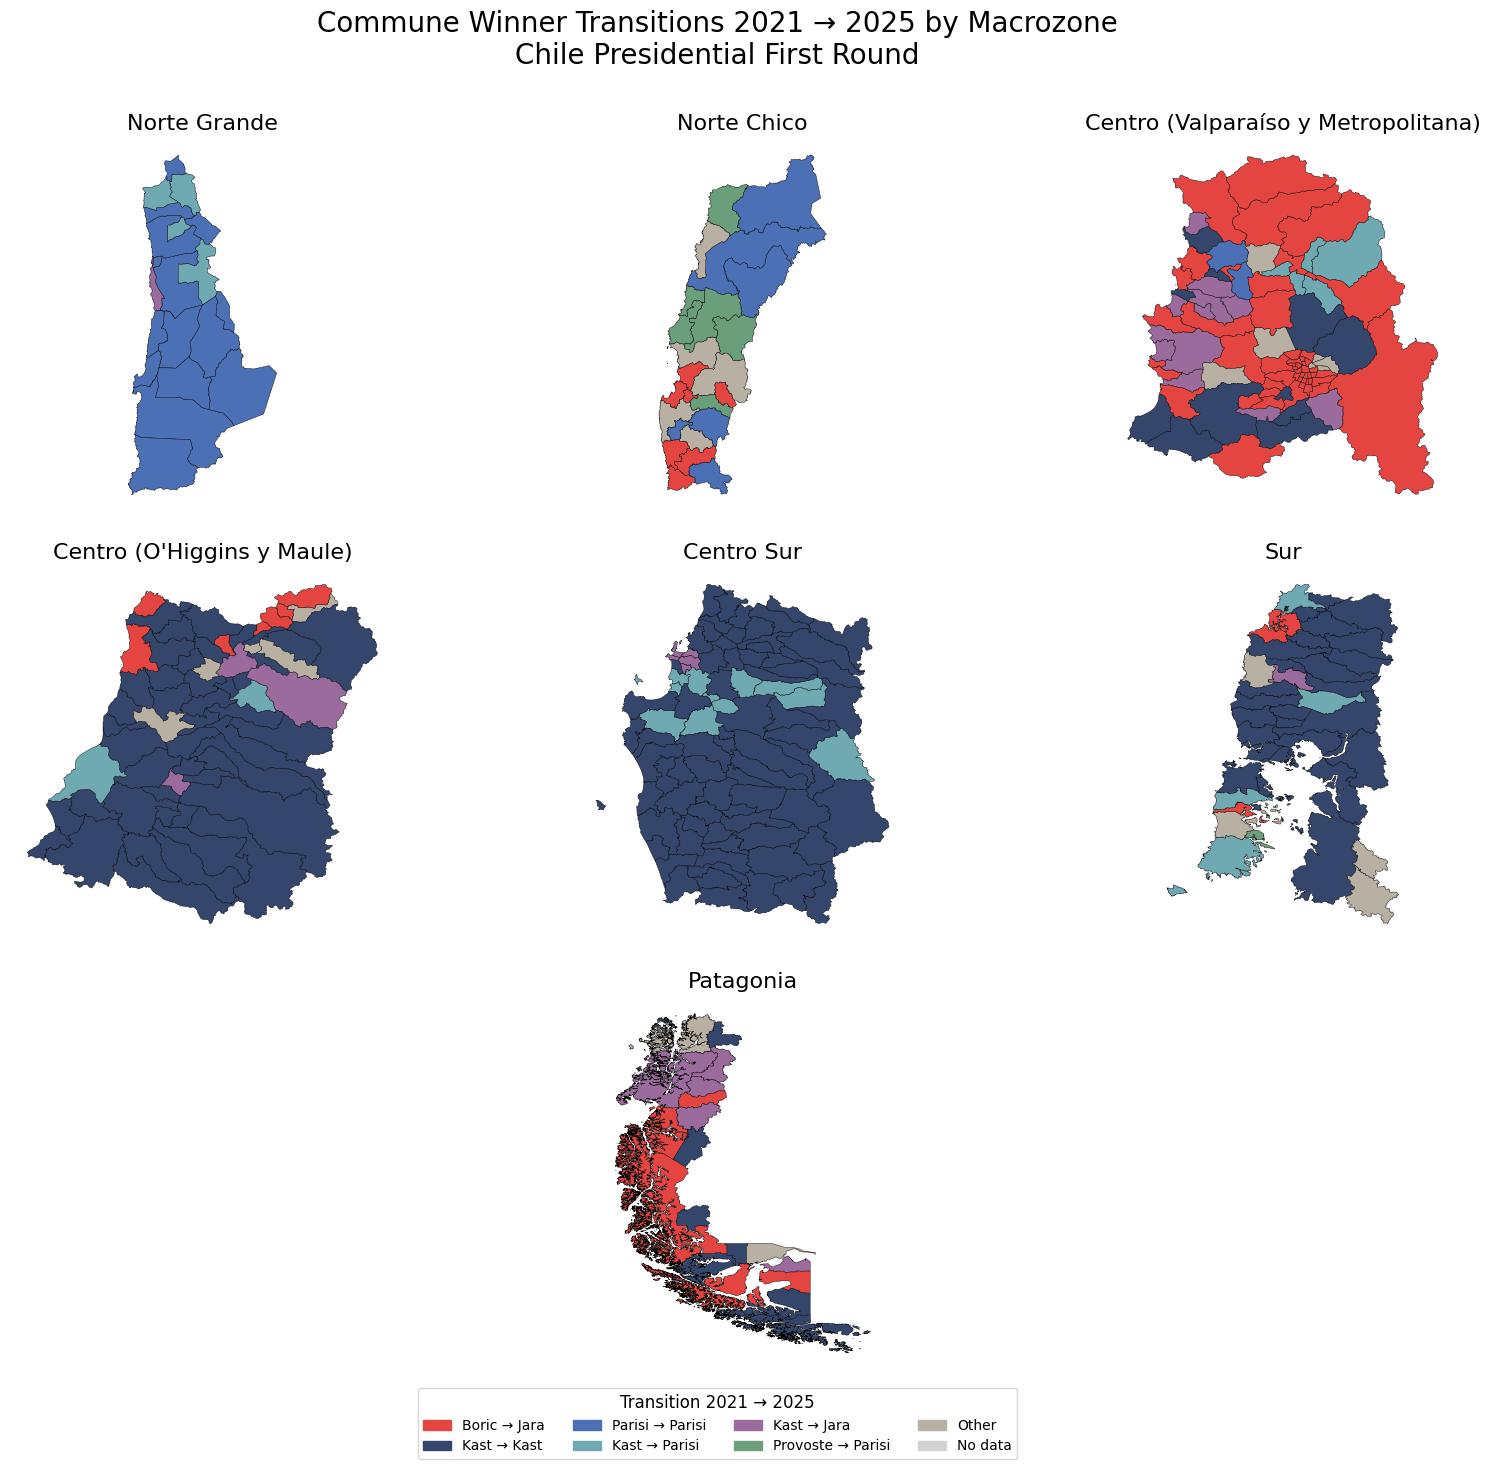

In [52]:
# ============================================================================
# TRANSITION MAP 2021 → 2025 — NATIONAL VIEW
# ============================================================================

# ---------------------------------------------------------------------------
# 1. TRANSITION COLOR PALETTE
# ---------------------------------------------------------------------------
TRANSITION_COLORS = {
    'Boric → Jara':       '#E54540',
    'Kast → Kast':        '#35466D',
    'Parisi → Parisi':    '#4B70B5',
    'Kast → Parisi':      '#6FAAB3',
    'Kast → Jara':        '#9B6B9E',
    'Provoste → Parisi':  '#6B9E7A',
    'Other':              '#B8B0A2',
}

def assign_transition_color(row):
    """Map the 2021→2025 winner transition pair to a display color."""
    w21, w25 = row.get('winner_2021'), row.get('winner_2025')
    if w21 == 'Boric (Left)'          and w25 == 'Jara (Left)':          return TRANSITION_COLORS['Boric → Jara']
    if w21 == 'Kast (Right)'          and w25 == 'Kast (Right)':         return TRANSITION_COLORS['Kast → Kast']
    if w21 == 'Kast (Right)'          and w25 == 'Parisi (Anti-system)': return TRANSITION_COLORS['Kast → Parisi']
    if w21 == 'Kast (Right)'          and w25 == 'Jara (Left)':          return TRANSITION_COLORS['Kast → Jara']
    if w21 == 'Parisi (Anti-system)'  and w25 == 'Parisi (Anti-system)': return TRANSITION_COLORS['Parisi → Parisi']
    if w21 == 'Provoste (Center-Left)' and w25 == 'Parisi (Anti-system)':return TRANSITION_COLORS['Provoste → Parisi']
    return TRANSITION_COLORS['Other']

# ---------------------------------------------------------------------------
# 2. NAME NORMALIZATION FOR SPATIAL JOIN
# ---------------------------------------------------------------------------
communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
df_change['commune_norm']     = df_change['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# 3. SPATIAL JOIN: MERGE GEOMETRIES WITH TRANSITION DATA
# ---------------------------------------------------------------------------
map_data = communes_map.merge(
    df_change[['commune_norm', 'winner_2021', 'winner_2025']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

map_data['color'] = map_data.apply(assign_transition_color, axis=1).fillna(TRANSITION_COLORS['Other'])

# Exclude island communes
map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

unmatched = map_data[map_data['winner_2021'].isna()]['NOM_COM'].tolist()
if unmatched:
    print(f"Communes with no transition data ({len(unmatched)}): {unmatched[:10]}")

# ---------------------------------------------------------------------------
# 4. MACROZONE ASSIGNMENT (7 ZONES)
# ---------------------------------------------------------------------------
MACROZONE_MAP = {
    15: 'Norte Grande',
    1:  'Norte Grande',
    2:  'Norte Grande',
    3:  'Norte Chico',
    4:  'Norte Chico',
    5:  'Centro (Valparaíso y Metropolitana)',
    13: 'Centro (Valparaíso y Metropolitana)',
    6:  "Centro (O'Higgins y Maule)",
    7:  "Centro (O'Higgins y Maule)",
    16: 'Centro Sur',
    8:  'Centro Sur',
    9:  'Centro Sur',
    14: 'Sur',
    10: 'Sur',
    11: 'Patagonia',
    12: 'Patagonia',
}

map_data['macrozone'] = map_data['REGION_NUM'].map(MACROZONE_MAP)

# ---------------------------------------------------------------------------
# 5. GRIDSPEC LAYOUT WITH SHARED LEGEND
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
gs  = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 1])

zone_axes = [
    (ax1, 'Norte Grande'),
    (ax2, 'Norte Chico'),
    (ax3, 'Centro (Valparaíso y Metropolitana)'),
    (ax4, "Centro (O'Higgins y Maule)"),
    (ax5, 'Centro Sur'),
    (ax6, 'Sur'),
    (ax7, 'Patagonia'),
]

for ax, macro in zone_axes:
    macro_data = map_data[map_data['macrozone'] == macro].copy()
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(macro, fontsize=14, fontweight='bold')
        ax.set_axis_off()
        continue

    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
    ax.set_title(macro, fontsize=16)
    ax.set_axis_off()
    ax.set_aspect('equal')

    if macro == 'Patagonia':
        bounds   = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

# Hide unused grid cells
ax_empty1 = fig.add_subplot(gs[2, 0])
ax_empty2 = fig.add_subplot(gs[2, 2])
ax_empty1.set_visible(False)
ax_empty2.set_visible(False)

fig.suptitle(
    'Commune Winner Transitions 2021 → 2025 by Macrozone\nChile Presidential First Round',
    fontsize=20, y=0.96,
)

# ---------------------------------------------------------------------------
# 6. SHARED LEGEND
# ---------------------------------------------------------------------------
legend_handles = [mpatches.Patch(color=color, label=label) for label, color in TRANSITION_COLORS.items()]
legend_handles.append(mpatches.Patch(color='#D3D3D3', label='No data'))

fig.legend(
    handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
    title='Transition 2021 → 2025', title_fontsize=12,
    bbox_to_anchor=(0.5, 0.05),
)

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()


#### 14.5.2. Áreas Metropolitanas y Conurbaciones

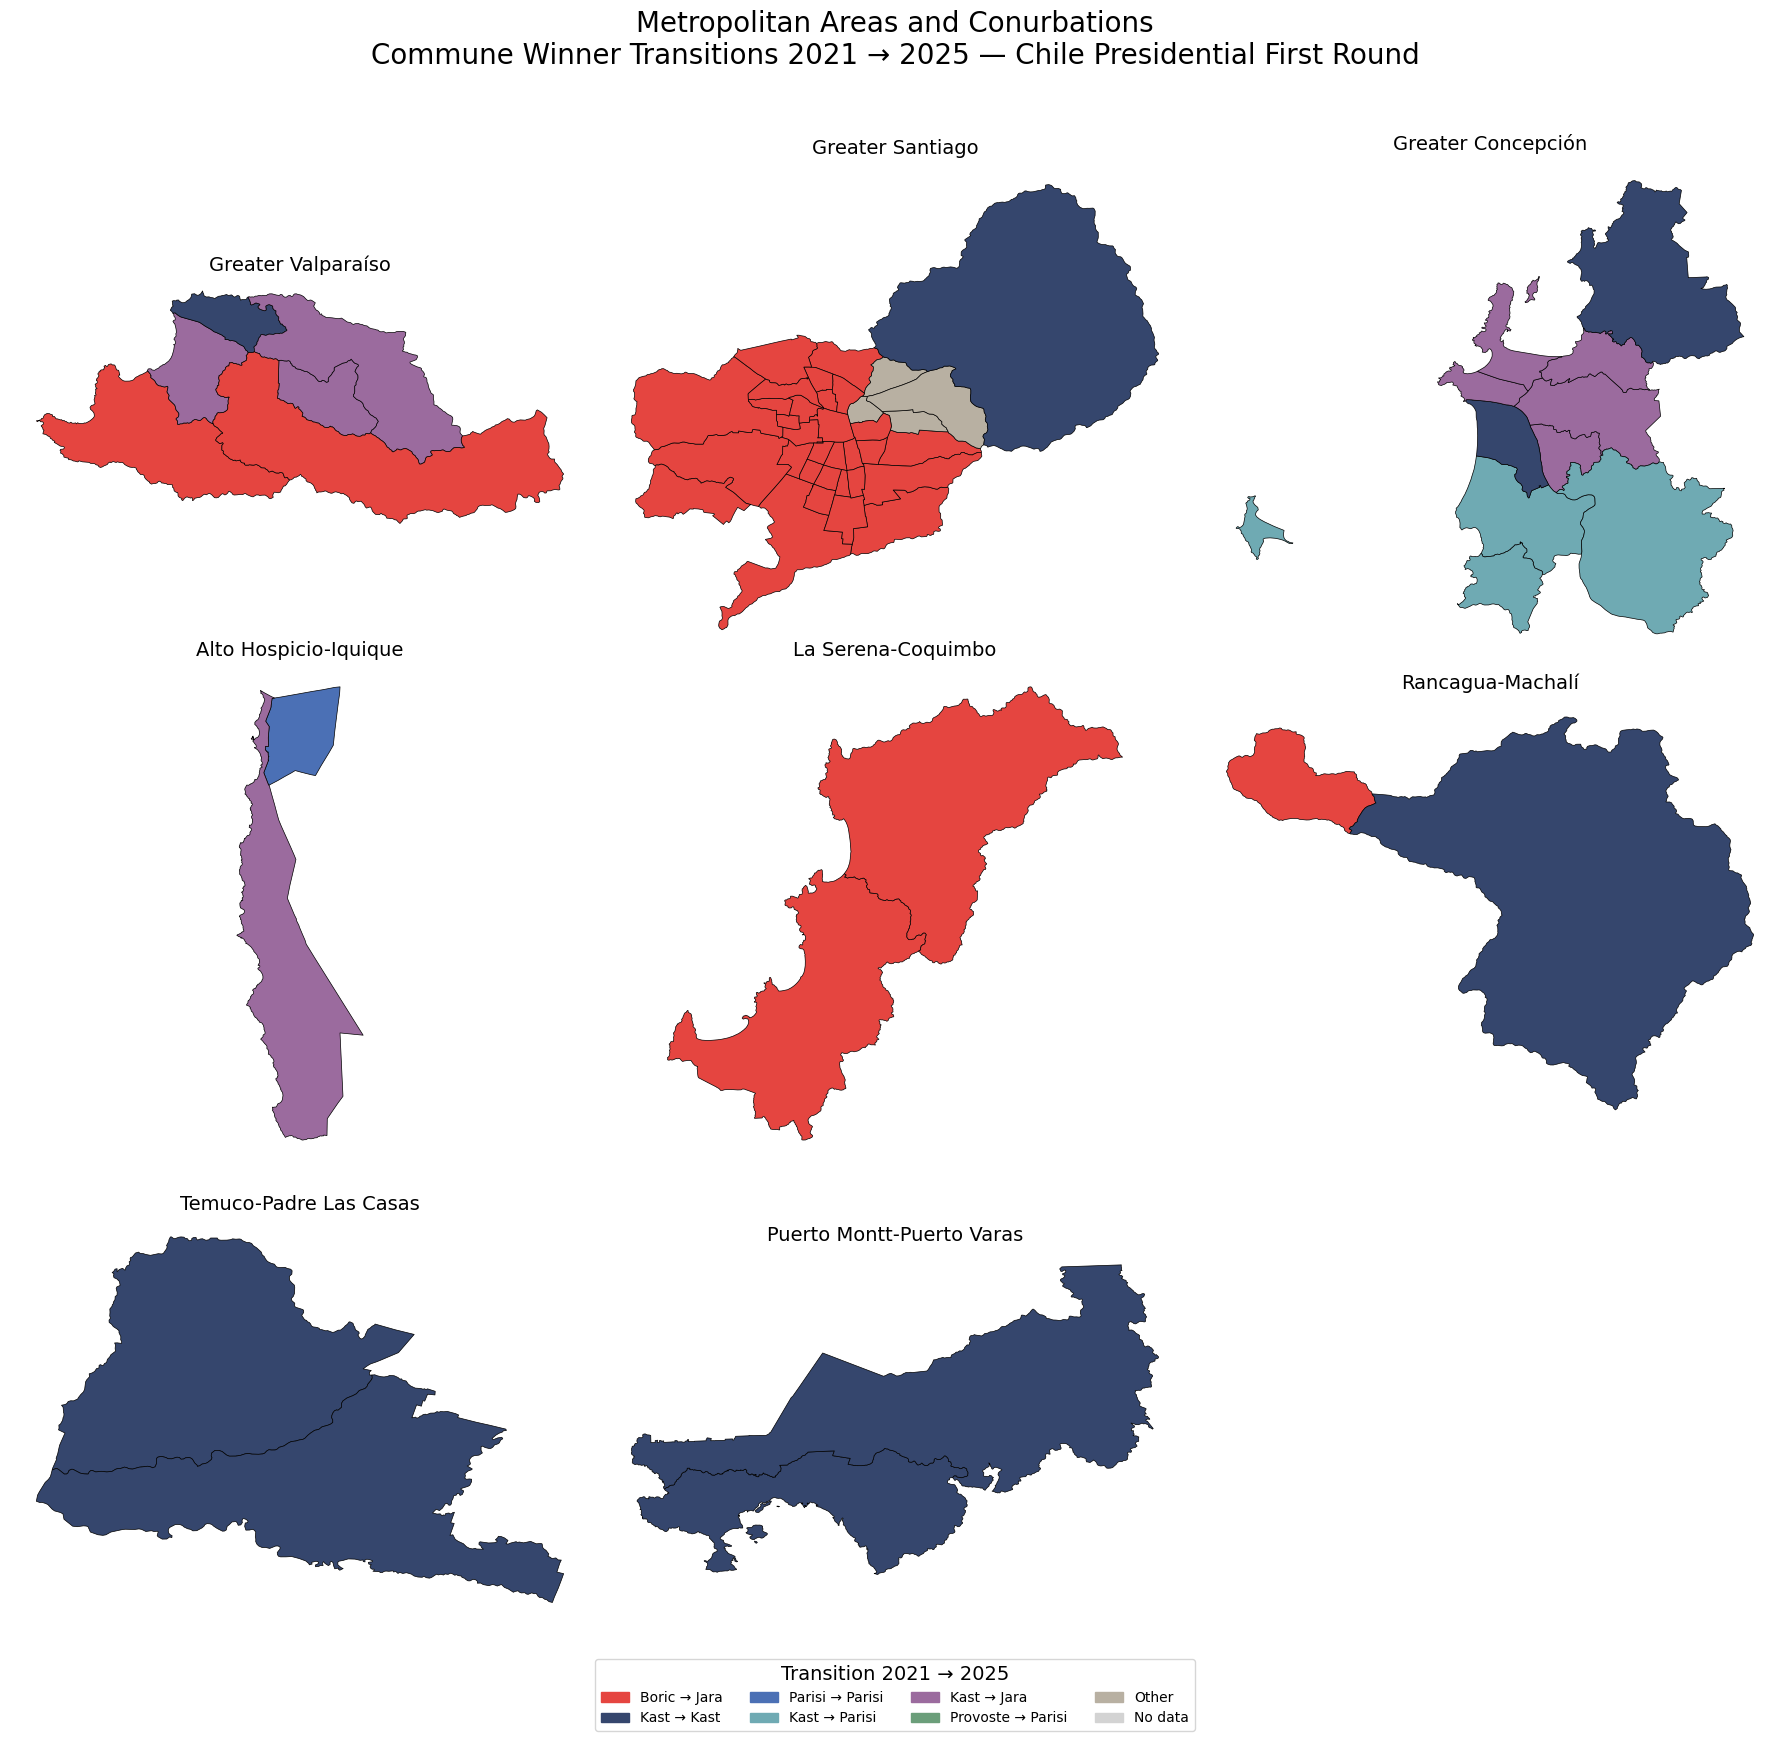

In [53]:
# ============================================================================
# METROPOLITAN AREAS AND CONURBATIONS — WINNER TRANSITION MAP 2021 → 2025
# ============================================================================

# ---------------------------------------------------------------------------
# 1. URBAN AGGLOMERATION DEFINITIONS
# Raw display names are kept for axis titles; GeoJSON matching uses
# normalized keys (computed below) to avoid encoding divergence.
# ---------------------------------------------------------------------------
METRO_AREAS_TRANS = {
    'Greater Valparaíso': [
        "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
    ],
    'Greater Santiago': [
        "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
        "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
        "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
        "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
        "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
        "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
        "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
    ],
    'Greater Concepción': [
        "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
        "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
    ],
    'Alto Hospicio-Iquique':    ["Alto Hospicio", "Iquique"],
    'La Serena-Coquimbo':       ["La Serena", "Coquimbo"],
    'Rancagua-Machalí':         ["Rancagua", "Machalí"],
    'Temuco-Padre Las Casas':   ["Temuco", "Padre Las Casas"],
    'Puerto Montt-Puerto Varas': ["Puerto Montt", "Puerto Varas"],
}

# Grid layout: (row, col) → area name  (cell (2,2) intentionally empty)
GRID_LAYOUT_TRANS = [
    (0, 0, 'Greater Valparaíso'),
    (0, 1, 'Greater Santiago'),
    (0, 2, 'Greater Concepción'),
    (1, 0, 'Alto Hospicio-Iquique'),
    (1, 1, 'La Serena-Coquimbo'),
    (1, 2, 'Rancagua-Machalí'),
    (2, 0, 'Temuco-Padre Las Casas'),
    (2, 1, 'Puerto Montt-Puerto Varas'),
]

# Pre-compute normalized key sets for encoding-safe GeoJSON filtering
area_norm_keys_trans = {
    area: {normalize_commune_name(c) for c in commune_list}
    for area, commune_list in METRO_AREAS_TRANS.items()
}

# ---------------------------------------------------------------------------
# 2. BUILD TRANSITION GEODATAFRAME
# Constructed independently of the national map (cell #140) so this cell
# is re-runnable in isolation and immune to upstream map_data mutations.
# ---------------------------------------------------------------------------
communes_trans = communes.copy()
communes_trans['NOM_COM_NORM'] = communes_trans['NOM_COM'].apply(normalize_commune_name)

df_change_local = df_change.copy()
df_change_local['commune_norm'] = df_change_local['commune'].apply(normalize_commune_name)

map_data_trans = communes_trans.merge(
    df_change_local[['commune_norm', 'winner_2021', 'winner_2025']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)
map_data_trans['color'] = (
    map_data_trans.apply(assign_transition_color, axis=1)
    .fillna(TRANSITION_COLORS['Other'])
)

# ---------------------------------------------------------------------------
# 3. RENDER 3×3 FACET GRID
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle(
    'Metropolitan Areas and Conurbations\n'
    'Commune Winner Transitions 2021 → 2025 — Chile Presidential First Round',
    fontsize=20, y=0.98,
)

for row, col, area_name in GRID_LAYOUT_TRANS:
    ax       = axes[row, col]
    norm_set = area_norm_keys_trans[area_name]

    # Encoding-safe filter: match on normalized key, not raw NOM_COM string
    area_data = map_data_trans[map_data_trans['NOM_COM_NORM'].isin(norm_set)].copy()

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{area_name}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(area_name, fontsize=14)
        ax.set_axis_off()
        continue

    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(area_name, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hide unused bottom-right cell
axes[2, 2].set_visible(False)

# ---------------------------------------------------------------------------
# 4. SHARED LEGEND
# ---------------------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in TRANSITION_COLORS.items()
]
legend_handles.append(mpatches.Patch(color='#D3D3D3', label='No data'))

fig.legend(
    handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
    title='Transition 2021 → 2025', title_fontsize=14,
    bbox_to_anchor=(0.5, 0.02),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


---

## Resumen Ejecutivo

La primera vuelta presidencial de noviembre de 2025 consolidó un **escenario de fragmentación avanzada y realineamiento estructural** del electorado chileno. Ningún candidato superó el 27% de los votos válidos, pero el mapa resultante no es solo un reflejo de la división política: es el diagnóstico de un país que atraviesa una reconfiguración profunda de sus clivajes políticos, desplazando el eje tradicional izquierda-derecha hacia una geometría más compleja de tres polos —el progresismo urbano, el conservadurismo rural y el antisistema periférico— con lógicas territoriales, demográficas y culturales propias.



### 1. Hallazgos Nacionales Clave

- **Participación histórica y legitimidad robusta:** Con aproximadamente el 85,4% del padrón movilizado bajo voto obligatorio, la elección alcanzó niveles de concurrencia no vistos desde los años noventa. El 96,25% de votos válidos confirma la madurez técnica del sistema.
- **Voto de protesta en alza:** El voto nulo (2,69%) casi se triplicó respecto a 2021, con una relación nulo:blanco de 2,5:1 que indica un descontento más confrontacional y menos pasivo. Una fracción del electorado incorporado por la obligatoriedad expresó rechazo activo antes que indiferencia.
- **Fragmentación sin precedente:** Ningún candidato superó el 27%. La derecha sumada alcanzó el 50,34%, pero con tres candidatos de doble dígito que compitieron entre sí en primera vuelta. La izquierda oficialista (Jara) obtuvo el 26,75% —el porcentaje más bajo de ese bloque en primera vuelta desde el retorno a la democracia— y Franco Parisi consolidó el 19,80%, casi triplicando su caudal de 2021 en votos absolutos (+184%).

### 2. La Trifurcación Territorial: Los Tres Chiles

| Chile                | Referente     | Característica principal                          | Regiones controladas |
| -------------------- | ------------- | ------------------------------------------------- | -------------------- |
| **Norteño**          | **Parisi**    | Antisistema, crisis migratoria, minería, abandono | 4 de 4 regiones      |
| **Central Urbano**   | **Jara**      | Izquierda institucional, alta densidad, servicios | 5 de 16              |
| **Centro-Sur Rural** | **Kast**      | Derecha conservadora, ruralidad, anti-centralismo | 7 de 16              |

La paradoja central del resultado: Kast ganó más regiones (7) y más comunas (169), pero Jara lideró la primera vuelta al controlar las zonas de mayor densidad poblacional. Parisi dominó el Norte con una intensidad sin precedente, pero quedó "prisionero" de ese monopolio regional al carecer de penetración efectiva en el Chile urbano y semi-rural del centro y sur.


### 3. Perfiles por Candidato

- **Jeannette Jara:** Candidata del Chile urbano-popular. Dominó las ciudades de más de 200.000 habitantes (76,9% de la población del segmento) y ganó 10 de 16 capitales regionales. Alta lealtad del bloque progresista en la transferencia desde Boric (86% de retención territorial). Estructuralmente vulnerable fuera de las grandes ciudades.

- **José Antonio Kast:** Candidato del Chile rural y periférico. Primer lugar en cobertura territorial (169 comunas), con dominio creciente a medida que disminuye el tamaño de la comuna. Creció un 58% en votos absolutos respecto a 2021, consolidando un bloque de derecha amplio. Su posición estructural para el balotaje era más ventajosa que lo que sugería el resultado de primera vuelta.

- **Franco Parisi:** El gran ganador relativo del ciclo electoral. Tasa de retención territorial del 95,7%, expansión de 23 a 64 comunas ganadas, y crecimiento en 15 de 16 regiones. Su base norteña es estructural, no coyuntural. Fue el árbitro decisivo de la segunda vuelta y la principal señal del realineamiento político del período.

- **Evelyn Matthei:** Representa el colapso electoral de la derecha tradicional. Reducida a enclaves de alto ingreso del oriente de Santiago, con el peor resultado histórico de Chile Vamos en primera vuelta competitiva. Su electorado emigró principalmente hacia Kast entre 2021 y 2025.

- **Johannes Kaiser:** Inauguró en Chile un nicho libertario con potencial de consolidación futura, pero sin la masa crítica territorial para actuar como fuerza autónoma en 2025. Su función fue más de definición del campo político que de competencia real por el liderazgo de la derecha.


### 4. El Gradiente Urbano-Rural: El Hallazgo Estructural más Consistente

La correlación entre tamaño de comuna y preferencia política fue el patrón más regular y consistente del análisis:

| Tamaño de Comuna          | Candidato dominante   | % Población controlada |
| ------------------------- | --------------------- | ---------------------- |
| > 200.000 hab.            | **Jara**              | **76,9%**              |
| 100.000 – 199.999 hab.    | Jara                  | 59,5%                  |
| 50.000 – 99.999 hab.      | Jara                  | 61,5%                  |
| 10.000 – 49.999 hab.      | **Kast**              | **57,9%**              |
| < 10.000 hab.             | **Kast**              | **~60%**               |

El punto de quiebre se produce en torno a las **50.000 personas**: por encima, Jara es la primera fuerza sistemática; por debajo, Kast domina con creciente intensidad. Esta frontera demográfica-funcional explica tanto la victoria de Jara en primera vuelta —por concentración de votos en pocas comunas muy densas— como la ventaja estructural de Kast para el balotaje, dado que las zonas de mayor competitividad relativa se ubicaban en el Chile intermedio (50.000-200.000 habitantes), donde ninguno de los dos dominaba con holgura y donde la transferencia del voto de Parisi era más incierta e impactante.


### 5. Realineamiento 2021 → 2025: Señales de Transformación

- **Parisi casi triplicó sus votos (+184%)** y creció en 15 de 16 regiones, con mayor expansión en el Centro Sur (+10,5 pp en promedio) y el Norte Chico (+7,2 pp). Su crecimiento fue más rápido que el del padrón en todas las macrozonas.
- **Kast perdió 53 comunas** (29,4% de su base territorial de 2021): 25 hacia Parisi y 23 hacia Jara, evidenciando que parte de su voto de 2021 era un voto anti-oficialismo más que un voto ideológico de derecha dura.
- **El colapso territorial de la centroizquierda es completo:** Provoste no retuvo ninguna de sus 11 comunas; el 70% de su electorado migró hacia Parisi. La desintegración del espacio de centroizquierda como actor autónomo es uno de los cambios estructurales más profundos del ciclo.
- **El bloque de izquierda transfirió con eficiencia** (86% de retención de Boric a Jara), pero sin ampliar su base. La primera vuelta de Jara se sostuvo sobre el piso heredado de 2021, sin lograr atraer al electorado descontento que migró hacia el antisistema.

---

### Conclusión Estratégica

La primera vuelta de 2025 no fue solo una competencia entre proyectos: fue un **plebiscito territorial sobre el modelo de Estado y la distribución del poder político en Chile**. Jara ganó el Chile que confía en el Estado como proveedor de bienestar; Kast ganó el Chile que desconfía del Estado y demanda orden y seguridad; Parisi ganó el Chile que rechaza ambas opciones del duopolio porque ninguna ha respondido a sus demandas específicas durante décadas.

El mapa resultante muestra un país en el que las lealtades electorales tradicionales siguen operando —el Sur vota conservador, las grandes ciudades votan progresista—, pero donde el margen de volatilidad ha crecido significativamente. El voto obligatorio amplificó esa volatilidad al incorporar un electorado más heterogéneo y menos vinculado a las identidades partidarias clásicas.

Para el ciclo político que se abre, los desafíos son conocidos pero no menos urgentes: **seguridad pública, migración, crecimiento económico y la persistente percepción de abandono estatal en territorios periféricos**. La elección de 2025 no resolvió esos desafíos; los dejó como herencia abierta para quien gane la segunda vuelta. El realineamiento territorial observado —más fragmentado, más fluido, con un antisistema estructural en el Norte y un gradiente urbano-rural muy marcado— sugiere que la política chilena ha entrado en una fase de mayor incertidumbre y menor predictibilidad, en la que construir mayorías requerirá coaliciones más amplias y compromisos más concretos con demandas ciudadanas que trascienden las fronteras ideológicas tradicionales.